# The Mathematics of Eigen Times — OCaml teaching notebook

Alexy Khrabrov · Notebook edition 1.0.1 · Companion text 1.1.2

This notebook includes **the complete companion text**, its figures as embedded
attachments, and executable lessons after the corresponding explanations. Read
from top to bottom. Use **Restart Kernel and Run All** for a clean run; then edit
the small input arrays and rerun a lesson to explore what changes. Later cells
depend on earlier ones. Outputs saved here show a verified run, but rerunning is
the way to check your own edits.

Examples use synthetic or explicitly frozen numerical inputs. Dated catalog
counts, archive-wide measurements, model labels, and live-site journeys in the
original text are historical evidence, not claims that this notebook recreates
or refreshes the production archive. No credentials, remote API calls, paid news
access, or live network connection are needed to execute the lessons.

The companion's original diagrams remain embedded reference figures. Lesson
outputs recompute the arithmetic from editable inputs. Exercise suggestions
accompany the examples; assertions check mathematical identities and reference
results. When deliberately changing a fixture, examine and update its expected
results as part of the exercise.

The setup cell defines reusable numerical helpers. Their operations are
introduced in the relevant chapters; you may run it now and return to its code
later. The OCaml edition computes in OCaml and does not call Python. The Python
edition uses NumPy and, where needed, SciPy/Matplotlib.

For environment installation and verification commands, see the included
`README.txt`. Python needs the `math-companion-python` kernel from the teaching environment;
OCaml needs the `ocaml-jupyter` kernel (an installed differently named OCaml
kernel can be selected in Jupyter). Both notebooks retain the same full text.

Original reader: [The Mathematics of Eigen Times](https://firstpair.org/read/eigentimes-math/).
Manuscript revision: `c0d75f51`. Notebook source revision:
`c0d75f51`. The manuscript and lesson SHA-256 hashes are in notebook metadata.

HTML reading copies use MathJax from a CDN for mathematical rendering; notebook computations run offline.


In [1]:
#print_length 100000;;
(* Small dense educational linear algebra. Arrays store rows; no Python bridge.
   Jacobi diagonalizes symmetric matrices; Gram SVD is for tiny teaching inputs,
   not a numerically preferred replacement for a production direct SVD. *)
type vector = float array;;
type matrix = float array array;;
let rows a = Array.length a;;
let cols a = if rows a = 0 then 0 else Array.length a.(0);;
let zeros n p = Array.make_matrix n p 0.;;
let eye n = Array.init n (fun i -> Array.init n (fun j -> if i=j then 1. else 0.));;
let dot x y = if Array.length x <> Array.length y then invalid_arg "dot shape"; Array.fold_left (+.) 0. (Array.mapi (fun i x -> x *. y.(i)) x);;
let norm x = sqrt (dot x x);;
let normalize x = let n=norm x in if n=0. then invalid_arg "zero direction" else Array.map (fun a -> a /. n) x;;
let transpose a = Array.init (cols a) (fun j -> Array.init (rows a) (fun i -> a.(i).(j)));;
let matvec a x = Array.map (fun row -> dot row x) a;;
let matmul a b = if cols a <> rows b then invalid_arg "matmul shape"; let bt=transpose b in Array.map (fun row -> Array.map (dot row) bt) a;;
let map2 f a b = Array.mapi (fun i row -> Array.mapi (fun j x -> f x b.(i).(j)) row) a;;
let add a b = map2 (+.) a b;;
let sub a b = map2 (-.) a b;;
let scale s a = Array.map (Array.map (( *.) s)) a;;
let outer a b = Array.map (fun x -> Array.map (fun y -> x*.y) b) a;;
let frob a = sqrt (Array.fold_left (fun s row -> s +. dot row row) 0. a);;
let col a j = Array.map (fun row -> row.(j)) a;;
let take_cols a k = Array.map (fun row -> Array.sub row 0 k) a;;
let mean_rows a = Array.map (fun column -> Array.fold_left (+.) 0. column /. float_of_int (rows a)) (transpose a);;
let center a mu = Array.map (fun row -> Array.mapi (fun j x -> x -. mu.(j)) row) a;;
let diag values = Array.mapi (fun i x -> Array.init (Array.length values) (fun j -> if i=j then x else 0.)) values;;
let close ?(tol=1e-9) x y = abs_float (x-.y) <= tol *. (1. +. max (abs_float x) (abs_float y));;
let assert_close ?(tol=1e-9) x y = if not (close ~tol x y) then failwith (Printf.sprintf "Expected %.12g; got %.12g" y x);;
let assert_matrix ?(tol=1e-9) a b = assert (rows a=rows b && cols a=cols b); if frob (sub a b) > tol *. (1. +. frob b) then failwith "matrix mismatch";;
let cosine a b = dot a b /. (norm a *. norm b);;
let print_vector label v = Printf.sprintf "%s: [%s]" label (String.concat "; " (Array.to_list (Array.map (Printf.sprintf "%.6g") v)));;
let print_matrix label a = Printf.sprintf "%s (%d x %d)\n%s" label (rows a) (cols a) (String.concat "\n" (Array.to_list(Array.map(print_vector " ")a)));;
let eig_sym input =
  let n=rows input in assert(n=cols input);
  let a=Array.map Array.copy input and v=eye n in
  let iteration=ref 0 and running=ref true in
  while !running && !iteration < 100*n*n do
    incr iteration;
    let p=ref 0 and q=ref 0 and largest=ref 0. in
    for i=0 to n-1 do for j=i+1 to n-1 do
      if abs_float a.(i).(j) > !largest then (largest:=abs_float a.(i).(j);p:=i;q:=j)
    done done;
    if !largest = 0. || !largest < 1e-13 *. frob a then running:=false else (
      let p= !p and q= !q in
      let apq=a.(p).(q) and app=a.(p).(p) and aqq=a.(q).(q) in
      let tau=(aqq-.app)/.(2.*.apq) in
      let t=(if tau>=0. then 1. else -1.)/.(abs_float tau +. sqrt(1.+.tau*.tau)) in
      let c=1./.sqrt(1.+.t*.t) in let s=t*.c in
      for i=0 to n-1 do if i<>p && i<>q then (
        let aip=a.(i).(p) and aiq=a.(i).(q) in
        a.(i).(p)<-c*.aip-.s*.aiq; a.(p).(i)<-a.(i).(p);
        a.(i).(q)<-s*.aip+.c*.aiq; a.(q).(i)<-a.(i).(q))
      done;
      a.(p).(p)<-app-.t*.apq; a.(q).(q)<-aqq+.t*.apq;
      a.(p).(q)<-0.;a.(q).(p)<-0.;
      for i=0 to n-1 do let vip=v.(i).(p) and viq=v.(i).(q) in
        v.(i).(p)<-c*.vip-.s*.viq;v.(i).(q)<-s*.vip+.c*.viq done)
  done;
  if !running then failwith "Jacobi iteration limit";
  let order=Array.init n Fun.id in Array.sort (fun i j -> compare a.(j).(j) a.(i).(i)) order;
  let values=Array.map (fun j -> a.(j).(j)) order in
  let vectors=Array.init n (fun i -> Array.map (fun j -> v.(i).(j)) order) in
  for j=0 to n-1 do
    let pivot=ref 0 in for i=1 to n-1 do if abs_float vectors.(i).(j)>abs_float vectors.(!pivot).(j) then pivot:=i done;
    if vectors.(!pivot).(j)<0. then for i=0 to n-1 do vectors.(i).(j)<- -.vectors.(i).(j) done
  done;
  values,vectors;;
let thin_svd x =
  let values,vfull=eig_sym (matmul (transpose x) x) in
  let r=min (rows x) (cols x) in
  (* Gram diagonalization cannot resolve squared scales below roundoff.
     This tolerance is relative to input scale, not an absolute singular cutoff. *)
  let cutoff=64.*.epsilon_float*.(if Array.length values=0 then 0. else max 0. values.(0)) in
  let s=Array.init r (fun i -> if values.(i)>cutoff then sqrt values.(i) else 0.) in
  let v=take_cols vfull r in let xv=matmul x v in
  let u=zeros (rows x) r in
  let orthogonalize candidate j =
    let a=Array.copy candidate in
    for _=1 to 2 do for k=0 to j-1 do
      let q=col u k in let projection=dot a q in
      Array.iteri(fun i qi->a.(i)<-a.(i)-.projection*.qi)q
    done done; a in
  for j=0 to r-1 do
    let candidate=if s.(j)>0. then Array.map(fun z->z/.s.(j))(col xv j) else (
      let chosen=ref None and i=ref 0 in
      while !chosen=None && !i<rows x do
        let e=Array.init(rows x)(fun k->if k= !i then 1. else 0.) in
        let a=orthogonalize e j in if norm a>1e-10 then chosen:=Some a;incr i
      done;
      match !chosen with Some a->a | None->failwith "orthonormal completion failed") in
    let q=normalize(orthogonalize candidate j) in
    Array.iteri(fun i value->u.(i).(j)<-value)q
  done; u,s,v;;
let reconstruct_svd u s v k = matmul (matmul (take_cols u k) (diag (Array.sub s 0 k))) (transpose (take_cols v k));;
let solve a b =
  let n=rows a in assert(n=cols a && Array.length b=n);
  let m=Array.init n (fun i -> Array.append a.(i) [|b.(i)|]) in
  for j=0 to n-1 do
    let pivot=ref j in for i=j+1 to n-1 do if abs_float m.(i).(j)>abs_float m.(!pivot).(j) then pivot:=i done;
    if abs_float m.(!pivot).(j)<1e-13 then invalid_arg "singular solve";
    let tmp=m.(j) in m.(j)<-m.(!pivot);m.(!pivot)<-tmp;
    let d=m.(j).(j) in for k=j to n do m.(j).(k)<-m.(j).(k)/.d done;
    for i=0 to n-1 do if i<>j then (let c=m.(i).(j) in for k=j to n do m.(i).(k)<-m.(i).(k)-.c*.m.(j).(k) done) done
  done; Array.init n (fun i -> m.(i).(n));;
let inverse a = transpose (Array.map (solve a) (eye (rows a)));;
let qr x =
  let basis=ref [] in
  Array.iter (fun input -> let v=Array.copy input in
    List.iter (fun q -> let projection=dot v q in Array.iteri(fun i qi -> v.(i)<-v.(i)-.projection*.qi) q) !basis;
    (* Reorthogonalize to reduce cancellation in the teaching power iteration. *)
    List.iter (fun q -> let projection=dot v q in Array.iteri(fun i qi -> v.(i)<-v.(i)-.projection*.qi) q) !basis;
    if norm v > 1e-10 then basis:= !basis @ [normalize v]) (transpose x);
  if !basis=[] then zeros (rows x) 0 else transpose (Array.of_list !basis);;
let procrustes a b = let u,_,v=thin_svd (matmul (transpose a) b) in matmul u (transpose v);;
let covariance x weights =
  let z=Array.fold_left (+.) 0. weights in assert(z>0. && rows x=Array.length weights && Array.for_all(fun w->w>=0.)weights);
  let mu=Array.init (cols x) (fun j -> dot (col x j) weights /. z) in
  let xc=center x mu in
  let weighted=Array.mapi (fun i row -> Array.map (fun value -> value*.weights.(i)) row) xc in
  mu,scale (1./.z) (matmul (transpose xc) weighted);;
let results : (string,float) Hashtbl.t = Hashtbl.create 60;;
let record_result key value = Hashtbl.replace results key value;Printf.sprintf "%s = %.12g" key value;;
let result_json () =
  let items=Hashtbl.fold (fun key value acc -> (key,value)::acc) results [] |> List.sort compare in
  "{" ^ String.concat "," (List.map (fun (key,value)->Printf.sprintf "%S:%.15g" key value) items) ^ "}";;

let covariance_rows = [|[|1.603514377052519;0.040872183525761295;0.22334908743269138|];[|-1.0051743504605932;-0.7842693549624872;0.03324028448802799|];[|-2.4573908734799144;-1.8136124246981904;-0.16164448946752474|];[|2.8855947723122193;2.7354074864587834;-0.00786980488752087|];[|-0.7186921624840137;-0.6843218369803262;-0.21862573194657864|];[|-0.8282057215673181;-0.08193764347752813;0.026353351442947745|];[|0.5203539586271007;0.5878615901339874;0.10519730293795714|]|];;
let cloud_points = [|[|-0.10221718120007706;0.1824580260179311|];[|-0.21059561957681602;-0.8414442506352652|];[|-0.5191878964493616;-1.101291639430476|];[|-0.35448638295019214;0.8786202772897801|];[|-0.7206131528052667;-0.9175700883647336|];[|0.8083639976088928;0.7551775059467838|];[|0.5265049342645562;-0.4481106009911696|];[|-0.2990883250528124;0.38932815610374333|];[|-2.4009071650239786;-1.7560508139766748|];[|-3.1709776110996613;-2.8730857230357176|];[|-3.426694629612436;-2.168424965771469|];[|-2.5097523974959834;-1.2297458514714497|];[|0.3640767614127511;0.0591053325245737|];[|-4.606528744995511;-3.095000894751539|];[|-0.1320648569159165;0.015338882307964636|];[|-2.7480865305551276;-1.9727718737065691|];[|-1.581236201507552;-1.566702503670915|];[|2.3039204854891886;0.6774466054327175|];[|-0.3714986234299571;0.5003589889622929|];[|-1.0728124785591848;-0.7096761842121236|];[|0.18813883838566206;0.16017620333675822|];[|-2.36069390744205;-1.3014038474299205|];[|3.1304069628129985;0.5567991477032763|];[|1.5955700176845709;1.0176754896317841|];[|-1.9223110367792808;0.5070706495803449|];[|1.8720509206197278;0.11145542430327242|];[|-0.05986887064190433;0.43156733233798616|];[|-0.59869684945349;0.20633201004156276|];[|-0.36026916218233884;0.33132828464265435|];[|2.977235426094502;1.1727763791974157|];[|0.5491886853795614;-0.05741282030507955|];[|0.657996974633428;-0.5797031818980515|];[|-1.035049187371661;-0.756169243751167|];[|1.3115474569248207;1.6828942053102516|];[|-2.243534291897961;-1.9376069048403897|];[|1.9298634794971758;-0.4962465388377105|];[|-0.8484066885110154;-0.5684639158080734|];[|2.153643821989627;1.8006453789691506|];[|-0.4944237326825699;-0.583372023503607|];[|-1.0099215502284555;0.6483756743755394|];[|-0.7092089062595975;-0.6549238884986399|];[|0.7140420523848006;0.3146347825839353|];[|0.014046563097374133;-0.8923799640055535|];[|0.1333020832184457;-0.2815804402587346|];[|1.9931908361812447;1.6786544177903697|];[|-0.27993311899620227;0.37862648757894496|];[|-1.0157826901135476;0.26396120118779914|];[|-0.21447136872713363;0.34771724044907726|];[|-2.5808199739599806;-1.20981895933607|];[|-2.5040957045794285;-3.090877129066228|];[|-0.26513170145925147;-0.880476684305717|];[|-0.47310226424310126;1.5412694599787073|];[|-1.3662652335870404;-1.293141197025446|];[|0.21879242573079083;0.5248177650077055|];[|-0.2640230802147031;-0.3188853006826372|];[|1.1564040086122704;1.0878865055376254|];[|-1.941703504162886;-1.1850445386795856|];[|0.4363000939099223;-0.6004317958885719|];[|0.7953447435888924;-0.23428546246160406|];[|1.784574749692612;1.1861193784628725|];[|0.37701163137686006;-0.2600547632053291|];[|0.47322913716121057;-1.3415401342470519|];[|-2.282614675025881;-1.0245882790543104|];[|-4.351777872646204;-1.8281946053402092|];[|-3.591619067223498;-1.461957785780962|];[|-1.8835350799751567;-0.4578084883137461|];[|0.7873877884363304;-0.7876103414578994|];[|1.8753505060580988;2.2480521395645687|];[|-0.02950448937730597;-0.23843831174804114|];[|0.0367158347082315;-0.7670083414277579|];[|2.283101068969156;0.879334692661045|];[|0.1801229059144224;-0.5372198404941053|];[|-0.7456256566863603;-1.4632601179611835|];[|2.4489693626100797;1.2893656181231006|];[|1.8356642428245769;1.070591388197139|];[|-1.2086765690293344;-0.9618862944158959|];[|-1.0701691925082983;-0.6114292080934267|];[|-0.6100067554082913;-0.5946114012512036|];[|-2.3441414597793897;-2.0055565017314425|];[|3.386334510169802;1.4125497916839285|];[|-2.126382612118529;-0.9550099450230515|];[|3.1901221505506565;0.6665440309441125|];[|-0.17606908534808743;-0.6125355308405226|];[|-3.612417071159065;-1.491595781663916|];[|-0.06967130937445931;0.017521006025096868|];[|-1.5925203197809064;-0.5518443728142273|];[|-0.9774833276953301;-0.6798575506244023|];[|-1.6858844340315369;-1.9563099901665353|];[|2.7220165779454684;1.1616691512737796|];[|0.5675523686244296;0.30036402955195635|];[|-0.6627081555512883;-0.7931946961485207|];[|1.3061222290701289;0.5100933407160003|];[|-0.2963164474459575;-0.15311690985897353|];[|2.003370563702783;1.7066970063876854|];[|0.9262014006374072;0.0792132940577222|];[|-2.9653395173816945;-0.9445436622315789|];[|1.8905770329230547;0.9777919139263067|];[|0.7589223111437973;1.0697969011568267|];[|1.2611348570885201;1.4728619440524882|];[|-1.3983087556799259;0.41722414659706314|];[|-2.676681841592647;-0.8488605111216234|];[|0.6353003122727642;1.0729287288145366|];[|3.0604357256265593;2.9668063811415193|];[|-1.5908199925034003;-2.2833973389208015|];[|1.9116370354277128;0.28325938884556084|];[|-0.31754005671946217;0.49541180162735315|];[|-2.3933614235523164;-3.0872847587485923|];[|0.4784959239699502;0.31213643795323065|];[|-0.4818049164385426;-0.24702291947242594|];[|-1.1097793853874947;-1.8640743917323288|];[|0.022577905909501834;-0.7723874240371823|];[|-3.3082408418648237;-1.5012765968245605|];[|-0.25926508615796096;0.17890633679673731|];[|-1.654539435299829;-1.4871513772084994|];[|-1.5931079568317013;-1.6364453965939763|];[|0.6463432016347562;-0.2597044262607638|];[|0.5594828195127551;0.5976390014512284|];[|4.345926061114317;1.3833435984847697|];[|1.7230020202896152;0.9224434217887651|];[|0.4807221117236105;-0.8943659344034823|];[|-1.1369060136701161;-0.05567379688124163|];[|-0.1855114335894367;-0.04158960851429886|];[|-0.9579890789939025;0.38013236327117184|];[|0.7292347505716333;-1.3575509336262637|];[|-0.6294964894620685;-1.9547993191532096|];[|-6.009281814233066;-3.897947608933419|];[|2.524280789697332;1.4954807601261182|];[|-1.9047546594935891;-1.8600692663854568|];[|2.098938196163381;1.3392306153980926|];[|0.11016246371459984;0.020389678632400845|];[|-0.20872965198875598;0.5304915131342202|];[|0.9772854519753437;0.7385880520475229|];[|-2.1658191467653922;-0.8373119711929132|];[|-1.686511760980066;-0.08956308558704147|];[|-2.3735097207547406;-1.4815841869803328|];[|0.449606524441017;-0.811117803427892|];[|2.769654245446711;2.7794933604559633|];[|-1.1533480994854965;-0.04211104395808172|];[|1.6362206236780692;-1.1678425460535196|];[|0.49854272287960716;0.23824994585018786|];[|0.535456574657748;-0.5612816372660836|];[|-0.45078447863077453;-0.40434538311783336|];[|2.146574032092706;1.50963926994165|];[|-0.5457232532722815;0.9207782686476498|];[|-0.9215887809564952;-0.8468522986579334|];[|-4.0105702291983505;-1.0472106455971637|];[|1.5164031072264672;1.6165751935839283|];[|1.2358706981027061;0.8025623236670211|];[|0.49876387683976264;0.08426695673575244|];[|-0.40691717407406897;-0.19104065321232702|];[|2.685931313418725;1.9998803503991829|];[|0.09140571882085309;-0.4155439024390628|];[|-1.77078136112939;0.27308994196077374|];[|0.941726274509869;0.5983063843256085|];[|-0.271396299097751;-1.053127926448516|];[|-0.4331686881367212;0.4560793232332167|];[|-0.6683489968741163;-0.5695494663112942|];[|-0.4594850284007392;-0.17669973182419613|];[|-2.9527039337092917;-1.8950146335877014|];[|-1.9374468533190996;-0.40358389296478775|];[|-1.6701540276164846;-0.49784254458783855|];[|3.0142021246405593;1.486773567838239|];[|-1.2131579873293115;-0.5456842376808834|];[|0.3438999047692216;-0.6045798292581163|];[|0.1727388121151948;1.7288530301162583|];[|-0.4207627302049011;-0.4069103525229023|];[|-2.1025438488954498;-0.9559881322756387|];[|-1.988382936203422;-2.042715118306252|];[|2.7550021755662737;0.8587322530690971|];[|1.5267375750301866;2.1135862552811044|];[|0.3003962691084372;0.6207348123977221|];[|3.7883925466717674;2.028215782371075|];[|-0.6561969137602967;-1.4726591121403823|];[|-0.438237813406655;0.9425613121421399|];[|2.1580066853204922;0.484442456115413|];[|-1.453249056506628;-1.246550486942409|];[|0.6287044846302197;0.1970314526535569|];[|0.30473086001421645;0.41578802777077556|];[|-0.5551792557342903;-0.3530051031451035|];[|0.42300073941067845;0.17634768745205273|];[|0.3045295722599965;1.6880311144122924|];[|1.1083249900422885;0.6850028589401409|];[|-3.348272415681342;-1.6195440012509617|];[|-3.2157585765414782;-2.995527772330503|];[|1.381124197112613;1.368235429900749|];[|0.31283172765939543;-1.201572039260716|];[|-0.4699555370517239;-0.8199466068478374|];[|0.4231388951407209;2.069201217930637|];[|0.6860669843442304;-0.2338087272792828|];[|-2.2105671974300503;-1.3216120338401807|];[|0.06619543287693531;-0.8925439044316539|];[|0.6245062303988677;-0.5697134836485438|];[|1.746921215886298;1.8675156928738565|];[|2.2326464002878152;0.9058485666699951|];[|1.0265176597532533;0.4859097370402545|];[|-0.622085489439434;-0.6332893958104674|];[|-1.9709378835319529;-2.3049826485106504|];[|1.580305323872667;0.7578159674355525|];[|0.06174608603198932;0.8453219867856177|];[|-3.027615365542538;-2.3817993391748336|];[|0.19682456760755174;0.430563159972256|];[|-1.0786360484081383;0.20912485695339272|];[|0.8255399446688558;-0.5041393969936556|];[|-2.0552580360196178;-0.5355492733086347|];[|1.5483890472559338;-0.6410300913237819|];[|2.358427341820077;1.8450181550026146|];[|2.693707445726159;1.2450709891403018|];[|-0.16913603974501445;-1.0081551596328804|];[|4.8949089806540345;2.6842590556623382|];[|3.2512093201122725;1.3538863166846384|];[|0.8971327667424822;-0.8329782868671745|];[|-1.0737741075743932;0.17521585559699426|];[|-2.7601719160257843;-0.7269147923463899|];[|1.0079071581558932;-0.2619000175051309|];[|-0.7949981681050069;-0.8300507751909083|];[|0.09330337787913652;-0.3794912779514722|];[|-1.469589448468319;-1.0946631725257085|];[|-1.5051534207211195;-1.9113126520047423|];[|-0.40079450592006705;0.4822199246156435|];[|-2.9150722996260616;-1.6801821718274221|];[|-0.8963319643018355;-1.3073147545069093|];[|1.8073765043351802;0.6246577380295598|];[|3.127591881599004;1.175379361216051|];[|0.8159342515002858;0.2873691927194855|];[|-1.6422907566662632;-0.47316492880929456|];[|-0.5064051631884311;0.1951961503284192|];[|0.2899332667625212;-0.7102617805918904|];[|-0.21265233593326865;-0.08078001984656445|];[|2.1433113391915697;0.5049128611589775|];[|0.5277241210559915;-1.0870963444247501|];[|1.6197800305467014;0.06102815551823443|];[|-3.4208512219816907;-2.0228937711614967|];[|2.6401692099997747;0.2921066058179296|];[|-1.8128399939006232;-1.6474256002803465|];[|-2.284779897204411;-1.0124303778347787|];[|-1.2857114209524645;-1.325499253234493|];[|1.3757761663707206;0.183629534205748|];[|1.1645416398056367;-0.11281285743775954|];[|-1.6670267904583018;-2.446034363895019|];[|3.6581582303777447;1.8531763452710994|];[|0.4756228137861599;0.2495039402565884|];[|0.2873778116639922;0.20607876006196166|];[|3.999266056979501;1.4692229688177305|];[|-2.6131779645182753;-2.3266762630669056|];[|-2.8043989184126015;-1.0153582315557714|];[|1.8994908551785739;0.3196494522843841|];[|-2.5249571218455396;-1.7445633944678096|];[|3.637296255943982;-0.17903685481889614|];[|1.379873082224473;-0.07285250273960506|];[|2.3594390112753003;0.49094719989270974|];[|-0.01659250020050235;-1.2270905863778319|];[|-2.346969981140222;-0.23486329101779482|];[|1.7039962263793893;0.6591381779215179|];[|-0.9950685344109115;-2.105249170285928|];[|-0.7392006299231053;-0.45175648435059357|];[|-0.12731788541193206;-0.14931812822603108|];[|-2.114138537976666;-1.2741669977835044|];[|-0.5253793973118298;0.7398209394395389|];[|3.6045510652607615;1.9703616156422357|];[|-1.4372651803202472;-0.8823298689095894|];[|-0.8978221770393395;-1.1184599843252874|];[|0.2534130036024478;-0.696984865995501|];[|1.1911588988065236;0.6037219724613837|];[|0.5403588113650145;0.16410763458205943|];[|-1.0538199720266601;-1.3746498343296263|];[|-0.26000538629800724;-0.593671879718259|];[|0.44719298850396455;0.25460488924470126|];[|-2.6190354079856273;-1.45784729740702|];[|-2.342725548025273;-1.8508661580499177|];[|0.16552670005671358;-1.5818565350659712|];[|0.12150093146087515;0.19218698412673835|];[|-0.1525654796552297;-0.43105528882458694|];[|-0.37002175930722175;-1.0029596174496862|];[|-0.32043408627925324;-0.6316735088941966|];[|0.5961317656318266;-0.6291147782555113|];[|0.39873244865642893;0.34597073994975003|];[|-0.11599173149638432;-0.42197288937675953|];[|1.6349594298637544;-0.401537273969372|];[|0.7922183206336147;0.6538323058142169|];[|0.40574494261206456;0.5440848316340944|];[|-1.1545488341267263;-0.8762981484816394|];[|1.0630354013278467;0.961825332007735|];[|0.9238527993435789;-0.6906238192301594|];[|0.6154977456882025;1.3006299380100415|];[|1.8418252403253845;1.25241967448225|];[|-3.2976670166157542;-1.142059036635889|];[|0.6058241131298298;-1.697238545958197|];[|1.2409367499679087;-0.48965292625211665|];[|-2.2478154369502668;-1.811008010022779|];[|2.5544077090552237;1.175037247355424|];[|-0.09548046909115497;1.357740009637939|];[|3.073208287006047;1.6907780603492946|];[|-0.018854627503903702;-1.030035324271703|];[|-1.4719957566943171;-0.5060440872786486|];[|0.7153849832185847;0.5021322140560489|];[|2.1656805203515135;0.6260585990702463|];[|-0.36277516624954953;0.38160833086122|];[|0.7381164059757844;1.291786870352645|];[|0.8647163622335134;0.24915711624168818|];[|1.0409772553053926;-0.20937955055798105|]|];;
let term_blocks = [|[|[|0.0;0.0;-0.0;-0.0;-0.0|];[|-0.9916465549964624;0.060143602597438485;0.0;-0.49220651855132963;-0.6204748998199404|];[|0.0;0.0;0.0;-0.0;-0.0|]|];[|[|-0.0;-0.0;-0.0;-0.0;0.0|];[|-0.8075346753318965;-0.0;0.0;-0.0;-0.11170194958415963|]|];[|[|0.7622597120847118;-0.0;0.0;0.5766895836701853;-0.0|];[|0.0;-0.0;0.0;1.438522591656152;-0.6756622510056528|];[|0.0;-0.0;0.12726841122583082;-0.0;-0.0|];[|-0.0;0.8987638721004078;0.0;-1.323527792484255;-0.7946423659870495|]|]|];;
let score_blocks = [|[|[|-0.024143613009932233;0.6683810232673438;-0.3398695517131494|];[|1.052126358426947;-0.005399560671626605;0.5833823541804138|];[|-1.2908932453234871;0.34668004887842974;-1.6882041173665416|]|];[|[|-2.0353289449399323;-0.3044768777114372;-0.8999276075985952|];[|0.16405279571222256;2.2447566264860495;-0.8317231814120817|]|];[|[|-0.6239435864439059;0.2054039460646989;0.49301329141235634|];[|-0.1764060659057582;-0.20593033025321647;0.7024629551205442|];[|0.5199076370338984;-1.0336758320736887;-0.07918131861584184|];[|0.035286848661474135;-1.0544846220491104;0.25983910067436333|]|]|];;
print_endline "Native OCaml setup ready; embedded raw fixtures; no Python bridge or production access.";;

type vector = float array


type matrix = float array array


val rows : 'a array -> int = <fun>


val cols : 'a array array -> int = <fun>


val zeros : int -> int -> float array array = <fun>


...

val cloud_points : float array array =
  [|[|-0.102217181200077056; 0.182458026017931096|];
    [|-0.210595619576816023; -0.841444250635265178|];
    [|-0.519187896449361586; -1.10129163943047592|];
    [|-0.354486382950192136; 0.878620277289780094|];
    [|-0.720613152805266721; -0.917570088364733638|];
    [|0.80836399760889277; 0.755177505946783789|];
    [|0.526504934264556246; -0.448110600991169616|];
    [|-0.299088325052812409; 0.389328156103743328|];
    [|-2.40090716502397861; -1.75605081397667484|];
    [|-3.17097761109966125; -2.87308572303571763|];
    [|-3.42669462961243587; -2.16842496577146893|];
    [|-2.50975239749598344; -1.22974585147144966|];
    [|0.364076761412751082; 0.0591053325245737|];
    [|-4.60652874499551057; -3.09500089475153883|];
    [|-0.13206485691591649; 0.0153388823079646363|];
    [|-2.74808653055512764; -1.97277187370656915|];
    [|-1.58123620150755206; -1.56670250367091501|];
    [|2.3039204854891886; 0.677446605432717508|];
    [|-0.37149862342

val term_blocks : float array array array =
  [|[|[|0.; 0.; -0.; -0.; -0.|];
      [|-0.99164655499646237; 0.060143602597438485; 0.; -0.49220651855132963;
        -0.620474899819940418|];
      [|0.; 0.; 0.; -0.; -0.|]|];
    [|[|-0.; -0.; -0.; -0.; 0.|];
      [|-0.80753467533189649; -0.; 0.; -0.; -0.111701949584159632|]|];
    [|[|0.762259712084711771; -0.; 0.; 0.576689583670185302; -0.|];
      [|0.; -0.; 0.; 1.43852259165615193; -0.675662251005652803|];
      [|0.; -0.; 0.127268411225830824; -0.; -0.|];
      [|-0.; 0.898763872100407757; 0.; -1.32352779248425501;
        -0.794642365987049515|]|]|]


val score_blocks : float array array array =
  [|[|[|-0.0241436130099322334; 0.668381023267343832; -0.33986955171314942|];
      [|1.05212635842694691; -0.00539956067162660532; 0.583382354180413842|];
      [|-1.29089324532348715; 0.346680048878429736; -1.68820411736654163|]|];
    [|[|-2.03532894493993233; -0.304476877711437222; -0.899927607598595247|];
      [|0.16405279571222256; 2.24475662648604946; -0.83172318141208168|]|];
    [|[|-0.623943586443905907; 0.205403946064698889; 0.493013291412356336|];
      [|-0.176406065905758191; -0.20593033025321647; 0.702462955120544241|];
      [|0.519907637033898418; -1.03367583207368874; -0.0791813186158418364|];
      [|0.035286848661474135; -1.05448462204911042; 0.259839100674363332|]|]|]


Native OCaml setup ready; embedded raw fixtures; no Python bridge or production access.


- : unit = ()


<a id="preface"></a>

# Preface

This is the shared mathematical companion for Eigen Times and Eigen Hacks. It accompanies *Eigen Times: A Newspaper in the Eigenbasis of the News*, which states the methods compactly and reports their results. Here we slow down. A reader needs arithmetic, fractions, and a willingness to work through small lists of numbers. We explain the other tools when they become necessary: vectors, matrices, logarithms, covariance, eigenvectors, derivatives, and the singular value decomposition. The aim is to understand what each calculation measures, why we want it, and how to reproduce it.

The same mathematics can organize newspaper articles and technology discussions. Their data distributions need not be the same. A similarity threshold measured on one archive does not automatically work on another. Historical corpus counts and threshold observations in this book retain their original dates and source context; they are not current site counters or new measurements of Eigen Hacks. Synthetic examples, by contrast, are small teaching inputs that the reader can change.

A chapter first explains the problem in words, introduces the necessary terms, and then works through a calculation. Read the intermediate arithmetic before the compact formula. When a formula still looks dense, identify what goes in, what comes out, and the size of each object. The upfront guide and final glossary provide a second route through the terminology; the subject index links back to explanations.

Every matrix in the original figures is drawn as a grid of coloured squares: blue for positive entries, rust for negative, darker for larger. The figure inputs and dated aggregate observations remain frozen. The complete Python and native OCaml notebooks contain this text, all nineteen figures, and executable lessons interleaved with the chapters. Their cells calculate the worked examples from declared inputs, test identities and reference answers, and finish with matching numerical receipts. Neither notebook needs access to the production database or a private archive. The public teaching repository is [querygraph/eigenmath](https://github.com/querygraph/eigenmath); a delivered study bundle also contains the exact notebook editions and reading copies.

**Version 1.1.2.** This patch expands compressed teaching steps throughout the shared companion. It introduces the meaning of a residual before measuring its length, develops differentiation from a small change in a scalar function before using it for minimization, and unrolls normalization, covariance, decomposition, rotation, statistical thresholds, and streaming sums. It adds an upfront notation guide, a glossary, and a linked index, and repairs clipped or overlapping figure annotations. One clustering sentence is corrected to agree with its existing frozen fixture: a threshold of 0.9 leaves one linked pair on 24 February 2022. No archive is refitted and no historical threshold or measurement is replaced.

<a id="reading-and-notation-guide"></a>

# Reading and notation guide

<a id="how-to-work-through-the-book"></a>

## How to work through the book

Chapters 1–3 build the numerical language. Chapters 4–6 find recurring directions and give them interpretable names. Chapter 7 measures a new article or story. Chapters 8–10 explain grouping, unusual days, and how directions retain their identity over time. Chapters 11–12 show how the same calculations can be accumulated in pieces rather than loading an archive into memory.

In a notebook, run the setup cell first and then run cells in reading order. A cell may use a result computed earlier. An *assertion* is an executable check: it stops the lesson if a mathematical identity or reference result fails. If you edit a teaching input, a reference answer may intentionally fail while an identity should still hold. Restarting the kernel—the running language process—and running all cells checks that the lesson does not depend on hidden state. Python and OCaml are alternative implementations of the same examples; neither language is a prerequisite for reading the prose.

The later volume *Eigen Times Math History* places these methods in a historical sequence. Its companion adds techniques beyond the present book; its complete teaching text is available in the [History Math notebooks](https://github.com/querygraph/eigenmath/tree/main/notebooks). The present chapters are the direct prerequisites for the calculations here; the historical volume is a route to the foundational literature, not a substitute for a missing teaching step.

<a id="reading-symbols-before-calculating"></a>

## Reading symbols before calculating

A *scalar* is a single number. A *vector* is an ordered list of numbers. A *matrix* is a rectangular table. An *entry* is one number inside a vector or matrix; a *coordinate* describes an amount along a chosen direction. Coordinates depend on which directions we choose.

Lowercase subscripts identify entries: $x_i$ is observation number $i$, while $x_{ij}$ is its coordinate number $j$. Context distinguishes an observation index from a coordinate index. An index is a label, not a quantity to multiply. Superscripts usually indicate powers, so $a^2=a\,a$, except that $\top$ means *transpose*: exchange rows and columns. An accent is also part of the name: $\hat{x}$ means an estimate or reconstruction of $x$, not a new multiplication.

For numbers $a_1,\ldots,a_n$, the dots mean the intervening entries. The expression $\sum_{i=1}^{n}a_i$ means $a_1+\cdots+a_n$. The symbol $\prod$ means multiplication over an indicated set of entries. Parentheses group operations: first calculate what is inside. The square root $\sqrt{a}$ is the nonnegative number whose square is $a$, for $a\geq0$. The relations $\leq$ and $\geq$ allow equality; $<$ and $>$ do not. The relation $\approx$ means approximate equality, usually because a displayed decimal is rounded.

The real numbers, denoted $\mathbb{R}$, include positive and negative numbers and fractions. Writing $x\in\mathbb{R}^{d}$ says that $x$ has $d$ real entries. A matrix with $n$ rows and $d$ columns has shape $n\times d$, also written $\mathbb{R}^{n\times d}$. Shapes count entries; they do not indicate physical units. The zero vector has every entry zero. The identity matrix $I$ is square, with ones on its main diagonal and zeros elsewhere; multiplying by it leaves a compatible vector unchanged.

Single bars $|a|$ mean the absolute value of a scalar, its size without its sign. Double bars $\lVert x\rVert$ mean the Euclidean length of a vector: square its entries, add, and take a square root. The dot product multiplies corresponding entries of two equally long vectors and adds the products. Both operations receive explicit calculations in Chapter 2. Adjacent matrices or vectors mean a matrix product only when their inner dimensions agree; Chapter 3 works through that rule.

<a id="the-books-main-objects"></a>

## The book's main objects

This is a map of symbols, not a formula to memorize. The chapters repeat the definitions at the point of use.

| Symbol | Meaning and shape in this book |
|---|---|
| $n$ or $N$ | Number of observations in the calculation; $N$ often denotes an archive total. |
| $p$, $d$, $k$ | Number of vocabulary terms, embedding coordinates, and retained directions, respectively. An embedding is a learned numerical representation of text. |
| $x_i$, $X$ | One observation as a $d\times1$ column; a data table with one transposed observation per row. For lexical data the input width is $p$. |
| $\mu$, $\Sigma$ | Mean column and covariance matrix: the average location and the table describing variation around it. |
| $w_i$, $Z$ | Nonnegative fitting weight of observation $i$ and sum of all fitting weights. The sum must be positive. |
| $V$, $\Lambda$ | Columns of retained unit directions, and a diagonal table of their variances. Their shapes are $d\times k$ and $k\times k$. |
| $c$, $\hat{x}$, $r$ | Coordinates along retained directions, reconstructed observation, and residual—the difference left after reconstruction. Their lengths are $k$, $d$, and $d$. |
| $R$, $y$, $\Gamma$ | A $k\times k$ naming rotation, the $k$ named coordinates, and their $k\times k$ covariance. |
| $T^2$, $Q$, $\nu$ | Variance-scaled squared distance within the retained space; squared residual length outside it; fraction of total centred squared length left outside. |
| $T$, $S$, $\beta$ | Term table, table of variance-scaled raw scores, and table associating terms with directions. These are not the scalar statistic $T^2$. |
| $U$, $\Sigma_{\mathrm{svd}}$, $V$ | The three matrix factors in a singular value decomposition; their local shapes are introduced in Chapter 5. |
| $\sigma_j$, $\lambda_j$ | Singular value number $j$ and covariance eigenvalue number $j$. A bare $\sigma$ in threshold discussions instead denotes a standard deviation. |

The symbol $V$ appears in both the eigenvector and singular value chapters because the directions are closely related; the surrounding data table determines its shape. The symbol $\Sigma$ always means covariance here, except that an original SVD diagram uses it for the singular-value matrix and its caption explains that local convention. This prose writes that matrix as $\Sigma_{\mathrm{svd}}$.

Across the series, the mathematical objects stay the same while storage conventions can differ. Here observations are columns in projection formulas and their transposes form data-table rows; in row-based formulas the same multiplication is transposed. Here $\Sigma$ means covariance and $Z$ means total fitting weight. The History companion uses $\Gamma$ for covariance and $Z$ for a standardized news table in some lessons. Read the local definition before transferring a formula. The present book reserves $\Gamma$ for the covariance after a naming rotation and keeps these conventions consistent throughout.

<a id="why-a-newspaper-needs-linear-algebra"></a>

# Why a newspaper needs linear algebra

Eigen Times starts from a claim about news: that most of it recurs. Wars, scandals, market shocks, elections, disasters happen again and again with different names attached. If that is true, then the enormous variety of news articles should be mostly explained by a small number of recurring *directions*, and each day's news should be describable as "so much of this recurring thing, so much of that one, plus a remainder those directions do not capture."

Linear algebra gives that sentence a precise meaning. We will build the meaning before using the machinery. A *scalar* is one number. A *vector* is an ordered list of numbers: in a two-coordinate illustration, $(3,1)$ says three units in the first coordinate and one in the second. Order matters; exchanging the entries changes the vector. A nonzero vector points from the origin, where every coordinate is zero, in a particular *direction*.

For a first example, suppose our representation records only the horizontal direction $(1,0)$. Taking three times that direction produces $(3,0)$. This is a *reconstruction*: the part of the observation that our chosen direction can rebuild. Subtract reconstruction from observation, coordinate by coordinate:

$$ (3,1)-(3,0)=(0,1). $$

That remainder is the *residual*. It records what the reconstruction missed. A residual is a vector before it is a length or a score; here its first entry is zero and its second entry is one. The later measurement chapter will explain exactly how to measure its size. For now, the decomposition is visible: observation equals reconstructed part plus residual.

The number three is a *coordinate relative to the chosen direction*: it tells us how much of that direction to use. A *weighted combination* adds several directions after multiplying each by a scalar. All combinations obtainable from a collection of directions form their *span*, a subspace. Our single horizontal direction spans a line; adding a genuinely different direction can span a plane. A low-dimensional representation keeps a limited collection of such directions. The question for Eigen Times is which directions let us reconstruct recurring patterns in news while making the remainder useful to inspect.

The notebook begins with three synthetic observations, $(1,0)$, $(2,0)$, and $(3,1)$. Their horizontal coordinates are 1, 2, and 3. The first two are rebuilt completely; only the third has a nonzero remainder. These are arithmetic examples, not measured levels of war or banking. Actual text representations acquire their coordinates in the next chapter.

The chapters follow the pipeline. Text becomes vectors (§2). Vectors are stacked into matrices, and matrices are multiplied (§3). The covariance of a million article vectors is computed and its eigenvectors found (§4). The singular value decomposition works directly on the data matrix and gives us latent semantic analysis (§5). The eigenvectors are oriented and rotated into axes with names (§6). A new story is projected, and what is left over is measured (§7). Then come the thresholds (§8–§9), matching axes across bases and nights (§10), streaming the calculation (§11), and the shapes of everything (§12).

### Laboratory: A recurring direction and its remainder

**Editable synthetic fixture.** Let the three rows of `news` be three observations
in two coordinates. `direction` is a unit (length-one) column direction and `scores` are its
coordinates. `rebuilt` contains their projections; `remainder` contains the lost
parts. We check perpendicularity, rather than claiming that every story is fully
represented. All later vector formulas use columns mathematically; array rows
store observations for convenient computation.

In [2]:
let news = [|[|1.;0.|];[|2.;0.|];[|3.;1.|]|];;
let direction = [|1.;0.|];;
let scores = matvec news direction;;
let rebuilt = outer scores direction;;
let remainder = sub news rebuilt;;
Array.iter (fun row -> assert_close (dot row direction) 0.) remainder;;
print_vector "scores" scores;; print_matrix "remainder" remainder;;
record_result "recurrence_residual_squared" ((frob remainder)**2.);;

val news : float array array = [|[|1.; 0.|]; [|2.; 0.|]; [|3.; 1.|]|]


val direction : float array = [|1.; 0.|]


val scores : float array = [|1.; 2.; 3.|]


val rebuilt : float array array = [|[|1.; 0.|]; [|2.; 0.|]; [|3.; 0.|]|]


val remainder : float array array = [|[|0.; 0.|]; [|0.; 0.|]; [|0.; 1.|]|]


- : unit = ()


- : string = "scores: [1; 2; 3]"


- : string = "remainder (3 x 2)\n : [0; 0]\n : [0; 0]\n : [0; 1]"


- : string = "recurrence_residual_squared = 1"


<a id="text-as-vectors"></a>

# Text as vectors

<a id="counting-words"></a>

## Counting words

The oldest way to turn a document into numbers is to count its words. Let $p$ count the terms in a fixed vocabulary; a document becomes a row of $p$ counts. A *corpus* is the collection of documents being analysed. Six tiny "articles", labelled d1 through d6, and seven retained terms are enough to see the construction:

```
d1  troops shell border town
d2  ceasefire troops border
d3  bank raises rate
d4  rate rise hits mortgage
d5  troops ceasefire talks border
d6  bank mortgage rate rise
```

Terms that occur in only one document (*shell, town, raises, hits, talks*) are dropped in this example—they provide no shared term for connecting documents—leaving *troops, border, ceasefire, bank, rate, mortgage, rise*. Fix that order before writing any numbers. Document d1 then has row $(1,1,0,0,0,0,0)$: one occurrence of *troops*, one of *border*, and none of the other retained terms. Document d3 has row $(0,0,0,1,1,0,0)$. Their first entries refer to the same term even though the documents concern different subjects.

Stacking the six rows creates the *count matrix*, the left grid of Figure 1. Reading across answers "which retained words does this document use?" Reading down the *troops* column finds three documents containing that word. A count inside one row and a count of documents down a column answer different questions. The weighting rule below uses both.

### Laboratory: Build the exact six-document count table

These are the six articles printed above, with the retained vocabulary in the
same order as the figures. `counts[i,j]` is the number of occurrences of term
`j` in document `i`. Change a document and rerun from here to explore the effect.
The vocabulary stays fixed so both languages continue to describe the same
coordinates. The count table is computed from text, not copied from a figure.

In [3]:
let docs = [|"troops shell border town";"ceasefire troops border";"bank raises rate";"rate rise hits mortgage";"troops ceasefire talks border";"bank mortgage rate rise"|];;
let terms = [|"troops";"border";"ceasefire";"bank";"rate";"mortgage";"rise"|];;
let counts = Array.map (fun doc -> let words=String.split_on_char ' ' doc in Array.map (fun term -> float_of_int(List.length(List.filter ((=) term) words))) terms) docs;;
print_matrix "computed word counts" counts;;
assert(rows counts=6 && cols counts=7);;
record_result "retained_occurrences" (Array.fold_left (fun s row -> s+.Array.fold_left (+.) 0. row) 0. counts);;

val docs : string array =
  [|"troops shell border town"; "ceasefire troops border";
    "bank raises rate"; "rate rise hits mortgage";
    "troops ceasefire talks border"; "bank mortgage rate rise"|]


val terms : string array =
  [|"troops"; "border"; "ceasefire"; "bank"; "rate"; "mortgage"; "rise"|]


val counts : float array array =
  [|[|1.; 1.; 0.; 0.; 0.; 0.; 0.|]; [|1.; 1.; 1.; 0.; 0.; 0.; 0.|];
    [|0.; 0.; 0.; 1.; 1.; 0.; 0.|]; [|0.; 0.; 0.; 0.; 1.; 1.; 1.|];
    [|1.; 1.; 1.; 0.; 0.; 0.; 0.|]; [|0.; 0.; 0.; 1.; 1.; 1.; 1.|]|]


- : string =
"computed word counts (6 x 7)\n : [1; 1; 0; 0; 0; 0; 0]\n : [1; 1; 1; 0; 0; 0; 0]\n : [0; 0; 0; 1; 1; 0; 0]\n : [0; 0; 0; 0; 1; 1; 1]\n : [1; 1; 1; 0; 0; 0; 0]\n : [0; 0; 0; 1; 1; 1; 1]"


- : unit = ()


- : string = "retained_occurrences = 17"


<a id="tfidf"></a>

## TF‑IDF

TF‑IDF means *term frequency–inverse document frequency*. Its two factors answer two questions: how often does this document use a term, and how widely does that term occur across documents? Raw counts favour long documents and give common and rare words the same weight per occurrence. We soften the first effect and adjust the second.

<a id="tfidf-logarithms"></a>

### Logarithms before the weighting rule

A *power* repeats multiplication: $2^3=2\times2\times2=8$. A *logarithm* reverses this question: to what power must a chosen base be raised to produce a given positive number? The natural logarithm, written $\ln$, uses the fixed positive base $e\approx2.71828$. Thus $\ln(e)=1$ and $\ln(1)=0$, because the first and zeroth powers of $e$ are $e$ and 1. The operator $\approx$ means approximately equal. Real-number powers extend this relationship between whole-number powers; we do not need to construct that extension to use a calculator's `log` function.

The useful property is that doubling a positive input adds the same amount, $\ln(2)$, to its logarithm. Doubling a count repeatedly therefore adds rather than doubles its contribution. For positive counts 1, 2, 4, and 8, the values of $1+\ln(\text{count})$ are approximately 1.000, 1.693, 2.386, and 3.079. Eight mentions still count more than one, but they do not receive eight times the weight. This is *damping*.

Let $t$ identify a vocabulary term, $N$ count documents, and $\mathrm{df}(t)$ count the documents containing $t$. For a positive within-document count, define damped term frequency by $\mathrm{tf}=1+\ln(\text{count})$. An absent term gets zero directly; we never ask for $\ln(0)$, which is not defined as a real number. Define inverse document frequency, denoted $\mathrm{idf}(t)$, by

$$\mathrm{idf}(t) = \ln\frac{N + 1}{\mathrm{df}(t) + 1} + 1,$$

Read the formula from inside outward. Add one to both document counts, divide, take the natural logarithm, then add one. The additions inside the fraction are a smoothing convention; the addition outside ensures that a term present in every document still has idf 1. Fewer containing documents make the denominator smaller, the ratio larger, and the idf larger.

There are six documents. *Troops* appears in three, so its calculation is $1+\ln(7/4)\approx1.56$. *Ceasefire* appears in two, so its calculation is $1+\ln(7/3)\approx1.85$. Multiply each term's damped frequency by its idf. In these tiny documents each retained term occurs at most once, so each nonzero damped frequency is 1. Weighting changes how much each present word contributes without inventing a contribution for an absent word.

<a id="tfidf-normalization"></a>

### Turning a weighted row into a unit row

We next remove the row's overall scale. For a row $a$ with entries $a_t$, the *squared Euclidean length* is the sum of the squared entries, $\sum_t a_t^2$. The summation sign means add over all vocabulary positions $t$. Squaring means multiplying an entry by itself. The *Euclidean length*, also called the *norm* and written $\lVert a\rVert$, is the nonnegative square root of that sum. A square root undoes squaring for a nonnegative result. In symbols,

$$\lVert a\rVert=\sqrt{\sum_t a_t^2}.$$

The double bars denote a vector's length. Single bars around one scalar will mean its absolute value, or magnitude without sign: $|-2|=2$. A length is nonnegative even when some vector entries are negative.

For d2, only the first three weighted entries are nonzero. Using the unrounded idf values, its length is approximately 2.8770. Dividing each entry by that same length gives approximately $(0.5421,0.5421,0.6421,0,0,0,0)$. Squaring and adding the unrounded normalized entries gives 1. Such a vector is a *unit vector*. Dividing every entry by one common positive number changes length without changing direction. This is *normalization*; it leaves the relative proportions of words in the row intact. An all-zero row has length zero and cannot be normalized by division.

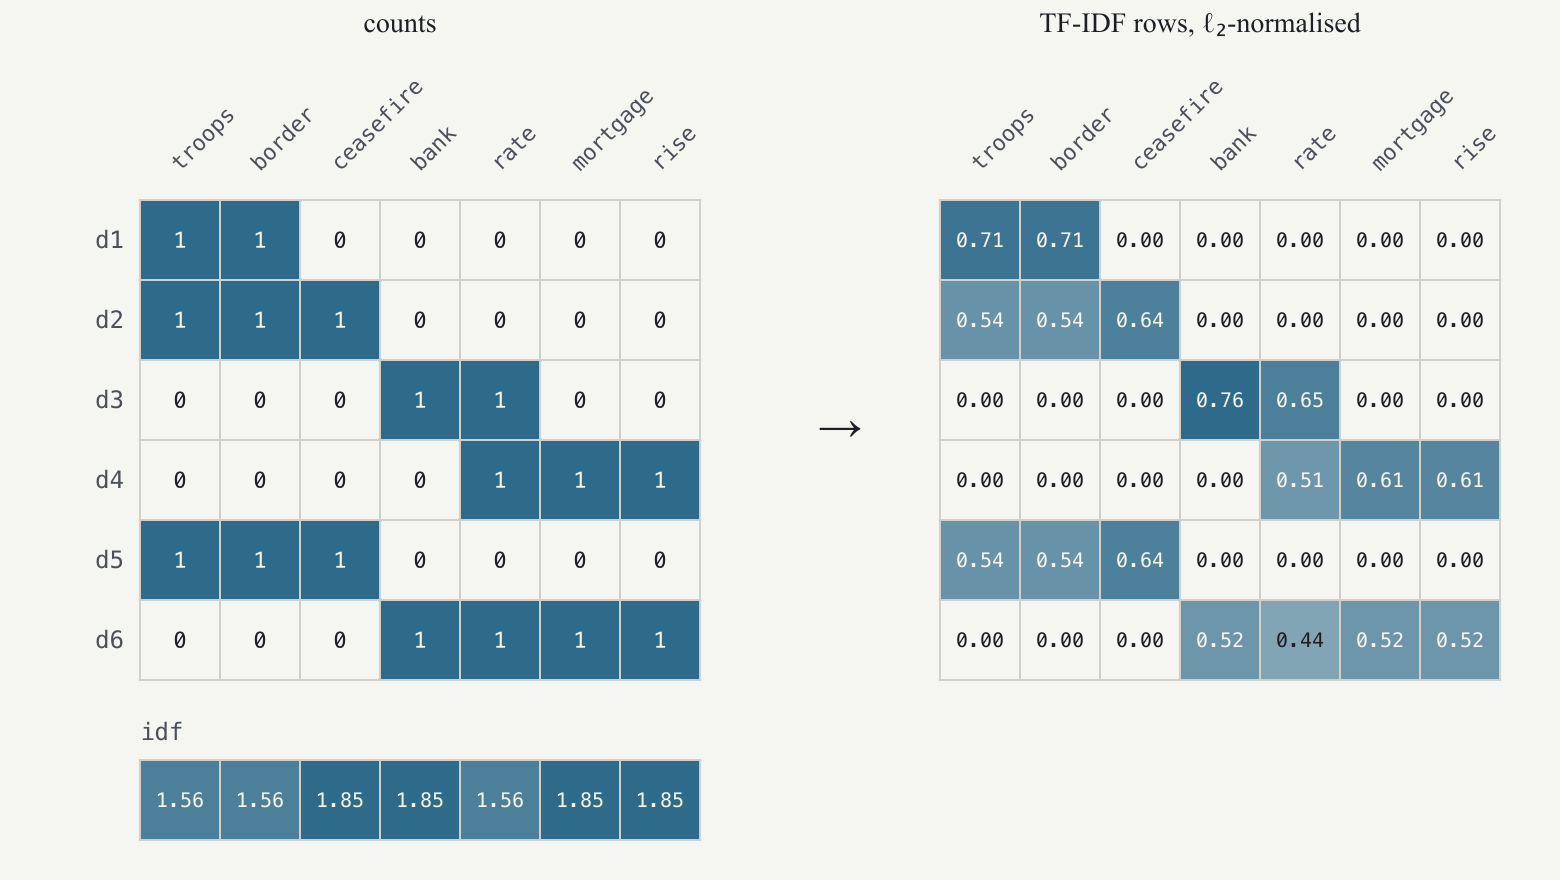

*From counts to TF‑IDF. Left: word counts for six documents over seven terms. Bottom: the idf weight of each term. Right: the TF‑IDF rows, each scaled to unit length.*

Eigen Times builds this representation over 1,093,166 articles and a 50,000‑term vocabulary, keeping terms that occur in at least 20 documents and at most 30% of them. The result has 149 million non‑zero entries out of 55 billion cells—it is 99.7% zeros. *Sparse* storage keeps only nonzero entries and their positions; *dense* storage allocates every cell. The algorithms of §5 avoid forming this full matrix densely.

### Laboratory: Damped counts, inverse frequencies, and unit rows

`df` counts positive entries down each term column; `idf` is its inverse-document
frequency. `tf` is zero for absent terms, and otherwise one plus the natural log
of the count. `tfidf` is the weighted matrix after row normalization. The asserted
values reproduce the manuscript's rounded 1.56 and 1.85.

In [4]:
let df = Array.init (cols counts) (fun j -> Array.fold_left (fun n row -> if row.(j)>0. then n+.1. else n) 0. counts);;
let idf = Array.map (fun d -> log ((float_of_int(rows counts)+.1.)/.(d+.1.))+.1.) df;;
let tfidf = Array.map (fun row -> normalize(Array.mapi(fun j c -> if c=0. then 0. else (1.+.log c)*.idf.(j)) row)) counts;;
Array.iter (fun row -> assert_close (norm row) 1.) tfidf;;
print_vector "document frequencies" df;;print_vector "idf" idf;;print_matrix "TF-IDF" tfidf;;
record_result "idf_troops" idf.(0);;record_result "idf_ceasefire" idf.(2);;

val df : float array = [|3.; 3.; 2.; 2.; 3.; 2.; 2.|]


val idf : float array =
  [|1.55961578793542266; 1.55961578793542266; 1.84729786038720367;
    1.84729786038720367; 1.55961578793542266; 1.84729786038720367;
    1.84729786038720367|]


val tfidf : float array array =
  [|[|0.707106781186547573; 0.707106781186547573; 0.; 0.; 0.; 0.; 0.|];
    [|0.542091946056473817; 0.542091946056473817; 0.642084608164228; 0.; 0.;
      0.; 0.|];
    [|0.; 0.; 0.; 0.764096101185661; 0.645102432294959227; 0.; 0.|];
    [|0.; 0.; 0.; 0.; 0.512592957245994518; 0.607144323938635821;
      0.607144323938635821|];
    [|0.542091946056473817; 0.542091946056473817; 0.642084608164228; 0.; 0.;
      0.; 0.|];
    [|0.; 0.; 0.; 0.518979050343568504; 0.438157775137522076;
      0.518979050343568504; 0.518979050343568504|]|]


- : unit = ()


- : string = "document frequencies: [3; 3; 2; 2; 3; 2; 2]"


- : string =
"idf: [1.55962; 1.55962; 1.8473; 1.8473; 1.55962; 1.8473; 1.8473]"


- : string =
"TF-IDF (6 x 7)\n : [0.707107; 0.707107; 0; 0; 0; 0; 0]\n : [0.542092; 0.542092; 0.642085; 0; 0; 0; 0]\n : [0; 0; 0; 0.764096; 0.645102; 0; 0]\n : [0; 0; 0; 0; 0.512593; 0.607144; 0.607144]\n : [0.542092; 0.542092; 0.642085; 0; 0; 0; 0]\n : [0; 0; 0; 0.518979; 0.438158; 0.518979; 0.518979]"


- : string = "idf_troops = 1.55961578794"


- : string = "idf_ceasefire = 1.84729786039"


### Laboratory: Unroll logarithms and normalize one document

Natural logarithms turn repeated doubling into repeated addition. The first
calculation computes every count-damping value in the new prose. The second
uses the exact idf values for the three nonzero positions of d2, then calculates
its length and normalized entries. Rounded display values are never substituted
back into the underlying calculations.

In [5]:
let early_counts = [|1.;2.;4.;8.|];;
let early_damped = Array.map (fun c -> 1. +. log c) early_counts;;
for i=1 to 3 do assert_close (early_damped.(i)-.early_damped.(i-1)) (log 2.) done;;
let early_row = [|1.+.log(7./.4.);1.+.log(7./.4.);1.+.log(7./.3.);0.;0.;0.;0.|];;
let early_length = norm early_row;;
let early_unit = normalize early_row;;
Array.iteri (fun j x -> assert_close x tfidf.(1).(j)) early_unit;;
assert_close (dot early_unit early_unit) 1.;;
print_vector "damped counts" early_damped;;
print_vector "normalized d2" early_unit;;
record_result "primer_log_count_8" early_damped.(3);;
record_result "primer_d2_length" early_length;;
record_result "primer_d2_first_unit_entry" early_unit.(0);;

val early_counts : float array = [|1.; 2.; 4.; 8.|]


val early_damped : float array =
  [|1.; 1.6931471805599454; 2.38629436111989079; 3.07944154167983575|]


- : unit = ()


val early_row : float array =
  [|1.55961578793542266; 1.55961578793542266; 1.84729786038720367; 0.; 0.;
    0.; 0.|]


val early_length : float = 2.87703183801396234


...

- : string = "damped counts: [1; 1.69315; 2.38629; 3.07944]"


- : string = "normalized d2: [0.542092; 0.542092; 0.642085; 0; 0; 0; 0]"


- : string = "primer_log_count_8 = 3.07944154168"


- : string = "primer_d2_length = 2.87703183801"


- : string = "primer_d2_first_unit_entry = 0.542091946056"


<a id="cosine-similarity"></a>

## Cosine similarity

Let $a$ and $b$ be two nonzero rows with the same vocabulary order, and $a_t,b_t$ their entries for term $t$. Their *dot product*, also called the Euclidean *inner product* and written $a\cdot b$, multiplies corresponding entries and adds them. For three entries this means $a_1b_1+a_2b_2+a_3b_3$; for a vocabulary it means $\sum_t a_tb_t$. Shared nonzero coordinates can contribute; a product involving an absent coordinate is zero.

The dot product alone grows if we multiply either vector by a large positive number. *Cosine similarity*, written $\cos(a,b)$, removes this dependence on overall length by dividing by both norms:

$$\cos(a, b) = \frac{a \cdot b}{\lVert a\rVert  \, \lVert b\rVert } = \sum_t a_t b_t \quad \text{when } \lVert a\rVert  = \lVert b\rVert  = 1.$$

A cosine of 1 means the same direction, 0 means perpendicular directions, and $-1$ means opposite directions. In geometric language cosine is the horizontal coordinate of a unit direction measured relative to the first direction; this connects the formula to angles. Its value always lies between −1 and 1. For nonnegative word-count or TF‑IDF rows, negative cosines cannot occur; later centered or embedded vectors can have signed entries. The zero row has no defined cosine because the denominator would be zero.

For d2 compared with itself, the dot product is its first normalized entry squared, plus the second squared, plus the third squared; the remaining products are zero. Normalization made that sum 1. Document d5 has exactly the same retained row, so the same calculation gives 1 for d2 versus d5. For d1 versus d3, every coordinate product is zero: wherever one row has a nonzero retained term, the other has zero. Their dot product, and therefore their cosine, is zero.

In Figure 1, d2 and d5 share *troops, border, ceasefire* in the same proportions and have cosine 1.0; d1 and d3 share nothing and have cosine 0. Cosine is the similarity used throughout Eigen Times—for clustering a day's articles into stories, for threading stories into episodes, for finding precedents—so §8 is largely about what values of it mean.

### Laboratory: Compute document similarity and guard zero vectors

The symmetric `similarities` table contains every pairwise cosine. Because the
TF-IDF rows have unit norm, a matrix product computes them all. The d2/d5 match is
one and the d1/d3 match is zero; the assertions use indices starting at zero in
code. A zero-vector cosine remains undefined, rather than silently becoming a
match.

In [6]:
let similarities=matmul tfidf (transpose tfidf);;
assert_close similarities.(1).(4) 1.;;assert_close similarities.(0).(2) 0.;;
print_matrix "pairwise cosines" similarities;;record_result "cosine_d2_d5" similarities.(1).(4);;
assert (Float.is_nan (cosine [|0.;0.|] [|1.;1.|]));;
print_endline "A zero norm produces an undefined cosine: production callers must reject it.";;

val similarities : float array array =
  [|[|1.00000000000000022; 0.766633782166289524; 0.; 0.;
      0.766633782166289524; 0.|];
    [|0.766633782166289524; 1.; 0.; 0.; 1.; 0.|];
    [|0.; 0.; 1.00000000000000022; 0.330674963496657093; 0.;
      0.679206515434720881|];
    [|0.; 0.; 0.330674963496657093; 1.00000000000000044; 0.;
      0.854786959016390124|];
    [|0.766633782166289524; 1.; 0.; 0.; 1.; 0.|];
    [|0.; 0.; 0.679206515434720881; 0.854786959016390124; 0.; 1.|]|]


- : unit = ()


- : unit = ()


- : string =
"pairwise cosines (6 x 6)\n : [1; 0.766634; 0; 0; 0.766634; 0]\n : [0.766634; 1; 0; 0; 1; 0]\n : [0; 0; 1; 0.330675; 0; 0.679207]\n : [0; 0; 0.330675; 1; 0; 0.854787]\n : [0.766634; 1; 0; 0; 1; 0]\n : [0; 0; 0.679207; 0.854787; 0; 1]"


- : string = "cosine_d2_d5 = 1"


- : unit = ()


A zero norm produces an undefined cosine: production callers must reject it.


- : unit = ()


<a id="embeddings"></a>

## Embeddings

A TF‑IDF vector knows only which words appear. Two headlines using no shared retained terms have perpendicular, or *orthogonal*, TF‑IDF rows even if their meanings agree. A *sentence embedding* is a vector produced by a trained neural network—a numerical model that learns from examples—in which cosine similarity can track meaning beyond vocabulary. Eigen Times uses `bge-small-en-v1.5`, trained on hundreds of millions of sentence pairs, to turn a headline and lede (opening text: the first 300 characters, at most 96 tokens, or model text units) into 384 numbers. We treat the network as a black box that gives us a vector; everything downstream is linear algebra.

An embedding coordinate need not name a recognizable topic. Meaning is represented by the pattern across coordinates and relationships among vectors. This is why a direction in embedding space will later need evidence from words before we give it a readable name.

These embedding vectors are dense and *not centred*: their mean—the coordinate-by-coordinate average—has not been subtracted. To see why this matters, consider the synthetic vectors $(1,1,0)$ and $(1,0,1)$. Their dot product is 1 and each has length $\sqrt2$, so their cosine is $1/(\sqrt2\sqrt2)=0.5$. Remove the shared component $(1,0,0)$ from both. The remaining vectors are $(0,1,0)$ and $(0,0,1)$, whose cosine is zero. Normalizing the original vectors would not remove that shared component; subtracting it changes their directions.

News embeddings also share a large common component, and the observed cosine between unrelated articles is around 0.5, not 0. The synthetic calculation demonstrates a mechanism; it does not reproduce that empirical distribution. The observation drives two of the thresholds in §8 and §9.

### Laboratory: A common component can inflate raw similarity

This **synthetic geometry** does not run or reproduce the neural embedding model.
Let `common` be a shared component; the remaining two coordinates identify
different topics. We compare raw vectors and the vectors after subtracting the
known common component. The result demonstrates a mechanism, not a re-estimate
of the archive's reported cosine distribution.

In [7]:
let common=[|1.;0.;0.|] and a=[|1.;1.;0.|] and b=[|1.;0.;1.|];;
let subtract_vector x y=Array.mapi(fun j v->v-.y.(j)) x;;
record_result "shared_component_raw_cosine" (cosine a b);;
record_result "shared_component_centered_cosine" (cosine (subtract_vector a common) (subtract_vector b common));;
assert_close (cosine a b) 0.5;;

val common : float array = [|1.; 0.; 0.|]
val a : float array = [|1.; 1.; 0.|]
val b : float array = [|1.; 0.; 1.|]


val subtract_vector : float array -> float array -> float array = <fun>


- : string = "shared_component_raw_cosine = 0.5"


- : string = "shared_component_centered_cosine = 0"


- : unit = ()


<a id="matrices-pictured"></a>

# Matrices, pictured

<a id="a-matrix-times-a-vector"></a>

## A matrix times a vector

Let $n$ count document rows and $p$ count their coordinates. Stacking them gives an $n\times p$ matrix $X$: the shape always lists rows before columns. Individual observation vectors will be written as columns when used in projection or outer-product formulas; their transposes supply the rows of a data matrix. A transpose exchanges rows and columns and is marked $\top$. Thus a column $x$ has row form $x^{\top}$.

For Figure 2, let $A$ be a $4\times3$ example matrix and $v$ a $3\times1$ column of weights, with entries $v_1$ through $v_3$. Their product $Av$ is a $4\times1$ column. Adjacent mathematical symbols mean multiplication when their shapes permit it.

The actual inputs and result are

$$A=\begin{pmatrix}2&0&1\\1&3&0\\0&1&2\\1&1&1\end{pmatrix},\qquad
v=\begin{pmatrix}1\\2\\-1\end{pmatrix},\qquad
Av=\begin{pmatrix}1\\7\\0\\2\end{pmatrix}.$$

The second output entry is $1\times1+3\times2+0\times(-1)=7$. Each row of $A$ has three entries and meets all three entries of $v$. This is why the number of columns in the matrix must equal the number of entries in the input column. There are four rows to evaluate, so the output has four entries. A negative weight is allowed: it subtracts a contribution rather than adding one.

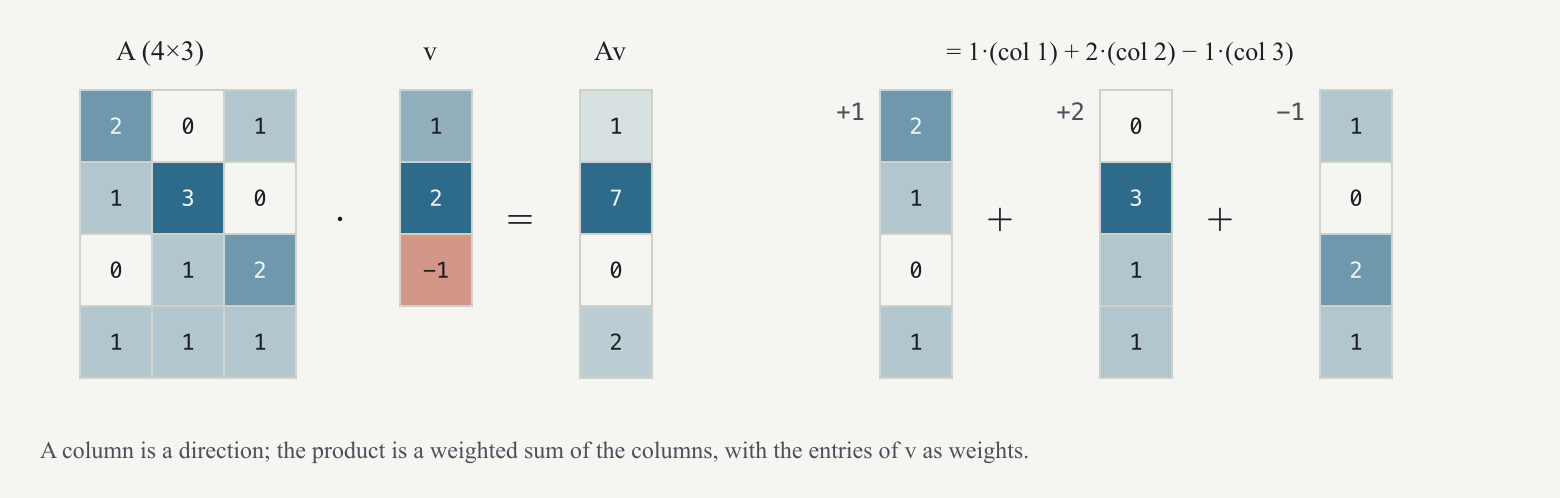

*A matrix times a vector is a weighted sum of the matrix's columns.*

The definition of $Av$ is "dot each row of $A$ with $v$", but the picture to keep is the other one (Figure 2): $Av$ is a *weighted sum of the columns of $A$*, with the entries of $v$ as the weights. If the columns of $A$ are directions, $Av$ is the point you reach by going $v_1$ of the way along the first, $v_2$ along the second, and so on. That is what "coordinates" will mean in §7: the coordinates of a story are the weights that best rebuild it from the basis directions.

In this example, take the first column once, the second column twice, and subtract the third column once. The second entries combine as $1+2\times3-0=7$, just as in the row calculation. Both descriptions perform the same multiplications; they group them differently. We will use row products to *measure* coordinates and column combinations to *rebuild* observations.

### Laboratory: Rebuild Figure 2

`a_mv` and `v_mv` are the exact Figure 2 inputs. `product` computes row dot
products; `column_sum` computes the weighted column sum. These two descriptions
must agree entry by entry.

In [8]:
let a_mv=[|[|2.;0.;1.|];[|1.;3.;0.|];[|0.;1.;2.|];[|1.;1.;1.|]|] and v_mv=[|1.;2.;-1.|];;
let product=matvec a_mv v_mv;;
let column_sum=Array.init(rows a_mv)(fun i->Array.fold_left (+.) 0. (Array.mapi(fun j v->v*.a_mv.(i).(j)) v_mv));;
Array.iteri(fun i x->assert_close x column_sum.(i)) product;;
print_vector "A v" product;;record_result "matvec_second" product.(1);;

val a_mv : float array array =
  [|[|2.; 0.; 1.|]; [|1.; 3.; 0.|]; [|0.; 1.; 2.|]; [|1.; 1.; 1.|]|]
val v_mv : float array = [|1.; 2.; -1.|]


val product : float array = [|1.; 7.; 0.; 2.|]


val column_sum : float array = [|1.; 7.; 0.; 2.|]


- : unit = ()


- : string = "A v: [1; 7; 0; 2]"


- : string = "matvec_second = 7"


<a id="a-matrix-times-a-matrix"></a>

## A matrix times a matrix

For Figure 3, take a new $3\times4$ example $A$, let $B$ be $4\times2$, and call their product $C=AB$. Indices $i$ and $j$ select a row and column: entry $C_{ij}$ is the dot product of row $i$ of $A$ with column $j$ of $B$. Shapes must agree in the middle: $(3\times4)(4\times2)$ gives $3\times2$. Each column of $B$ is a separate input vector; multiplying by a matrix carries out both matrix–vector calculations together.

Here are the inputs, with the second row and second column providing a short calculation:

$$A=\begin{pmatrix}1&2&0&1\\0&1&1&2\\2&0&1&0\end{pmatrix},\qquad
B=\begin{pmatrix}1&0\\2&1\\0&3\\1&1\end{pmatrix}.$$

The entry $C_{22}$ is $0\times0+1\times1+1\times3+2\times1=6$. The four intermediate products correspond to the common inner dimension, 4. The two outer dimensions say that there will be three output rows and two output columns. Matrix multiplication is not entry-by-entry multiplication, and reversing the order need not give the same shape or result.

Two special cases recur. If $X$ has $n$ rows and $p$ columns, $X^{\top}X$ has shape $p\times p$. A row of $X^{\top}$ is a column of $X$, so each output entry compares two columns of $X$ by their dot product. This is called a *Gram matrix*, and it is the raw material of covariance. In contrast, $XX^{\top}$ compares pairs of observation rows and has shape $n\times n$.

For the other special case, let $k$ count selected, mutually perpendicular unit directions and let $V$ contain them as $p\times1$ columns. Then $XV$ has shape $n\times k$. Entry $(i,j)$ asks how much observation $i$ points along direction $j$. This table contains every document's coordinates on those directions: the archive *projected* onto them. We will derive the reconstruction corresponding to those coordinates rather than assuming that taking a projection preserves everything.

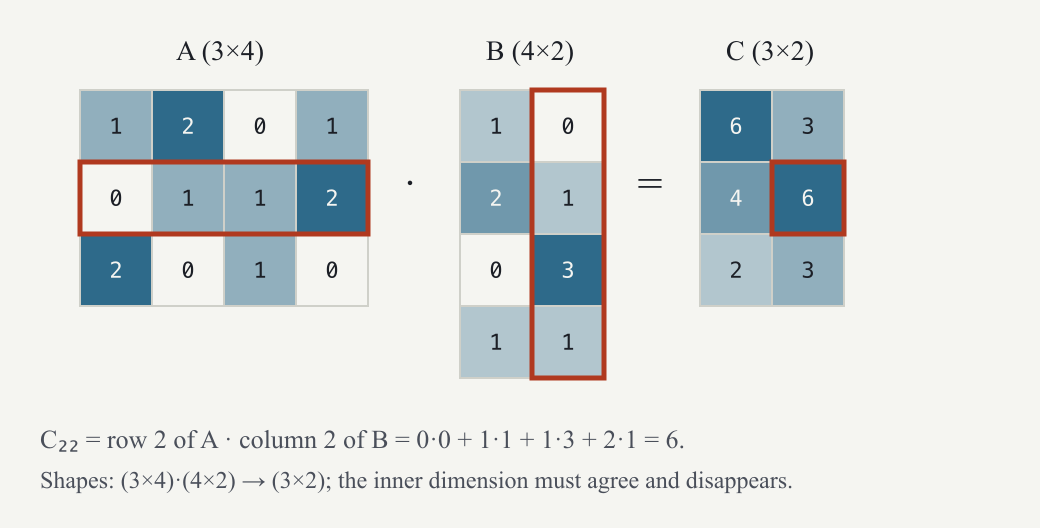

*Matrix multiplication: each entry of the product is a row of the left factor dotted with a column of the right one.*

### Laboratory: Rebuild Figure 3 and check shapes

`a_mm` is 3 by 4 and `b_mm` is 4 by 2. The product's second row, second
column is the manuscript's worked value six. A transpose exchanges row and
column roles without changing any entries.

In [9]:
let a_mm=[|[|1.;2.;0.;1.|];[|0.;1.;1.;2.|];[|2.;0.;1.;0.|]|];;
let b_mm=[|[|1.;0.|];[|2.;1.|];[|0.;3.|];[|1.;1.|]|];;
let product_mm=matmul a_mm b_mm;;assert(rows product_mm=3 && cols product_mm=2);;
assert_close product_mm.(1).(1) 6.;;print_matrix "A B" product_mm;;record_result "matrix_product_22" product_mm.(1).(1);;

val a_mm : float array array =
  [|[|1.; 2.; 0.; 1.|]; [|0.; 1.; 1.; 2.|]; [|2.; 0.; 1.; 0.|]|]


val b_mm : float array array =
  [|[|1.; 0.|]; [|2.; 1.|]; [|0.; 3.|]; [|1.; 1.|]|]


val product_mm : float array array = [|[|6.; 3.|]; [|4.; 6.|]; [|2.; 3.|]|]


- : unit = ()


- : unit = ()


- : string = "A B (3 x 2)\n : [6; 3]\n : [4; 6]\n : [2; 3]"


- : string = "matrix_product_22 = 6"


<a id="transpose-symmetry-orthogonality"></a>

## Transpose, symmetry, orthogonality

$A^{\top}$ flips rows and columns. A *square* matrix has the same number of rows and columns. Call such a matrix $S$; it is *symmetric* when $S=S^{\top}$. Real symmetric matrices, including covariances, admit a complete set of real, mutually perpendicular eigenvector directions, defined in the next chapter.

<a id="matrix-orthonormality"></a>

### Perpendicular directions and what their products say

Two vectors are perpendicular when their dot product is zero. Unit-length perpendicular columns are *orthonormal*: "ortho" refers to perpendicularity and "normal" to unit length. The identity matrix $I$ has ones on its diagonal and zeros elsewhere; multiplying by it changes nothing. A $p\times k$ matrix $V$ with orthonormal columns satisfies $V^{\top}V=I$, with a $k\times k$ identity. Each diagonal entry in this product is a column's squared length, so it is 1. Each off-diagonal entry compares two different columns, so it is 0.

Directions are *independent* when none can be formed as a weighted combination of the others. A *basis* is an independent collection spanning the space under discussion: its combinations reach every point in that space. The dimension counts the number of basis directions. A matrix's *rank* counts the independent directions among its columns, equivalently among its rows. Listing a direction twice does not give us an extra independent direction.

<a id="rotation-versus-projection"></a>

### A rotation keeps a whole space; a projection keeps part

If $k=p$, the matrix $V$ is square and *orthogonal*. It has enough orthonormal columns to describe the whole space. Multiplication by $V$ or $V^{\top}$ rotates or reflects coordinates and preserves lengths and angles. It also satisfies $VV^{\top}=I$, so projecting and rebuilding recovers every input exactly.

If $k<p$, the map $V^{\top}x$ keeps only selected coordinates of an observation column $x$. Rebuilding gives $VV^{\top}x$, its orthogonal projection onto the retained subspace. Now $VV^{\top}$ need not be the identity: the missing directions cannot be recovered merely by changing back to the original number of coordinates.

For the notebook's example, take $x=(1,2,3)^{\top}$ and let $V$ contain the first two coordinate directions in three dimensions. The superscript $\top$ makes the displayed list a column. Projection gives $(1,2)^{\top}$ and rebuilding gives $(1,2,0)^{\top}$. The squared lengths are $1+4+9=14$ before projection and $1+4=5$ afterward. Nine units of squared length lie in the discarded coordinate. The rectangular matrix obeys $V^{\top}V=I$, but the reconstruction operator is the diagonal matrix with entries 1, 1, 0, not a three-dimensional identity.

A quarter-turn in the retained plane maps $(1,2)^{\top}$ to $(-2,1)^{\top}$. The squared length remains $4+1=5$. This separates two operations that the later pipeline uses for different purposes: retaining a subspace loses information; rotating coordinates within it does not.

### Laboratory: A projection is not a full rotation

`basis` retains two axes in three-dimensional space. It has orthonormal columns,
but its projection drops the third coordinate. `rotation` is square and
orthogonal, so it preserves lengths. We explicitly check the distinction that
motivated the companion's notation correction.

In [10]:
let basis=take_cols (eye 3) 2 and observation=[|1.;2.;3.|];;
assert_matrix (matmul(transpose basis)basis) (eye 2);;
let kept=matvec(transpose basis)observation;;assert_close(dot kept kept)5.;;
let rotation=[|[|0.;-1.|];[|1.;0.|]|];;
assert_close(norm(matvec rotation [|1.;2.|]))(sqrt 5.);;
record_result "discarded_projection_energy" (dot observation observation -. dot kept kept);;

val basis : float array array = [|[|1.; 0.|]; [|0.; 1.|]; [|0.; 0.|]|]
val observation : float array = [|1.; 2.; 3.|]


- : unit = ()


val kept : float array = [|1.; 2.|]


- : unit = ()


val rotation : float array array = [|[|0.; -1.|]; [|1.; 0.|]|]


- : unit = ()


- : string = "discarded_projection_energy = 9"


<a id="the-covariance-and-its-eigenvectors"></a>

# The covariance and its eigenvectors

<a id="centering-and-covariance"></a>

## Centering and covariance

<a id="covariance-scalar-first"></a>

### From an average to a measure of spread

The *mean* is an average: add the observations and divide by their count. For the scalar values 1, 2, and 3, the mean is $(1+2+3)/3=2$. Their *deviations* are the observed values minus that mean: −1, 0, and 1. Subtracting a common reference mean is called *centering*. The centered values say where each observation lies relative to that reference rather than relative to zero on the original scale.

Adding signed deviations gives zero here. That does not mean there is no spread; the negative and positive deviations cancel. Squaring avoids this cancellation. The squared deviations are 1, 0, and 1, whose mean is $2/3$. This average squared deviation is the *variance* under the total-count convention used for the fitted covariance. Its nonnegative square root, $\sqrt{2/3}\approx0.8165$, is the *standard deviation*. If observations are measured in some unit, variance is measured in that unit squared; standard deviation returns to the original unit.

Some statistical estimates divide the sum of squared deviations by one less than the count, to correct a bias when estimating a population variance from a sample. That is a different convention. The fitted covariance below divides by total weight. We will identify the reference and divisor when using a standard deviation elsewhere.

<a id="covariance-pairwise-products"></a>

### How two coordinates vary together

For more than one coordinate, calculate a mean for each coordinate. Consider the two observation rows $(1,2)$ and $(3,4)$. Their mean row is $(2,3)$, and their centered rows are $(-1,-1)$ and $(1,1)$. The first-coordinate squared deviations average to 1; the second-coordinate squared deviations also average to 1. The products between the first and second deviations are $(-1)(-1)=1$ and $(1)(1)=1$, so their average is also 1.

That last average is the *covariance* between the two coordinates. It is positive when deviations tend to have matching signs, negative when they tend to have opposite signs, and zero when their average product is zero. Statistical independence means that knowing one variable supplies no information about the other. Zero covariance does not generally establish independence: two variables may still have a relationship that this signed product does not detect.

Arrange these averages in a table. Diagonal entries compare a coordinate with itself and are variances; off-diagonal entries are covariances. For the two-row example the table is

$$\begin{pmatrix}1&1\\1&1\end{pmatrix}.$$

To compute every pairwise product at once, place a centered observation in a column and multiply it by its transpose. This *outer product* produces a square table. Its entry in row $j$, column $l$ is the product of centered coordinates $j$ and $l$. The two indices select coordinates, not articles. Averaging these tables produces the covariance matrix.

<a id="covariance-weights"></a>

### Fit weights change the average, not the operation

Let $i$ index fitted articles, from 1 to $n$, and let $d$ count embedding coordinates. Each $x_i$ is a $d\times1$ column; row $i$ of the $n\times d$ data matrix $X$ is $x_i^{\top}$. Let $w_i$ be its nonnegative fit weight. A *weighted mean* gives each observation the stated weight, adds the weighted contributions, then divides by the total weight. Let $Z>0$ be that total and $\mu$ the $d\times1$ weighted mean. A sum over $i$ includes every fitted article, and $Z^{-1}$ means $1/Z$:

$$Z = \sum_i w_i, \qquad \mu = Z^{-1} \sum_i w_i x_i,$$

For example, give the two observation rows above weights 1 and 3. The total is 4, the first mean coordinate becomes $(1\times1+3\times3)/4=2.5$, and the second becomes 3.5. Centering must use this new weighted mean. The centered rows are $(-1.5,-1.5)$ and $(0.5,0.5)$. The weighted mean of either squared coordinate is $(1\times2.25+3\times0.25)/4=0.75$. Every entry of this example's weighted covariance is 0.75.

Let $\Sigma$ name the $d\times d$ weighted covariance. Apply precisely the same weights to the outer products of deviations from the weighted mean:

$$\Sigma = Z^{-1} \sum_i w_i (x_i - \mu)(x_i - \mu)^{\top}.$$

The first edition uses uniform article weights; the later archive fit uses inverse daily article counts, explained in §11. These weights are distinct from the story energy used to rank news. In Eigen Times $d=384$, so $\Sigma$ is a $384\times384$ matrix—147,456 numbers summarising the fitted article cloud. Figure 4 pictures the operations in their working order: center each observation, take its outer product, and average the products.

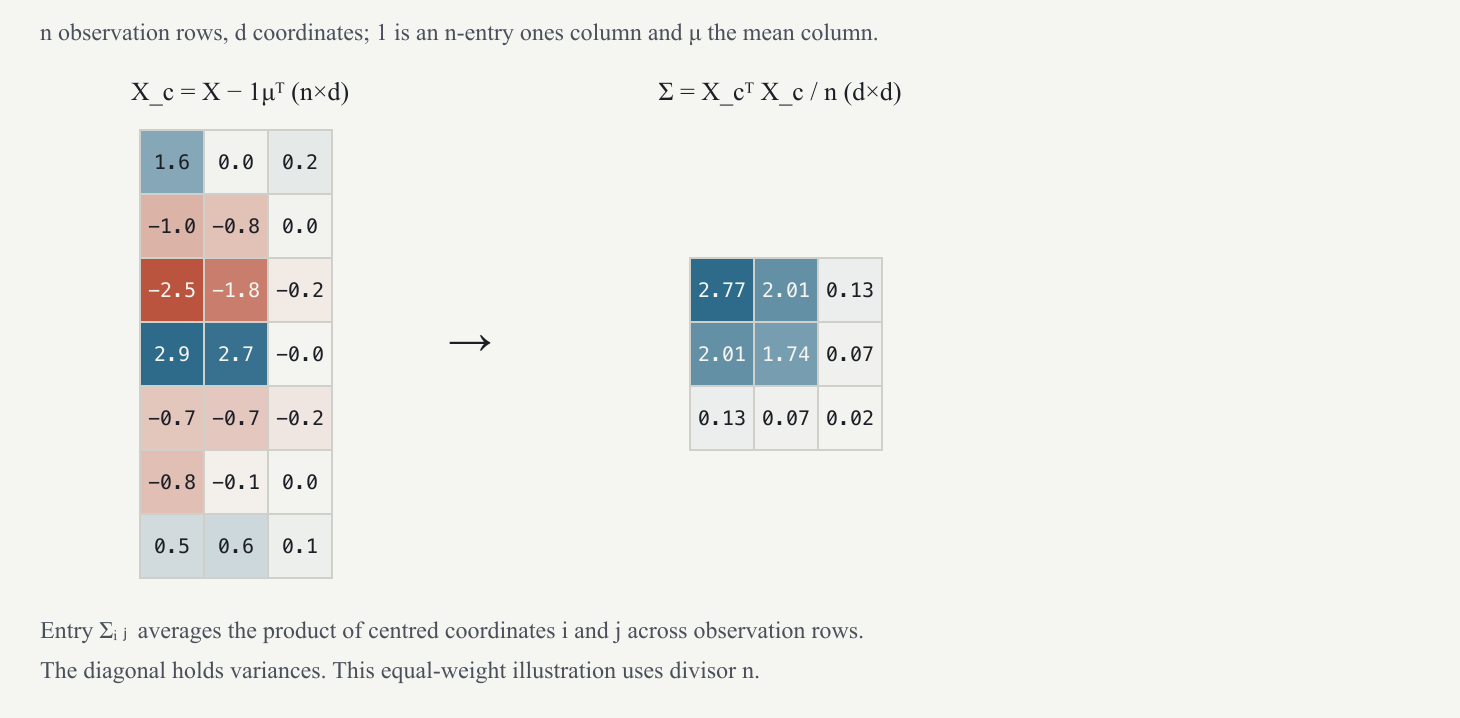

*The covariance matrix: centre the rows, then average the outer products.*

<a id="covariance-three-sums"></a>

### Why three sums suffice to update the covariance

A practical point matters for updates. Let $m$ be the $d\times1$ weighted coordinate sum and $M$ the $d\times d$ weighted outer-product sum:

$$m=\sum_i w_i x_i,\qquad M=\sum_i w_i x_i x_i^{\top}.$$

The mean is immediately $m/Z$. To recover covariance, first expand a single centered outer product:

$$(x_i-\mu)(x_i-\mu)^{\top}
=x_ix_i^{\top}-x_i\mu^{\top}-\mu x_i^{\top}+\mu\mu^{\top}.$$

Now take the weighted average of all four terms. The first becomes $M/Z$. In the second and third terms, the weighted average of $x_i$ is $\mu$, so each becomes $-\mu\mu^{\top}$. The last term is the same for every observation and averages to $+\mu\mu^{\top}$. Two subtractions and one addition leave one subtraction:

$$\mu=m/Z,\qquad \Sigma=M/Z-\mu\mu^{\top}.$$

The three running sums $Z,m,M$ therefore retain everything needed for these mean and covariance calculations. They do not retain the full article collection. New observations with fixed weights can be added without revisiting old observations. If a day's final article count changes its existing weights, the old contributions must also be corrected. Although the identity is exact, subtracting large nearly equal floating-point numbers can lose accuracy; the streaming chapter distinguishes algebraic identities from numerical reliability.

For compact matrix notation, let $W=\mathrm{diag}(w_1,\ldots,w_n)$ be the $n\times n$ diagonal weight matrix: $\mathrm{diag}$ puts the listed values on the diagonal and zeros elsewhere. Let $\mathbf1$ be a column of $n$ ones. Multiplying $\mathbf1\mu^{\top}$ repeats the mean row $n$ times. The centered data matrix is therefore $X_c=X-\mathbf1\mu^{\top}$. Multiplying $WX_c$ scales each centered row by its weight; multiplying on the left by $X_c^{\top}$ then sums the weighted products. This gives the same covariance as $\Sigma=X_c^{\top}WX_c/Z$.

### Laboratory: Compute Figure 4 and a weighted covariance two ways

`covariance_rows` embeds the seven raw numeric rows generated by Figure 4's seed
3 recipe; freezing these inputs lets both languages compute the same example
without pretending their random generators are identical. `weights` are an
editable synthetic unequal-weight fixture. `mu` is the weighted mean and `cov`
the total-weight-normalized covariance. `moment_cov` reconstructs it from the
three sufficient sums. No sample-size correction is applied here.

In [11]:
let figure_cov=scale (1./.float_of_int(rows covariance_rows)) (matmul(transpose covariance_rows)covariance_rows);;
let weights=[|1.;2.;1.;3.;1.;2.;1.|];;
let mu,cov=covariance covariance_rows weights;;
let z=Array.fold_left (+.) 0. weights;;
let m=matvec(transpose covariance_rows)weights;;
let second=matmul(transpose covariance_rows)(Array.mapi(fun i row->Array.map(( *.)weights.(i))row)covariance_rows);;
let moment_cov=sub (scale(1./.z)second)(outer(Array.map(fun x->x/.z)m)(Array.map(fun x->x/.z)m));;
assert_matrix cov moment_cov;;assert_matrix cov(transpose cov);;
let trace a=Array.fold_left (+.) 0. (Array.mapi(fun i row->row.(i))a);;
print_matrix "Figure 4 covariance" figure_cov;;print_matrix "weighted covariance" cov;;
record_result "figure_covariance_trace" (trace figure_cov);;record_result "weighted_covariance_trace" (trace cov);;

val figure_cov : float array array =
  [|[|2.77432461588681045; 2.00992468692331938; 0.127040607627749047|];
    [|2.00992468692331938; 1.74414064337935515; 0.0662836063512091678|];
    [|0.127040607627749047; 0.0662836063512091678; 0.0195341126458454979|]|]


val weights : float array = [|1.; 2.; 1.; 3.; 1.; 2.; 1.|]


val mu : float array =
  [|0.357982679326957098; 0.418600724952504721; 0.00398672965053945352|]
val cov : float array array =
  [|[|3.30547448159822155; 2.64216787811347542; 0.0702662598281518641|];
    [|2.64216787811347542; 2.35165388181077661; 0.0340313639014317715|];
    [|0.0702662598281518641; 0.0340313639014317715; 0.012589748879782087|]|]


val z : float = 11.


val m : float array =
  [|3.9378094725965278; 4.60460797447755166; 0.0438540261559339922|]


...

val trace : float array array -> float = <fun>


- : string =
"Figure 4 covariance (3 x 3)\n : [2.77432; 2.00992; 0.127041]\n : [2.00992; 1.74414; 0.0662836]\n : [0.127041; 0.0662836; 0.0195341]"


- : string =
"weighted covariance (3 x 3)\n : [3.30547; 2.64217; 0.0702663]\n : [2.64217; 2.35165; 0.0340314]\n : [0.0702663; 0.0340314; 0.0125897]"


- : string = "figure_covariance_trace = 4.53799937191"


- : string = "weighted_covariance_trace = 5.66971811229"


### Laboratory: Build mean, variance and covariance by hand

The scalar values 1, 2, 3 establish mean, deviations, variance and standard
deviation before the two-coordinate table is considered. Both covariance
examples use the total-weight divisor, matching this chapter. Unequal weights
change the mean, so deviations must be recomputed before products are averaged.
The final check independently expands the weighted outer-product sum.

In [12]:
let early_scalar = [|1.;2.;3.|];;
let early_scalar_mean = Array.fold_left (+.) 0. early_scalar /. 3.;;
let early_deviations = Array.map (fun x -> x-.early_scalar_mean) early_scalar;;
let early_variance = dot early_deviations early_deviations /. 3.;;
assert_close early_scalar_mean 2.;;
assert_close (Array.fold_left (+.) 0. early_deviations) 0.;;
assert_close early_variance (2./.3.);;
let early_cov_rows = [|[|1.;2.|];[|3.;4.|]|];;
let early_unweighted_mean,early_unweighted_cov = covariance early_cov_rows [|1.;1.|];;
let early_cov_weights = [|1.;3.|];;
let early_weighted_mean,early_weighted_cov = covariance early_cov_rows early_cov_weights;;
assert_matrix early_unweighted_cov [|[|1.;1.|];[|1.;1.|]|];;
Array.iteri (fun i x -> assert_close x [|2.5;3.5|].(i)) early_weighted_mean;;
assert_matrix early_weighted_cov [|[|0.75;0.75|];[|0.75;0.75|]|];;
let early_moment = scale (1./.4.) (Array.fold_left add (zeros 2 2)
  (Array.mapi (fun i row -> scale early_cov_weights.(i) (outer row row)) early_cov_rows));;
assert_matrix (sub early_moment (outer early_weighted_mean early_weighted_mean)) early_weighted_cov;;
print_vector "scalar deviations" early_deviations;;
print_matrix "weighted covariance" early_weighted_cov;;
record_result "primer_scalar_variance" early_variance;;
record_result "primer_scalar_sd" (sqrt early_variance);;
record_result "primer_weighted_covariance" early_weighted_cov.(0).(1);;

val early_scalar : float array = [|1.; 2.; 3.|]


val early_scalar_mean : float = 2.


val early_deviations : float array = [|-1.; 0.; 1.|]


val early_variance : float = 0.66666666666666663


- : unit = ()


...

- : string = "scalar deviations: [-1; 0; 1]"


- : string = "weighted covariance (2 x 2)\n : [0.75; 0.75]\n : [0.75; 0.75]"


- : string = "primer_scalar_variance = 0.666666666667"


- : string = "primer_scalar_sd = 0.816496580928"


- : string = "primer_weighted_covariance = 0.75"


<a id="eigenvectors-the-axes-of-the-cloud"></a>

## Eigenvectors: the axes of the cloud

A cloud of points in $d$ dimensions has a shape. It can be broad in one direction and narrow in another, even when neither direction follows an original coordinate axis. We want to measure that shape using perpendicular directions. The special directions of the covariance matrix will supply them.

A nonzero $d\times1$ column $v$ is an *eigenvector* of $\Sigma$ with *eigenvalue* $\lambda$ when $\Sigma v=\lambda v$. The left side multiplies the vector by a matrix; the right side multiplies it by a scalar. Equality says that this input stays on its own line under the matrix operation. For a positive eigenvalue it points the same way and changes length by that factor; a zero eigenvalue sends it to zero.

<a id="eigenpair-by-hand"></a>

### Check an eigenpair by multiplication

Consider the separate exact example

$$\Sigma=\begin{pmatrix}2&1\\1&2\end{pmatrix}.$$

Multiplying by $(1,1)^{\top}$ gives $(3,3)^{\top}=3(1,1)^{\top}$. Multiplying by $(1,-1)^{\top}$ gives $(1,-1)^{\top}=1(1,-1)^{\top}$. We have found two eigendirections and eigenvalues 3 and 1. Their dot product is zero. Their lengths are both $\sqrt2$, so divide each by $\sqrt2$ to obtain unit columns, called $v_1$ and $v_2$. Scaling an eigenvector to unit length does not change its eigenvalue.

This is a way to verify an answer, not an assumption that every covariance's eigenvectors are easy to guess. Numerical algorithms find them for larger matrices. The purpose of the example is to make the equation an operation we can inspect.

For a covariance, eigenvalues are nonnegative. Here is why. Let $u$ be any unit column direction and let $a_i=u^{\top}(x_i-\mu)$ be observation $i$'s scalar projection score along it. Its weighted mean is zero because the observations were centered. Its weighted variance is the average squared score. Substituting the covariance definition gives

$$Z^{-1}\sum_i w_i a_i^2=u^{\top}\Sigma u.$$

The left side is an average of nonnegative squares. If $u$ is a unit eigenvector with eigenvalue $\lambda$, the right side becomes $u^{\top}(\lambda u)=\lambda(u^{\top}u)=\lambda$. Thus the eigenvalue is exactly the variance along that unit direction and cannot be negative.

<a id="eigenbasis-and-variance"></a>

### Write the whole covariance in its own directions

Choose $d$ unit, mutually perpendicular eigenvectors $v_j$, ordered by decreasing eigenvalue $\lambda_j$, with $j=1,\ldots,d$. Real symmetric matrices permit such a choice, although repeated eigenvalues need not specify unique individual directions. Let $V$ contain those columns and $\Lambda$ the diagonal matrix of their eigenvalues, both $d\times d$. They diagonalise the covariance, meaning

$$\Sigma = V\Lambda V^{\top},\qquad V^{\top}V=I,\qquad \Lambda=\mathrm{diag}(\lambda_1,\ldots,\lambda_d),$$

where $\lambda_1\ge\lambda_2\ge\cdots\ge\lambda_d\ge0$ and $\ge$ means greater than or equal to. The diagonal representation has zero covariances between different eigenvector coordinates. The *principal components* are these directions, ranked by variance; using them to summarize the cloud is principal component analysis (PCA).

Read the factorization from right to left when applying it to a column: $V^{\top}$ expresses the input in eigenvector coordinates, $\Lambda$ scales each coordinate separately, and $V$ expresses the result back in the original coordinates. The covariance is simple in this basis because no off-diagonal terms mix the coordinates.

Why does the first direction capture the most variance? Express an arbitrary unit direction as a combination $u=\sum_j\alpha_jv_j$, where each scalar $\alpha_j$ is its coordinate in the full orthonormal eigenbasis. Its unit length means $\sum_j\alpha_j^2=1$. Its projected variance becomes

$$u^{\top}\Sigma u=\sum_j\lambda_j\alpha_j^2.$$

The squared coordinates are nonnegative and add to one. The variance is therefore a weighted average of the eigenvalues and cannot exceed the largest, $\lambda_1$. Choosing $u=v_1$ reaches that largest value. Requiring the next direction to be perpendicular to $v_1$ sets its first coordinate to zero; the same argument then selects $v_2$. This explains the ordering without assuming calculus.

Figure 5 shows 300 points in two dimensions: the long axis has eigenvalue 4.06, the short one 0.44, so about 90% of the displayed variation lies along one direction. The synthetic distribution has known mean zero. This illustration forms second moments about that origin, rather than subtracting the finite sample's empirical mean; the displayed eigenvalues estimate population variances. The notebook computes both choices so that centering is an explicit decision.

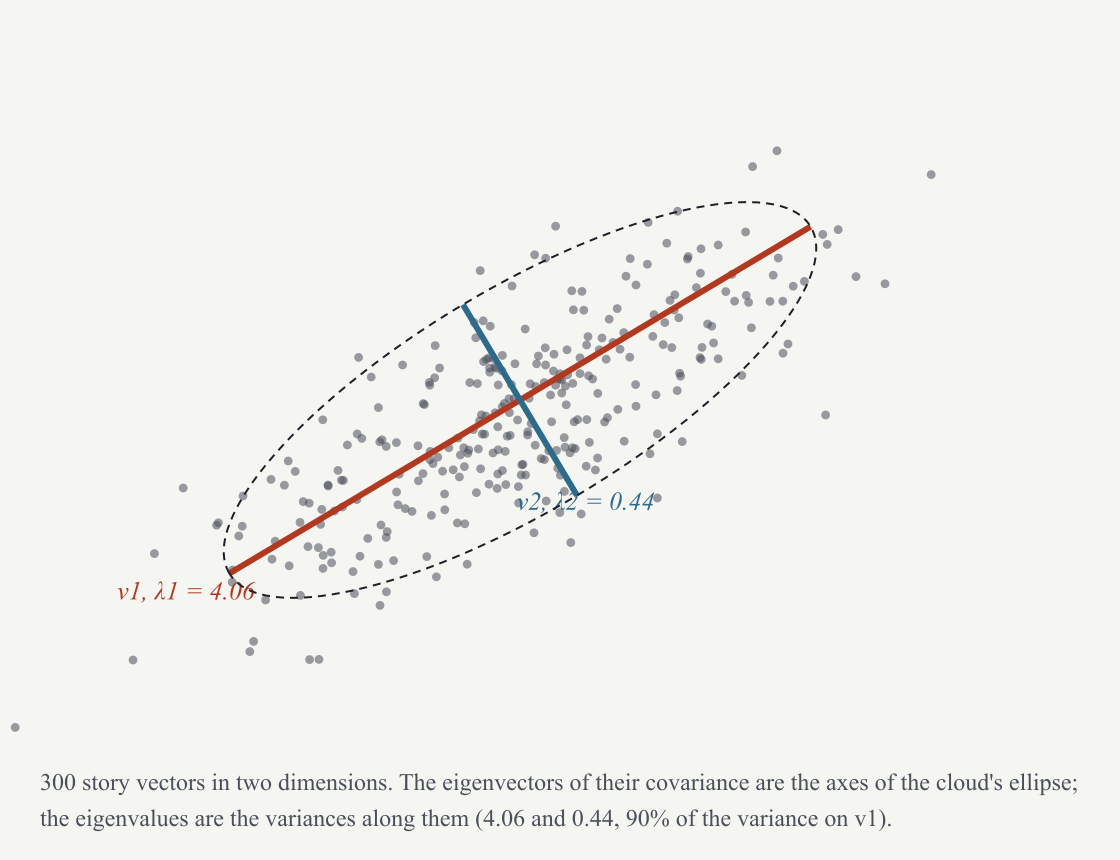

*Eigenvectors describe the point cloud's axes. This synthetic illustration estimates variances about the known population mean zero.*

This is the content of "the eigen‑news are the directions that explain the most variance". Variance describes spread in the chosen numerical representation; the argument alone does not establish significance, truth, or editorial importance. Computing eigenvectors for a $384\times384$ symmetric matrix is a standard numerical operation (`eigh` in common linear-algebra libraries; `faer` in the Rust implementation) and takes milliseconds in the reported fit.

### Laboratory: Recompute the 300-point illustration

`cloud_points` contains the exact synthetic Figure 5 input rows. The manuscript
uses their second moment about the **known population mean zero**. We reproduce
that choice rather than silently replacing it with empirical centering. `lam`
contains descending eigenvalues and `eigenvectors` their unit column directions.
We verify the eigen-equation and full reconstruction, and then compare the
slightly different empirically centered covariance.

In [13]:
let cloud_second=scale(1./.float_of_int(rows cloud_points))(matmul(transpose cloud_points)cloud_points);;
let lam,eigenvectors=eig_sym cloud_second;;
assert_matrix(matmul cloud_second eigenvectors)(matmul eigenvectors(diag lam));;
assert_matrix(matmul(matmul eigenvectors(diag lam))(transpose eigenvectors))cloud_second;;
assert_close ~tol:0.00015 lam.(0) 4.055;;assert_close ~tol:0.0004 lam.(1) 0.438;;
let _,centered_cloud=covariance cloud_points(Array.make(rows cloud_points)1.);;
print_vector "eigenvalues about known mean zero" lam;;print_vector "empirically centered eigenvalues" (fst(eig_sym centered_cloud));;
record_result "cloud_lambda_1" lam.(0);;record_result "cloud_lambda_2" lam.(1);;record_result "cloud_variance_fraction" (lam.(0)/.Array.fold_left (+.) 0. lam);;

val cloud_second : float array array =
  [|[|3.10526432015023302; 1.59188949228161847|];
    [|1.59188949228161847; 1.38786783732547492|]|]


val lam : float array = [|4.05528795493699512; 0.437844202538712701|]
val eigenvectors : float array array =
  [|[|0.858706633123480834; -0.512467480167996259|];
    [|0.512467480167996259; 0.858706633123480834|]|]


- : unit = ()


- : unit = ()


- : unit = ()


...

- : string = "eigenvalues about known mean zero: [4.05529; 0.437844]"


- : string = "empirically centered eigenvalues: [4.03338; 0.418543]"


- : string = "cloud_lambda_1 = 4.05528795494"


- : string = "cloud_lambda_2 = 0.437844202539"


- : string = "cloud_variance_fraction = 0.902552565295"


### Laboratory: Verify an exact eigenpair and its variance budget

This exact covariance is independent of the 300-point figure fixture. Multiplying
the two proposed unit directions proves their eigen-equations. The final
calculation writes a unit direction as a combination of those two eigenvectors
and verifies the weighted-average formula for projected variance.

In [14]:
let early_sigma = [|[|2.;1.|];[|1.;2.|]|];;
let early_v = scale (1./.sqrt 2.) [|[|1.;1.|];[|1.;-1.|]|];;
let early_lam = [|3.;1.|];;
assert_matrix (matmul (transpose early_v) early_v) (eye 2);;
assert_matrix (matmul early_sigma early_v) (matmul early_v (diag early_lam));;
assert_matrix (matmul (matmul early_v (diag early_lam)) (transpose early_v)) early_sigma;;
let early_alpha = [|0.6;0.8|];;
let early_direction = matvec early_v early_alpha;;
let early_projected_variance = dot early_direction (matvec early_sigma early_direction);;
assert_close early_projected_variance (dot early_lam (Array.map (fun x->x*.x) early_alpha));;
assert(early_projected_variance>=1. && early_projected_variance<=3.);;
print_matrix "unit eigenvectors" early_v;;
record_result "primer_exact_eigenvalue" early_lam.(0);;
record_result "primer_exact_retained_fraction" (early_lam.(0)/.(early_lam.(0)+.early_lam.(1)));;
record_result "primer_variance_weighted_average" early_projected_variance;;

val early_sigma : float array array = [|[|2.; 1.|]; [|1.; 2.|]|]


val early_v : float array array =
  [|[|0.707106781186547462; 0.707106781186547462|];
    [|0.707106781186547462; -0.707106781186547462|]|]


val early_lam : float array = [|3.; 1.|]


- : unit = ()


- : unit = ()


...

- : unit = ()


- : string =
"unit eigenvectors (2 x 2)\n : [0.707107; 0.707107]\n : [0.707107; -0.707107]"


- : string = "primer_exact_eigenvalue = 3"


- : string = "primer_exact_retained_fraction = 0.75"


- : string = "primer_variance_weighted_average = 1.72"


<a id="how-many-axes-to-keep"></a>

## How many axes to keep

Let $k\le d$ count retained directions; $\le$ means less than or equal to. The *explained-variance fraction* is $\sum_{j=1}^{k}\lambda_j/\sum_{j=1}^{d}\lambda_j$, provided total variance is positive. It reports how much of the fitted cloud's variation those directions retain. For the Eigen Times embedding basis, 60 components carry 55% of the variance, and the curve is flat beyond; a small eigenvalue alone does not prove that a direction is meaningless.

In the exact two-direction example, total variance is $3+1=4$. Keeping the first direction retains $3/4=75\%$ and discards $1/4=25\%$. Keeping both retains all the variance. With a longer list of eigenvalues, make the same running calculation: add the retained values, divide by the sum of all values, and inspect what each extra direction contributes. A flat part of that curve means that each new direction adds little to the numerator. It does not mean that the discarded articles or subjects are unimportant.

The *Marchenko–Pastur edge* asks a different question: how large might covariance eigenvalues be in a specified model of featureless variation? Here *noise* means variation generated by that reference model, not a judgment about an article. The *spectrum* of a covariance is its collection of eigenvalues. In this illustration, let $N$ count independent observations in $d$ coordinates with equal noise variance $\sigma^2$, unrelated to the singular-value notation used later. For a concrete reference, suppose all entries are independent draws from the same zero-mean Gaussian distribution, a symmetric bell-shaped probability model, with variance $\sigma^2$. Independence applies across both observations and coordinates; repeated draws use the same distribution. These assumptions specify an illustrative noise model, not a description of news embeddings. Let $\lambda_+$ denote the approximate upper edge of the model's covariance spectrum. Under that model, in the large-sample limit,

$$\lambda_{+} = \sigma^2 \left(1 + (d/N)^{1/2}\right)^2,$$

Here raising to $1/2$ means taking a square root. First form the dimension-to-observation ratio $d/N$, take its square root, add one, square, and multiply by the stipulated variance. The notebook uses $\sigma^2=0.01$, $N=1{,}000{,}000$, and $d=384$, giving approximately 0.010396. That is slightly larger than 0.01: finite sampling can spread estimated variances even when the model gives every coordinate the same underlying variance. This teaching input is not an estimate fitted to news.

Eigenvalues near or below such a reference may be noise; this is not a universal significance test for correlated, weighted news data. The median eigenvalue supplies a rough noise-variance estimate in the reported comparison. With $N\approx10^6$ and $d=384$, the ratio $d/N$ is tiny and the edge is close to that estimate. The deployed bases use fixed $k=60$, with the variance curve as a check. From here onward $V$ usually means only the retained $d\times k$ columns and $\Lambda$ their $k\times k$ positive eigenvalue matrix; full decompositions will be identified explicitly.

### Laboratory: Variance retention and a noise-model reference

`noise_variance` is an illustrative assumed noise variance, not a fit to news.
`edge` is the Marchenko–Pastur reference for one million independent observations
and 384 coordinates. It is close to that variance because the dimension/count
ratio is small. We also evaluate the exact two-dimensional variance curve. The
book's 60-axis/55% archive result remains a dated observation, not something a
300-point toy fixture can reproduce.

In [15]:
let noise_variance=0.01 and sample_count=1000000. and dimensions=384.;;
let edge=noise_variance*.(1.+.sqrt(dimensions/.sample_count))**2.;;
print_vector "retained fractions" [|lam.(0)/.(lam.(0)+.lam.(1));1.|];;
record_result "mp_edge" edge;;

val noise_variance : float = 0.01
val sample_count : float = 1000000.
val dimensions : float = 384.


val edge : float = 0.0103957583588453056


- : string = "retained fractions: [0.902553; 1]"


- : string = "mp_edge = 0.0103957583588"


<a id="the-singular-value-decomposition-and-lsa"></a>

# The singular value decomposition and LSA

<a id="what-the-svd-is"></a>

## What the SVD is

The eigendecomposition works on a square covariance. The *singular value decomposition* (SVD) works directly on a rectangular data matrix. It separates a matrix operation into input directions, nonnegative scale factors, and output directions. The input and output can have different dimensions, so the directions on the two sides need not live in the same space.

<a id="svd-one-direction"></a>

### Follow one input direction through a rectangular table

For this chapter let $X$ be any $n\times d$ matrix. A column input has $d$ entries and the output $Xv$ has $n$ entries. In the small example

$$X=\begin{pmatrix}3&0\\0&2\\0&0\end{pmatrix},$$

the input $(1,0)^{\top}$ maps to $(3,0,0)^{\top}$, which is three times the unit output direction $(1,0,0)^{\top}$. The input $(0,1)^{\top}$ maps to $(0,2,0)^{\top}$, which is twice $(0,1,0)^{\top}$. These perpendicular input directions map to perpendicular output directions, with scale factors 3 and 2. The output has three entries even though the input has two.

For a general matrix, SVD finds suitable directions even when the input table is not already diagonal. Let $v_j$ be a unit *right singular direction* in the input space, let $u_j$ be its unit *left singular direction* in the output space, and let $\sigma_j$ be their nonnegative scale. The key relation is $Xv_j=\sigma_ju_j$. "Right" and "left" describe where the directions appear in the factorization; neither means an orientation on a page. A zero scale contributes no output in that direction.

<a id="svd-factors"></a>

### Assemble the separate directions into matrices

Let $U$ be an $n\times n$ orthogonal matrix of left directions, and $V$ a $d\times d$ orthogonal matrix of right directions. Let $\Sigma_{\mathrm{svd}}$ be an $n\times d$ rectangular diagonal matrix: its only potentially nonzero entries lie where row and column indices agree. Those entries are the singular values $\sigma_j$ in decreasing order. Then

$$X=U\Sigma_{\mathrm{svd}}V^{\top}.$$

Figure 6 labels this singular-value matrix with the traditional bare $\Sigma$; it is a different object from the covariance $\Sigma$ in §4. The columns of $V$ are directions indexed by features, and those of $U$ are directions indexed by observations. Actual coordinate scores are $XV=U\Sigma_{\mathrm{svd}}$, not $U$ alone: each left direction must receive its singular-value scale.

Read the product from right to left, as with eigendecomposition. $V^{\top}$ resolves an input into right-direction coordinates; $\Sigma_{\mathrm{svd}}$ scales those coordinates and accounts for the change in dimension; $U$ writes the result in the original output coordinates. For the $3\times2$ example, full factors can use a $3\times3$ identity for $U$, a $2\times2$ identity for $V$, and the displayed rectangular table for $\Sigma_{\mathrm{svd}}$. Nothing needs turning because the table already uses suitable directions.

Let $q=\min(n,d)$, where $\min$ selects the smaller number. The *thin* SVD removes the unused full-matrix directions: it has $U$ of shape $n\times q$, $\Sigma_{\mathrm{svd}}$ of shape $q\times q$, and $V$ of shape $d\times q$, with the same product $X$. Keeping only $k<q$ directions is the further operation of *truncation*.

In the example, $q=2$. The thin $U$ keeps the first two columns of the three-dimensional identity, the scale matrix becomes $\mathrm{diag}(3,2)$, and $V$ remains the two-dimensional identity. Multiplying these factors still reconstructs every entry. Thin factorization changes storage without losing any information; truncation will deliberately lose contributions.

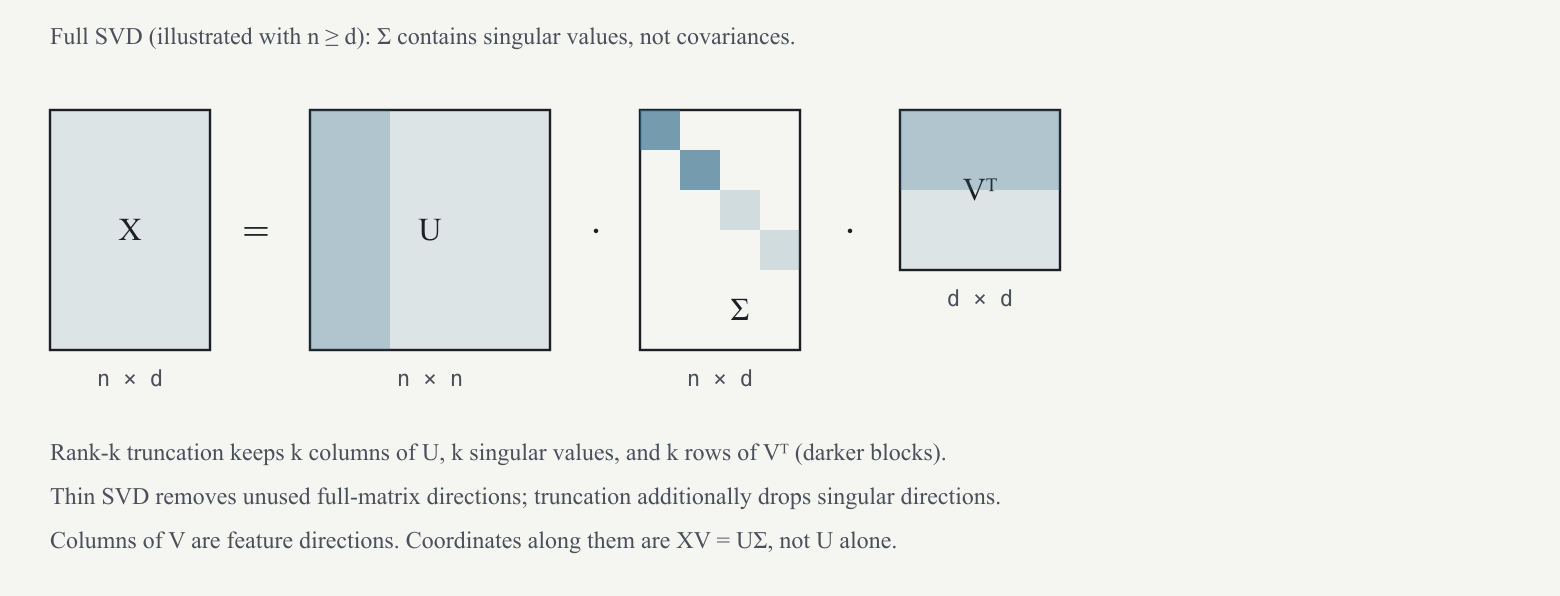

*The SVD as blocks. The darker parts illustrate a rank-k truncation: k columns of U, k singular values, and k rows of the transpose of V. The figure's Sigma denotes the singular-value matrix.*

<a id="svd-covariance-bridge"></a>

### Why covariance eigenvalues contain squared singular values

Transposing a product reverses its order: $(AB)^{\top}=B^{\top}A^{\top}$. Apply that rule to the SVD, multiply, and use $U^{\top}U=I$. For the full rectangular decomposition the steps are

$$X^{\top}X
=V\Sigma_{\mathrm{svd}}^{\top}U^{\top}U\Sigma_{\mathrm{svd}}V^{\top}
=V(\Sigma_{\mathrm{svd}}^{\top}\Sigma_{\mathrm{svd}})V^{\top}.$$

Each diagonal entry in the middle is a singular value multiplied by itself. For the thin decomposition the middle product is the square diagonal matrix $\Sigma_{\mathrm{svd}}^2$. Thus the right singular directions are also eigenvectors of the Gram matrix, with squared singular values as eigenvalues. In the exact example, the Gram matrix is $\mathrm{diag}(9,4)$.

If $X$ is centered and equally weighted, covariance is that Gram matrix divided by $n$. Its right directions therefore stay the same, and its eigenvalues are $\lambda_j=\sigma_j^2/n$. The diagonal example above is not centered, so its Gram matrix should not silently be called an empirical centered covariance. The notebook also applies the identity to the centered six-document table.

For the weighted covariance of §4, instead decompose $W^{1/2}X_c$. Here $W^{1/2}$ is diagonal with entries $\sqrt{w_i}$, so it scales each centered row by the square root of its weight. When we form a Gram product, one square-root weight comes from each factor; their product is the full weight $w_i$. Divide the resulting squared singular values by total weight $Z$. Scores for the original, unweighted observations are still $X_cV$, not the weighted rows' scores. A direction's *canon* is its representative collection of high-scoring stories; a left singular vector alone is not generally the original article-score column in a weighted fit.

### Laboratory: Thin factors, scores and covariance eigenvalues

`u_svd`, `singular`, and `v_svd` are thin SVD factors of the six-document
matrix, with the right directions stored as **columns**, not transposed rows.
OCaml computes them natively from a Jacobi eigendecomposition of the small Gram
matrix. Squaring a matrix condition number makes this a teaching technique for
small fixtures, not a production SVD recommendation. Singular values whose squares fall below a scale-relative roundoff threshold
are treated as numerical zero; their left directions are completed orthonormally. We verify
reconstruction, scaled scores, and the centered covariance identity.

In [16]:
let u_svd,singular,v_svd=thin_svd tfidf;;
assert_matrix(reconstruct_svd u_svd singular v_svd (Array.length singular))tfidf;;
assert_matrix ~tol:1e-7 (matmul tfidf v_svd)(matmul u_svd(diag singular));;
let centered_t=center tfidf(mean_rows tfidf);;
let _,center_singular,_=thin_svd centered_t;;
let center_lam,_=eig_sym(scale(1./.float_of_int(rows tfidf))(matmul(transpose centered_t)centered_t));;
Array.iteri(fun i s->assert_close center_lam.(i)(s*.s/.float_of_int(rows tfidf)))center_singular;;
print_vector "singular values" singular;;record_result "singular_1" singular.(0);;record_result "singular_2" singular.(1);;

val u_svd : float array array =
  [|[|0.539079262743377; 0.; 0.; -0.842255037669741191; 0.;
      6.13580557242980918e-18|];
    [|0.595564248624805059; 0.; 0.; 0.381186602282886422; 0.;
      0.707106781186547462|];
    [|0.; 0.498798544539350242; 0.795078740596090738; 0.;
      0.345035952065230744; 0.|];
    [|0.; 0.570517479825636831; -0.600881052262838611; 0.;
      0.559867632789133651; 0.|];
    [|0.595564248624805059; 0.; 0.; 0.381186602282886422; 0.;
      -0.707106781186547462|];
    [|0.; 0.652464418323965; -0.0824121185484165547; 0.; -0.7533249136578;
      0.|]|]
val singular : float array =
  [|1.64131778803004; 1.5055469307157634; 0.824433522657502;
    0.553241284338195638; 0.231598372470290942; 0.|]
val v_svd : float array array =
  [|[|0.625648350885633642; 0.; -0.; -0.329490729815099581; -0.; 0.|];
    [|0.625648350885633642; 0.; -0.; -0.329490729815099581; -0.; 0.|];
    [|0.465970258780722957; 0.; -0.; 0.884800383098824139; -0.; 0.|];
    [|0.; 0.478062405548633773

- : unit = ()


- : unit = ()


val centered_t : float array array =
  [|[|0.408558335636631687; 0.408558335636631687; -0.214028202721409322;
      -0.213845858588204901; -0.265975527446412618; -0.187687229047034054;
      -0.187687229047034054|];
    [|0.243543500506557931; 0.243543500506557931; 0.428056405442818644;
      -0.213845858588204901; -0.265975527446412618; -0.187687229047034054;
      -0.187687229047034054|];
    [|-0.298548445549915886; -0.298548445549915886; -0.214028202721409322;
      0.550250242597456; 0.379126904848546609; -0.187687229047034054;
      -0.187687229047034054|];
    [|-0.298548445549915886; -0.298548445549915886; -0.214028202721409322;
      -0.213845858588204901; 0.2466174297995819; 0.419457094891601767;
      0.419457094891601767|];
    [|0.243543500506557931; 0.243543500506557931; 0.428056405442818644;
      -0.213845858588204901; -0.265975527446412618; -0.187687229047034054;
      -0.187687229047034054|];
    [|-0.298548445549915886; -0.298548445549915886; -0.214028202721409322;
 

val center_singular : float array =
  [|1.57461201405842477; 0.826721238116735258; 0.555363477948651485;
    0.250443086475945764; 0.; 0.|]


val center_lam : float array =
  [|0.413233832469521556; 0.113911334258877894; 0.0514047654398703882;
    0.0104536232605996777; 4.60093587115648286e-17; 3.47423711099616755e-18;
    0.|]


- : unit = ()


- : string =
"singular values: [1.64132; 1.50555; 0.824434; 0.553241; 0.231598; 0]"


- : string = "singular_1 = 1.64131778803"


- : string = "singular_2 = 1.50554693072"


### Laboratory: Follow a rectangular diagonal matrix through full and thin factors

The three-row, two-column diagonal example allows every factor to be inspected.
The left directions have three entries and the right directions have two.
Full and thin factors reconstruct the same table; its Gram matrix contains
squared scales 9 and 4. The table is deliberately not centered and is not
presented as a centered covariance example.

In [17]:
let early_rect = [|[|3.;0.|];[|0.;2.|];[|0.;0.|]|];;
let early_full_u=eye 3 and early_full_v=eye 2;;
assert_matrix (matmul (matmul early_full_u early_rect) (transpose early_full_v)) early_rect;;
let early_thin_u=take_cols early_full_u 2 and early_scales=[|3.;2.|];;
assert_matrix (matmul (matmul early_thin_u (diag early_scales)) (transpose early_full_v)) early_rect;;
assert_matrix (matmul early_rect early_full_v) (matmul early_thin_u (diag early_scales));;
assert_matrix (matmul (transpose early_rect) early_rect) (diag [|9.;4.|]);;
print_matrix "rectangular matrix" early_rect;;
record_result "primer_rectangular_first_scale" early_scales.(0);;
record_result "primer_rectangular_gram_second" (matmul (transpose early_rect) early_rect).(1).(1);;

val early_rect : float array array = [|[|3.; 0.|]; [|0.; 2.|]; [|0.; 0.|]|]


val early_full_u : float array array =
  [|[|1.; 0.; 0.|]; [|0.; 1.; 0.|]; [|0.; 0.; 1.|]|]
val early_full_v : float array array = [|[|1.; 0.|]; [|0.; 1.|]|]


- : unit = ()


val early_thin_u : float array array = [|[|1.; 0.|]; [|0.; 1.|]; [|0.; 0.|]|]
val early_scales : float array = [|3.; 2.|]


- : unit = ()


- : unit = ()


- : unit = ()


- : string = "rectangular matrix (3 x 2)\n : [3; 0]\n : [0; 2]\n : [0; 0]"


- : string = "primer_rectangular_first_scale = 3"


- : string = "primer_rectangular_gram_second = 4"


<a id="truncation"></a>

## Truncation

Let $U_k$ and $V_k$ contain the first $k$ columns of the thin factors, and let $\Sigma_k$ contain their $k$ singular values on its diagonal. Their shapes are $n\times k$, $d\times k$, and $k\times k$, respectively. The approximation $X_k=U_k\Sigma_kV_k^{\top}$ has rank at most $k$. It keeps only $k$ independent contributions with which to rebuild the table.

<a id="svd-residual-length"></a>

### Measure what a reconstruction leaves behind

The residual table is original minus reconstructed, $X-X_k$. A positive residual entry says that the reconstruction was smaller than the original there; a negative entry says it was larger. Adding those signed errors would allow overestimates and underestimates to cancel. Instead square every entry and add. This is the *sum of squared errors*. *Least squares* means choosing a reconstruction that makes such a sum as small as the allowed family permits.

The *Frobenius norm*, written $\lVert A\rVert_F$ for a matrix $A$, is the square root of the sum of all its squared entries. It extends vector length to a whole table by treating every cell as a coordinate. Minimizing this norm or its square gives the same minimizing table, because the square-root function preserves order among nonnegative numbers.

In the rectangular diagonal example, keeping the scale 3 and dropping the scale 2 reconstructs only the entry 3. The residual has a single nonzero entry, 2. Its squared Frobenius norm is therefore 4, and its norm is 2. The original table's squared norm is $9+4=13$. Define *relative error* as residual norm divided by the positive original norm; here it is $2/\sqrt{13}\approx0.5547$. An error ratio is not a proportion of articles reconstructed correctly; it compares geometric lengths in this representation.

<a id="least-squares-derivative-primer"></a>

### A small detour: what minimizing and differentiating mean

Before asking a matrix theorem to minimize anything, solve a scalar fitting problem. Suppose we must replace the observations 1, 2, and 3 by one common fitted value, called $\theta$ (Greek theta). Their residuals are $1-\theta$, $2-\theta$, and $3-\theta$. Let $J(\theta)$ name their sum of squared residuals; $J$ is a *function*, a rule returning a number for each proposed input $\theta$. Expanding the three squares gives

$$\begin{aligned}
J(\theta)&=(1-\theta)^2+(2-\theta)^2+(3-\theta)^2\\
&=3\theta^2-12\theta+14\\
&=3(\theta-2)^2+2.
\end{aligned}$$

The last form makes the minimum visible. A square cannot be negative, and $(\theta-2)^2$ is zero exactly when $\theta=2$. Thus the smallest squared error is 2. Trying $\theta=1$ or $\theta=3$ gives squared error 5. At the best fit the signed residuals are −1, 0, and 1; their sum is zero, while their *sum of squares* is two. These are different quantities.

*Differentiation* provides another way to inspect how changing the fit changes the error. Let $h$ be a small nonzero change in $\theta$. The difference $J(\theta+h)-J(\theta)$ is the change in error. Divide by $h$ to obtain change in error per unit change in the fitted value, an average *slope* over that step. Expanding the quadratic and canceling equal terms gives

$$\frac{J(\theta+h)-J(\theta)}{h}=6\theta-12+3h.$$

As the step becomes arbitrarily small, the last term approaches zero. The resulting local slope is the *derivative*, written $J'(\theta)$ or $\mathrm{d}J/\mathrm{d}\theta$; the prime here means derivative, not the rotated coordinate notation used later:

$$J'(\theta)=6\theta-12.$$

We differentiated to learn which way the error changes. Below 2 the slope is negative, so increasing the fit locally lowers error; above 2 the slope is positive, so increasing it locally raises error. At 2 the slope is zero. A zero derivative is a *stationary point*, not automatically a minimum for every function. Here the completed-square formula proves it is the global minimum. This example supplies the meaning of derivative, the calculation from a small change, and the reason for setting it to zero. No matrix differentiation is required to use the SVD that follows.

<a id="svd-best-rank"></a>

### The best reconstruction within a rank budget

The Eckart–Young theorem says that the truncated SVD minimizes $\lVert X-X_k\rVert_F$ among all matrices of rank at most $k$. This comparison matters: we are not saying that an arbitrary reconstruction is best, or that the reconstruction is a true explanation of the subjects. We are choosing the best approximation under this particular squared-error measure and rank constraint.

The squared error equals the sum of squared discarded singular values. To see the accounting, each singular component has a unit left direction, a unit right direction, and a scale $\sigma_j$. Its contribution to squared table length is $\sigma_j^2$. Distinct components are perpendicular when their tables are compared entry by entry, so their squared lengths add without cross terms. Keeping the largest scales retains the most of this length budget. The theorem adds the stronger claim that no different rank-$k$ table does better.

Figure 7 applies this to the six-document matrix of Figure 1. Its singular values are 1.64, 1.51, 0.82, 0.55, and then almost nothing. Relative error means $\lVert X-X_k\rVert_F/\lVert X\rVert_F$ for nonzero $X$. Compute it by squaring and adding the discarded singular values, dividing by the sum of all squared singular values, and taking a square root. Rank 1 rebuilds only the war documents (relative error 0.74); rank 2 rebuilds both blocks, war and banking, and the error drops to 0.42; rank 3 reaches 0.24. Two components already separate the two kinds of document in this small example. The notebook uses unrounded singular values, so its checks do not accumulate rounding error from the printed labels.

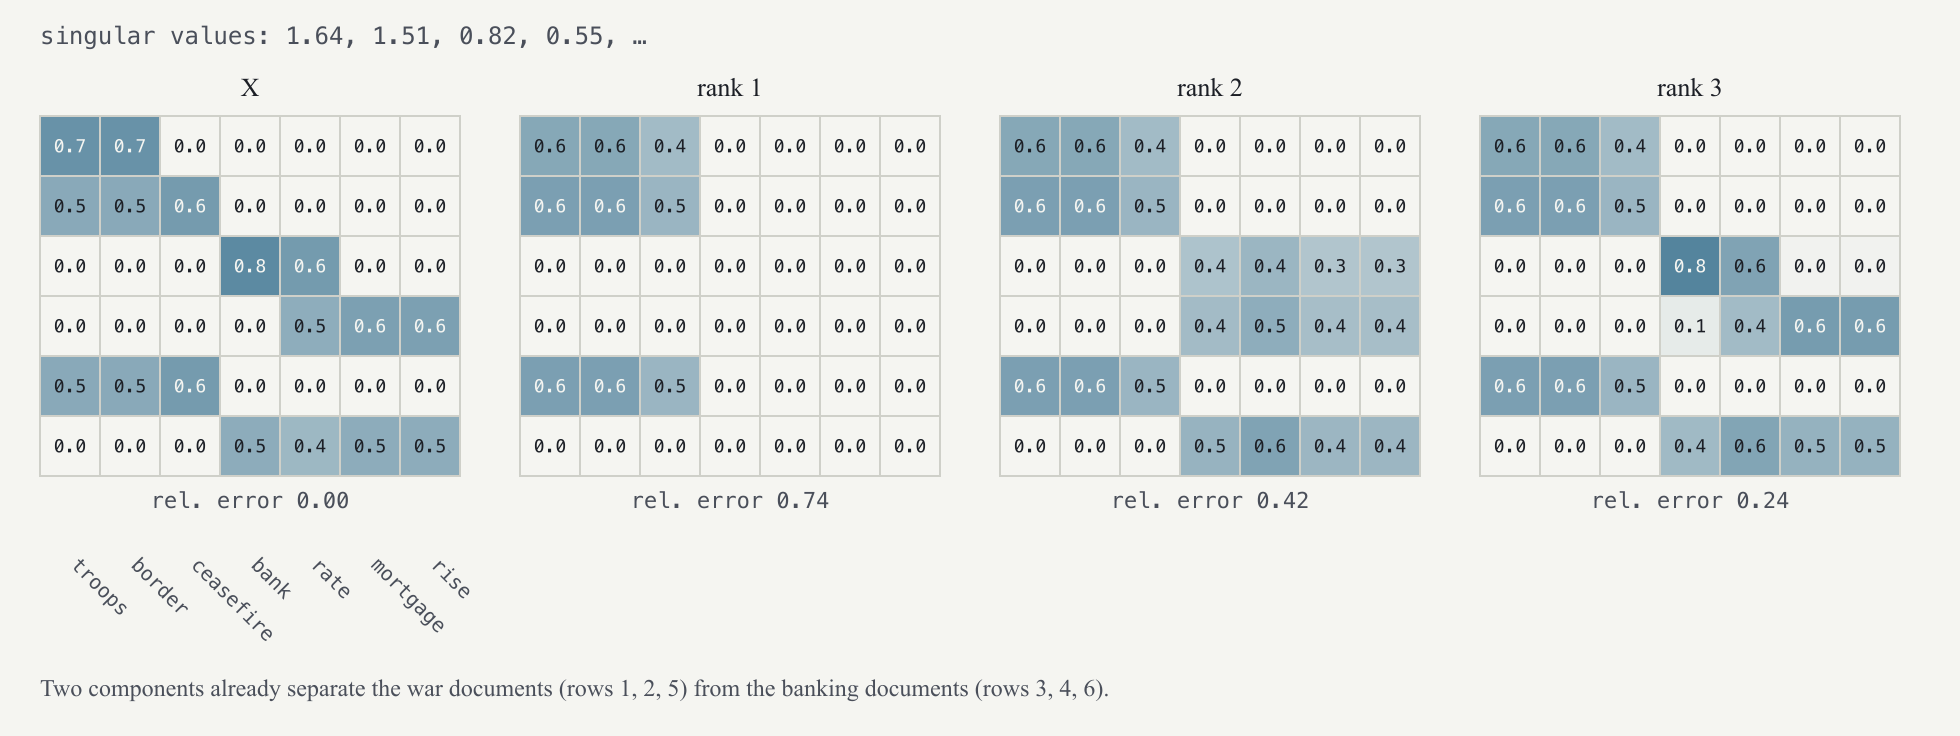

*Truncated SVD of the toy corpus. Rank 1 captures one block; rank 2 captures both.*

### Laboratory: Recompute every low-rank error in Figure 7

For retained rank `k`, `reconstruction` keeps the first `k` scaled singular
directions. The relative Frobenius error can also be computed from discarded
squared singular values. These are the exact six-document worked examples;
rounded values agree with the manuscript and `example-numbers.json`.

In [18]:
let rank_errors=ref [];;
for k=1 to 3 do
  let reconstruction=reconstruct_svd u_svd singular v_svd k in
  let error=frob(sub tfidf reconstruction)/.frob tfidf in
  let tail=Array.fold_left (+.) 0. (Array.mapi(fun i s->if i>=k then s*.s else 0.)singular) in
  assert_close error(sqrt(tail/.dot singular singular));
  ignore(record_result(Printf.sprintf "rank_%d_relative_error" k)error);
  rank_errors:= !rank_errors @ [k,error]
done;;
!rank_errors;;

val rank_errors : '_weak1 list ref = {contents = []}


- : unit = ()


- : (int * float) list =
[(1, 0.742302265331333588); (2, 0.416213959021983826);
 (3, 0.244851562117086197)]


### Laboratory: Residual lengths and a derivative built from small changes

First drop the smaller scale of the exact rectangular table and compute its
residual norm. Then fit one value theta to 1, 2, 3. We calculate residuals,
squared error, the completed-square identity, and the finite-step slope.
The derivative is the limiting slope 6 theta minus 12. The exact quadratic
identity establishes a minimum; a zero derivative alone would not establish one
for an arbitrary function. Differences use moderate step sizes so cancellation
does not dominate this floating-point illustration.

In [19]:
let early_rank_one=[|[|3.;0.|];[|0.;0.|];[|0.;0.|]|];;
let early_rectangular_residual=sub early_rect early_rank_one;;
let early_relative_error=frob early_rectangular_residual/.frob early_rect;;
assert_close ((frob early_rectangular_residual)**2.) 4.;;
assert_close early_relative_error (2./.sqrt 13.);;
let early_j theta=Array.fold_left (fun total value->total+.(value-.theta)**2.) 0. [|1.;2.;3.|];;
Array.iter (fun theta ->
  assert_close (early_j theta) (3.*.(theta-.2.)**2.+.2.);
  Array.iter (fun h ->
    let slope=(early_j(theta+.h)-.early_j theta)/.h in
    assert_close ~tol:1e-8 slope (6.*.theta-.12.+.3.*.h)) [|0.1;0.01;0.001|]) [|1.;1.5;2.;2.5;3.|];;
Array.iteri (fun i theta->assert_close (early_j theta) [|5.;2.;5.|].(i)) [|1.;2.;3.|];;
let early_best_residuals=Array.map (fun x->x-.2.) [|1.;2.;3.|];;
assert_close (Array.fold_left (+.) 0. early_best_residuals) 0.;;
assert_close (dot early_best_residuals early_best_residuals) 2.;;
print_vector "best residuals" early_best_residuals;;
record_result "primer_rectangular_relative_error" early_relative_error;;
record_result "primer_least_squares_minimum" (early_j 2.);;
record_result "primer_derivative_at_three" (6.*.3.-.12.);;

val early_rank_one : float array array =
  [|[|3.; 0.|]; [|0.; 0.|]; [|0.; 0.|]|]


val early_rectangular_residual : float array array =
  [|[|0.; 0.|]; [|0.; 2.|]; [|0.; 0.|]|]


val early_relative_error : float = 0.554700196225229147


- : unit = ()


- : unit = ()


...

- : unit = ()


- : string = "best residuals: [-1; 0; 1]"


- : string = "primer_rectangular_relative_error = 0.554700196225"


- : string = "primer_least_squares_minimum = 2"


- : string = "primer_derivative_at_three = 6"


<a id="latent-semantic-analysis"></a>

## Latent semantic analysis

*Latent semantic analysis* (LSA) uses a truncated SVD of a document–term matrix such as TF‑IDF; Eigen Times additionally centres and, in the archive edition, weights that matrix. Each retained column of $V$ is a direction over terms. Its entries are *loadings*: coefficients telling how strongly each input feature contributes to the direction. Its largest term loadings provide a word list (Figure 8). In the toy corpus the first component loads on *troops, border, ceasefire*, the second on *bank, rate, mortgage, rise*. In the real Eigen Times v0 basis the axes read *bank · financial · credit · rate · loan*, *Russian · Russia · Ukraine · Putin · Moscow*, *flight · airline · passenger · airport · crash*, and so on—sixty word lists that a reader recognises at once.

There are two distinct roles for a loading. When measuring an article's coordinate, multiply each term entry by the direction's loading for that term, then add the products. When reconstructing an article, multiply that whole direction by the article's coordinate on it. A loading's sign determines which pole of the direction it supports; its magnitude measures strength within this numerical representation. Neither alone is a probability that a document concerns a subject. A word list is a reading aid extracted from the direction, not a replacement for its full vector.

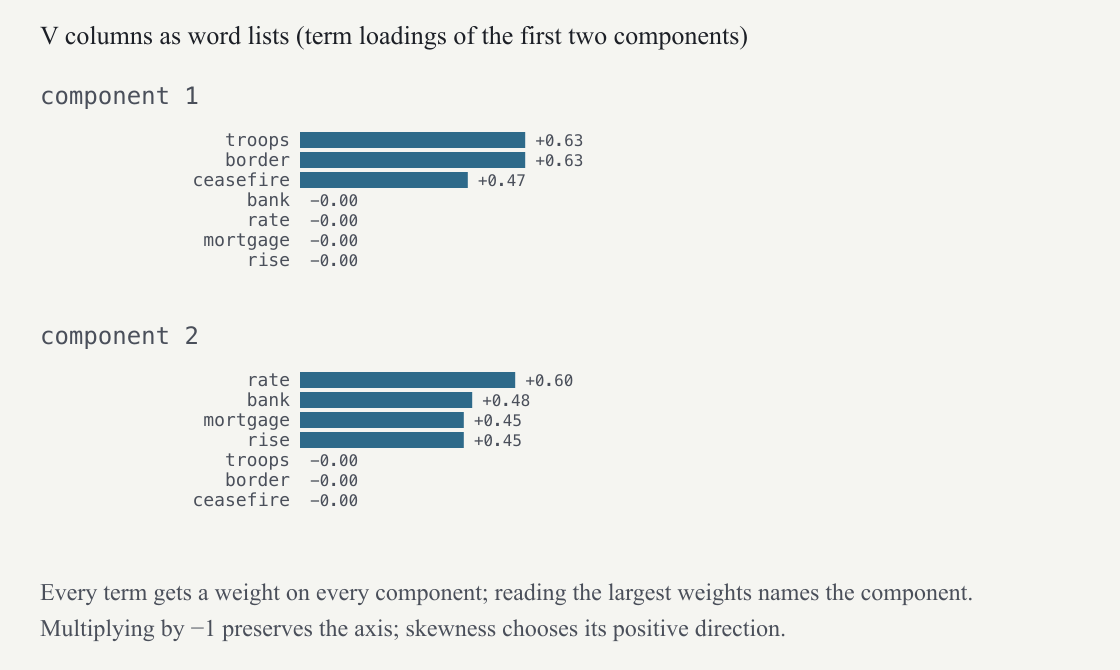

*Term loadings: each column of $V$ is a weighted word list.*

The small factorization can be computed directly. The real document–term table needs two additional ideas: applying a centered table without storing it, and finding its leading directions through a much smaller working space. We develop them separately.

<a id="lsa-implicit-centering"></a>

### Apply centering without storing a dense centered table

For this calculation, $X$ has $n$ document rows and $p$ term columns, $\mu$ is its $p\times1$ reference mean, and $\mathbf1$ has $n$ entries. Forming $X_c=X-\mathbf1\mu^{\top}$ would turn many absent-term zeros into negative mean values and destroy sparsity. We can still calculate a product involving $X_c$ without storing those changed cells.

Let $l$ count a small number of working columns, let $\Omega$ (capital omega) be any $p\times l$ matrix, and let $Y$ be $n\times l$. Each column of $\Omega$ is an input direction. Expand the centered product using the rule that multiplication distributes over subtraction:

$$X_c\Omega=(X-\mathbf1\mu^{\top})\Omega
=X\Omega-(\mathbf1\mu^{\top})\Omega.$$

Associativity lets us change the grouping in the last product without changing its order. Compute the small $1\times l$ row $\mu^{\top}\Omega$ first, then repeat that row $n$ times using $\mathbf1$. For the transposed operation, apply the same reasoning. The resulting identities are

$$X_c\Omega=X\Omega-\mathbf1(\mu^{\top}\Omega),$$
$$X_c^{\top}Y=X^{\top}Y-\mu(\mathbf1^{\top}Y).$$

The results have shapes $n\times l$ and $p\times l$. In the second correction, $\mathbf1^{\top}Y$ adds each column of $Y$ over observations; multiplying those column totals by $\mu$ constructs the needed adjustment. Each correction is an outer product, of rank at most one, because all its columns are scalar multiples of the same column. The sparse $X$ is used as is; the centered dense matrix need never be stored. The notebook verifies both identities against a directly centered small table before using them in the larger algorithm.

<a id="lsa-randomized-range"></a>

### Build a small working space

A $1{,}093{,}166\times50{,}000$ matrix is far too large for a full classical SVD here, but only the top 60 directions are wanted. The method of Halko, Martinsson and Tropp approximates them with repeated matrix products. Draw a random $50{,}000\times80$ matrix $\Omega$: $l=80$ working columns provide $k=60$ desired directions plus 20 extra directions for approximation. Each random column mixes many input features; applying $X_c$ gives one corresponding mixture of output directions. The resulting $n\times l$ table $Y=X_c\Omega$ is called a *sketch*: a smaller collection of vectors with which to explore the large matrix's output space. The extra columns are *oversampling*, a margin for approximation rather than extra final news axes.

The *range* of a matrix is the set of outputs it can produce. The goal is for the sketch's span to cover the most important part of that range. Random combinations can capture the leading directions well when the singular values decay sufficiently; the method offers an approximation whose quality must still be assessed.

<a id="lsa-orthonormalization"></a>

### Make the working directions perpendicular

To *orthonormalise* is to replace spanning vectors by perpendicular unit vectors spanning the same space. Here is one step of the Gram–Schmidt idea used to explain that operation. Take columns $a=(1,1)^{\top}$ and $b=(1,0)^{\top}$. First normalize $a$ to the unit column $q_1=a/\sqrt2$. The scalar $q_1^{\top}b=1/\sqrt2$ measures how much of $b$ already lies along $q_1$. The corresponding vector contribution is $q_1(q_1^{\top}b)=(1/2,1/2)^{\top}$.

Subtract that contribution from $b$. The residual is $(1/2,-1/2)^{\top}$ and has dot product zero with $q_1$. Normalize it to get $q_2=(1,-1)^{\top}/\sqrt2$. The columns $q_1,q_2$ now have unit lengths and zero mutual dot product, while their combinations still reach the same plane as $a,b$. If the residual were zero, the new input would add no independent direction and should be skipped. Practical routines also address floating-point accuracy, often with repeated orthogonalization or other stable factorizations. The notebook checks the small construction directly.

<a id="lsa-power-and-compression"></a>

### Strengthen leading directions, then factor the small table

Two rounds of *power iteration* amplify stronger singular directions relative to weaker ones. The update $Y\leftarrow X_c(X_c^{\top}Y)$ means replace $Y$ by that product. The left arrow denotes assignment: calculate the right side using the current $Y$, then store the result as the next $Y$.

Why does this help? A left singular direction with scale $\sigma_j$ receives a factor $\sigma_j$ when mapped back by $X_c^{\top}$ and another factor $\sigma_j$ when mapped forward by $X_c$. Its coefficient is multiplied by $\sigma_j^2$. In the rectangular diagonal example the two factors are 9 and 4, so the stronger contribution gains relative to the weaker. Orthonormalising between rounds prevents all the stored columns from merely growing huge and becoming numerically indistinguishable. The calculation applies two products in sequence; it does not form a huge $X_cX_c^{\top}$ matrix.

Call the final $n\times l$ orthonormal working matrix $Q_{\mathrm{range}}$. Its columns describe a smaller output space in which to seek the answer. The product $Q_{\mathrm{range}}^{\top}X_c$ expresses every original feature column in those working coordinates and has shape $l\times p$. Compute an SVD of that smaller table. Its left directions have $l$ entries; multiplying them by $Q_{\mathrm{range}}$ returns them to the original $n$-entry output space. Retain the desired $k$ directions. If a sketch has fewer than $l$ independent columns, the working dimension is reduced accordingly.

This gives an approximate truncated SVD of $X_c$. Weighted fitting applies the same method to $W^{1/2}X_c$. Each sparse product touches the nonzero entries once. On the reported laptop the first LSA fit, including tokenising 1.6 GB of text twice, takes about five minutes. A fixed random seed, input order, and numerical procedure make the computation reproducible. For teaching, the notebooks use the same explicitly specified four-column sketch in both languages, so differences in random-number generators cannot hide disagreements in the algebra.

### Laboratory: Word lists, implicit centering and randomized range finding

`omega` is a fixed editable working matrix, so both languages use identical
inputs instead of incompatible random streams. `forward` and `backward` apply
the centered operator without constructing its dense subtraction. We check both
identities. Then two power rounds and orthonormalization form `q_range`; an SVD
of the compressed matrix gives an approximate rank-two reconstruction. The
sketch has four working columns here, rather than the archive's 80. The displayed
word lists are recomputed from the toy right directions, with signs irrelevant
to the sorted absolute loading strengths.

In [20]:
let toy_word_lists=Array.init 2(fun j->
 let order=Array.init(Array.length terms)Fun.id in
 Array.sort(fun a b->compare(abs_float v_svd.(b).(j))(abs_float v_svd.(a).(j)))order;
 Array.map(fun i->terms.(i),abs_float v_svd.(i).(j))(Array.sub order 0 4));;
toy_word_lists;;
let term_mean=mean_rows tfidf;;
let omega=Array.init 7(fun i->Array.init 4(fun j->sin(float_of_int((i+1)*(j+2)))));;
let forward o=sub(matmul tfidf o)(outer(Array.make 6 1.)(matvec(transpose o)term_mean));;
let backward y=sub(matmul(transpose tfidf)y)(outer term_mean(Array.map(Array.fold_left (+.) 0.)(transpose y)));;
assert_matrix(forward omega)(matmul centered_t omega);;
assert_matrix(backward(forward omega))(matmul(transpose centered_t)(matmul centered_t omega));;
let q_range=ref(qr(forward omega));;
for _=1 to 2 do q_range:=qr(forward(backward !q_range)) done;;
let small=matmul(transpose !q_range)centered_t;;
let small_u,small_s,small_v=thin_svd small;;
let random_reconstruction=matmul !q_range(reconstruct_svd small_u small_s small_v 2);;
let random_error=frob(sub centered_t random_reconstruction)/.frob centered_t;;
record_result "randomized_rank2_error" random_error;;

val toy_word_lists : (string * float) array array =
  [|[|("troops", 0.625648350885633642); ("border", 0.625648350885633642);
      ("ceasefire", 0.465970258780722957); ("bank", 0.)|];
    [|("rate", 0.597856988697906266); ("bank", 0.478062405548633773);
      ("rise", 0.454985361009629163); ("mortgage", 0.454985361009629163)|]|]


- : (string * float) array array =
[|[|("troops", 0.625648350885633642); ("border", 0.625648350885633642);
    ("ceasefire", 0.465970258780722957); ("bank", 0.)|];
  [|("rate", 0.597856988697906266); ("bank", 0.478062405548633773);
    ("rise", 0.454985361009629163); ("mortgage", 0.454985361009629163)|]|]


val term_mean : float array =
  [|0.298548445549915886; 0.298548445549915886; 0.214028202721409322;
    0.213845858588204901; 0.265975527446412618; 0.187687229047034054;
    0.187687229047034054|]


val omega : float array array =
  [|[|0.909297426825681709; 0.141120008059867214; -0.756802495307928313;
      -0.958924274663138454|];
    [|-0.756802495307928313; -0.27941549819892586; 0.989358246623381787;
      -0.544021110889369774|];
    [|-0.27941549819892586; 0.412118485241756594; -0.53657291800043494;
      0.650287840157116825|];
    [|0.989358246623381787; -0.53657291800043494; -0.287903316665065301;
      0.912945250727627666|];
    [|-0.544021110889369774; 0.650287840157116825; 0.912945250727627666;
      -0.13235175009777303|];
    [|-0.53657291800043494; -0.750987246771676165; -0.905578362006623894;
      -0.988031624092861827|];
    [|0.990607355694870351; 0.836655638536056; 0.270905788307869044;
      -0.428182669496151|]|]


val forward : float array array -> float array array = <fun>


...

val small : float array array =
  [|[|-0.723887899678758773; -0.723887899678758773; -0.544708238359199;
      0.537077889201593606; 0.645073096552218783; 0.461498560703165195;
      0.461498560703165195|];
    [|-0.035819202969616229; -0.035819202969616229; 0.0905875221521659224;
      -0.499039390613766343; -0.0992900846798314418; 0.450351170954226443;
      0.450351170954226443|];
    [|0.152319649781267746; 0.152319649781267746; -0.492215156913571206;
      -0.142980383955828932; -0.0238748499895288895; 0.0527192342240664635;
      0.0527192342240664635|];
    [|-0.0666507884782459592; -0.0666507884782459592; 0.0500792763563688154;
      -0.144448733054762191; 0.141014919100520691; -0.0895996246319394;
      -0.0895996246319394|]|]


val small_u : float array array =
  [|[|-0.998851222110280879; 0.0476173217726863635; -0.00535260144309456128;
      0.000420016411944119602|];
    [|-0.0478019240922431393; -0.982357954779129683; 0.18069395256280732;
      -0.00612537692511969534|];
    [|-0.0033294817135496764; -0.177997091525089607; -0.973453587220520444;
      -0.143854313413358192|];
    [|0.000355940159345008282; 0.031976159212306017; 0.140389311176178977;
      -0.989579829956184098|]|]
val small_s : float array =
  [|1.57461201405842455; 0.826721238116735258; 0.555363477948651485;
    0.250443086475946153|]
val small_v : float array array =
  [|[|0.459946745254981304; -0.0345049983323049564; -0.288515187036018306;
      0.175528097939315703|];
    [|0.459946745254981304; -0.0345049983323049564; -0.288515187036018306;
      0.175528097939315703|];
    [|0.343836369516362761; -0.0311020329627405383; 0.910148846470755557;
      0.0817198144242846092|];
    [|-0.325274558358941146; 0.649119289363167096; 0.046559679

val random_reconstruction : float array array =
  [|[|0.27389013299622339; 0.27389013299622339; 0.204790768516328159;
      -0.19867475592698966; -0.242905867242270673; -0.178192425377621;
      -0.178192425377616|];
    [|0.305911542827948246; 0.305911542827948246; 0.228774146970126241;
      -0.226681925989587363; -0.272339663467995929; -0.194845489307101355;
      -0.194845489307095804|];
    [|-0.282586958026540769; -0.282586958026540769; -0.214666484453640033;
      0.60199490314764037; 0.336581118207567642; -0.163368190085223491;
      -0.163368190085228682|];
    [|-0.274932729555541155; -0.274932729555541155; -0.202822371923323225;
      -0.124011288303932238; 0.173797719553093422; 0.461747184952351231;
      0.461747184952346235|];
    [|0.305911542827948246; 0.305911542827948246; 0.228774146970126241;
      -0.226681925989587363; -0.272339663467995929; -0.194845489307101355;
      -0.194845489307095804|];
    [|-0.328193531070038; -0.328193531070038; -0.244850206079617438;
  

val random_error : float = 0.324071129980305572


- : string = "randomized_rank2_error = 0.32407112998"


### Laboratory: Construct perpendicular directions before taking a power step

Gram–Schmidt subtracts the part already represented, then normalizes the
remainder. We compute the exact first two-dimensional step printed in the
text. A separate calculation applies X X-transpose to the rectangular example's
output directions: its singular scales 3 and 2 become multipliers 9 and 4.
This explains the power operation; it is not a replacement for the existing
randomized-SVD lesson and its approximation check.

In [21]:
let early_a=[|1.;1.|] and early_b=[|1.;0.|];;
let early_q1=normalize early_a;;
let early_overlap=dot early_q1 early_b;;
let early_removed=Array.map (( *.)early_overlap) early_q1;;
let early_orthogonal_residual=Array.mapi(fun i x->x-.early_removed.(i))early_b;;
let early_q2=normalize early_orthogonal_residual;;
Array.iteri(fun i x->assert_close x [|0.5;0.5|].(i))early_removed;;
Array.iteri(fun i x->assert_close x [|0.5;-.0.5|].(i))early_orthogonal_residual;;
assert_close(dot early_q1 early_q2)0.;;
let early_q=transpose[|early_q1;early_q2|];;
assert_matrix(matmul(transpose early_q)early_q)(eye 2);;
let early_power=matmul early_rect(matmul(transpose early_rect)early_thin_u);;
assert_matrix early_power(matmul early_thin_u(diag[|9.;4.|]));;
print_vector "orthogonal residual" early_orthogonal_residual;;
record_result "primer_gram_schmidt_overlap" early_overlap;;
record_result "primer_gram_schmidt_residual_squared" (dot early_orthogonal_residual early_orthogonal_residual);;
record_result "primer_power_leading_multiplier" early_power.(0).(0);;

val early_a : float array = [|1.; 1.|]
val early_b : float array = [|1.; 0.|]


val early_q1 : float array = [|0.707106781186547462; 0.707106781186547462|]


val early_overlap : float = 0.707106781186547462


val early_removed : float array =
  [|0.499999999999999889; 0.499999999999999889|]


val early_orthogonal_residual : float array =
  [|0.500000000000000111; -0.499999999999999889|]


...

- : unit = ()


- : string = "orthogonal residual: [0.5; -0.5]"


- : string = "primer_gram_schmidt_overlap = 0.707106781187"


- : string = "primer_gram_schmidt_residual_squared = 0.5"


- : string = "primer_power_leading_multiplier = 9"


<a id="from-eigenvectors-to-named-axes"></a>

# From eigenvectors to named axes

<a id="two-ambiguities"></a>

## Two ambiguities

Eigenvectors come with two kinds of freedom that the mathematics does not fix and a newspaper must.

<a id="naming-sign"></a>

### Choose which end of an axis points positive

If $v$ is an eigenvector, so is $-v$: the same line pointing the other way. A score is measured by a dot product with the direction, so flipping the direction also flips its scores. The contribution to reconstruction is unchanged because $(-v)(-c)=vc$ for a scalar score $c$. Its positive and negative *poles*, the two ends of the line, exchange names. Choosing a sign gives the display a consistent convention without changing the represented observations.

Eigen Times fixes orientation using *skewness*, a measure of asymmetry in the score distribution. Here a *distribution* describes how frequently different score values occur, and a *tail* is the part extending toward unusually large or small scores. A *central moment* averages powers of deviations from the mean. We already know the second central moment: averaging squared deviations gives variance. The third central moment instead averages *cubed* deviations. Cubing retains signs, so a large negative deviation contributes negatively and a large positive deviation contributes positively.

Let $m_2$ and $m_3$ denote the second and third central moments on one axis. For the notebook's scores −5, −1, 0, 1, 1, the mean is −0.8. The centered scores are −4.2, −0.2, 0.8, 1.8, 1.8. Squaring and averaging gives $m_2=4.96$; cubing and averaging gives $m_3=-12.384$. The negative third moment says that, by this signed cubic measure, the negative side is more pronounced.

When $m_2>0$, standardized skewness is $m_3/m_2^{3/2}$. The power $3/2$ means the standard deviation cubed: $m_2^{3/2}=(\sqrt{m_2})^3$. This division removes the units of the scores, but it does not change the sign. The orientation rule therefore needs only the sign of $m_3$: flip if $m_3<0$, making the third moment positive. Reversing all centered scores preserves their squares and reverses their cubes. This is a convention based on the measured third moment, not a claim that every asymmetric distribution has one unambiguous longer tail. A zero third moment supplies no preferred sign. The streaming chapter computes these moments without retaining every score.

<a id="naming-rotation-freedom"></a>

### Choose directions inside an already selected subspace

Equal eigenvalues are called *degenerate*: any perpendicular unit pair in their plane is an eigenbasis. For example, a covariance equal to twice the identity multiplies every direction by two. There is no uniquely preferred diagonal in its plane because every unit direction has variance two. The notebook rotates this covariance and verifies that its entries remain unchanged.

Close eigenvalues can make individual directions sensitive to small data changes, even when their shared subspace is stable (Figure 9). A *perturbation* is such a change to the covariance; the *eigenvalue gap* is the separation from neighbouring eigenvalues. The tracking chapter explains the bound relating them. Even distinct principal axes can be difficult to name: variance-maximising directions may blend subjects such as markets and party politics. Naming keeps the selected subspace and chooses different axes inside it; the rotated axes need no longer be covariance eigenvectors. The purpose of the new coordinates is readability, while the retained geometric information stays the same.

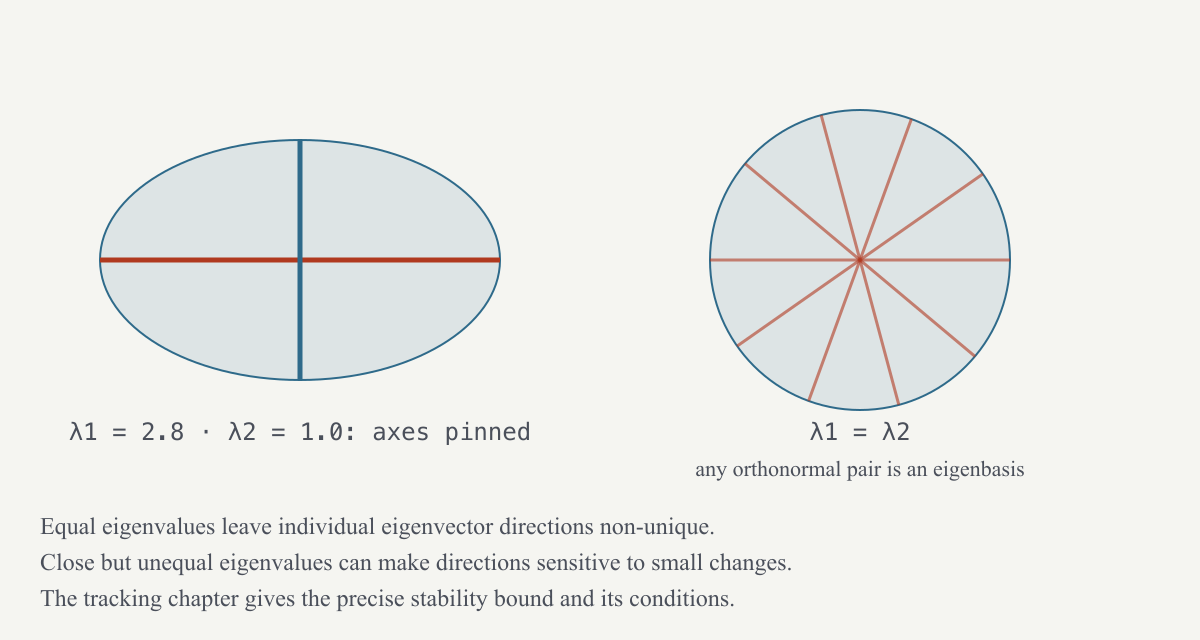

*Well‑separated eigenvalues pin the axes; exactly equal ones admit many eigenbases, while nearly equal ones are sensitive to perturbations. The tracking chapter gives the precise stability bound.*

### Laboratory: Skewness orientation and degeneracy

`signed_scores` are an editable one-axis fixture with a long negative tail.
`m2` and `m3` are its second and third central moments. Reversing the sign
reverses `m3`. A separate repeated-eigenvalue covariance remains unchanged by
rotation, demonstrating why individual eigenvectors are not identifiable inside
that plane.

In [22]:
let signed_scores=[|-5.;-1.;0.;1.;1.|];;
let score_mean=Array.fold_left (+.) 0. signed_scores/.float_of_int(Array.length signed_scores);;
let centered_scores=Array.map(fun x->x-.score_mean)signed_scores;;
let moment power a=Array.fold_left(fun s x->s+.x**power)0. a/.float_of_int(Array.length a);;
let m2=moment 2. centered_scores and m3=moment 3. centered_scores;;
let orientation=if m3<0. then -1. else 1.;;assert(moment 3.(Array.map(( *.)orientation)centered_scores)>0.);;
let rotation2=[|[|cos(Float.pi/.5.);-.sin(Float.pi/.5.)|];[|sin(Float.pi/.5.);cos(Float.pi/.5.)|]|];;
assert_matrix(matmul(matmul(transpose rotation2)(scale 2.(eye 2)))rotation2)(scale 2.(eye 2));;
record_result "orientation_third_moment" m3;;

val signed_scores : float array = [|-5.; -1.; 0.; 1.; 1.|]


val score_mean : float = -0.8


val centered_scores : float array =
  [|-4.2; -0.199999999999999956; 0.8; 1.8; 1.8|]


val moment : float -> float array -> float = <fun>


val m2 : float = 4.96000000000000085
val m3 : float = -12.3840000000000021


val orientation : float = -1.


- : unit = ()


val rotation2 : float array array =
  [|[|0.809016994374947451; -0.587785252292473137|];
    [|0.587785252292473137; 0.809016994374947451|]|]


- : unit = ()


- : string = "orientation_third_moment = -12.384"


<a id="varimax"></a>

## Varimax

<a id="varimax-basis-and-scores"></a>

### Turn the axes and counter-turn the coordinates

Recall the retained $d\times k$ orthonormal basis $V$. Let $R$ be a $k\times k$ orthogonal rotation and let $V'=VR$ be the named basis; the prime here means rotated. If $c$ is a $k\times1$ raw coordinate column, its named column is $y=R^{\top}c$ (also sometimes written $c'$). Why does the coordinate transformation use the transpose? The coordinates must change oppositely to the basis so that the represented point stays fixed. Substituting $y$ and using $RR^{\top}=I$ gives

$$V'y=VR(R^{\top}c)=Vc.$$

Both bases therefore reconstruct the same projection. Subtracting that same projection from an observation leaves the same residual, so its length is unchanged. The covariance-adjusted distance called $T^2$ in §7 is also unchanged *when its covariance is transformed consistently*; it is not determined by the subspace alone.

<a id="varimax-objective"></a>

### Read the criterion as a variance calculation

Kaiser's *varimax* criterion selects a rotation making each direction load strongly on some features and weakly on others. A *criterion*, or objective, is a numerical rule for comparing candidate choices. A larger value of this criterion indicates greater contrast in the sizes of loadings within the columns. It favors concentration but does not force entries to become exactly zero.

Let $p$ count the features, let $i=1,\ldots,p$ index them, and let $j=1,\ldots,k$ index axes. Write $\ell_{ij}$ for row $i$, column $j$ of the rotated loading table. Hold one column $j$ fixed. Square each loading, average those squared loadings, then measure how much the squared loadings vary around their mean. Squaring treats equally strong positive and negative loadings equally; it is concentration of magnitude that matters here.

We already derived the identity "variance equals mean square minus square of mean." Apply it to the values $\ell_{ij}^2$. Their squares are $\ell_{ij}^4$, so this column's variance is the average fourth power minus the square of the average second power. Add those variances over columns. That sequence of operations gives the criterion

$$\sum_{j=1}^{k}\left[\frac1p\sum_{i=1}^{p}\ell_{ij}^{4}-\left(\frac1p\sum_{i=1}^{p}\ell_{ij}^{2}\right)^2\right].$$

The fourth power appears because it is the square of a squared loading. It is not a new assumption that extreme feature values should be counted four times. For a two-feature column with loadings 1 and 0, squared loadings are 1 and 0, their mean is 0.5, and the variance of those squared loadings is $((1-0.5)^2+(0-0.5)^2)/2=0.25$. Spread the same total squared loading equally by using loadings $1/\sqrt2$ and $1/\sqrt2$. The squared loadings are now 0.5 and 0.5, so their variance is zero. The first column has greater concentration even though both columns have squared length one. In a rotation we cannot choose each column independently: the whole loading table must turn together. The notebooks compute the variance of squared loadings by directly subtracting each column's mean and also by the displayed formula; the two methods agree.

Figure 10 shows six variables in two groups mixed by 30°. Their small secondary loadings make the computed maximizing rotation approximately $-33.3°$, rather than an exact reversal of the mixing angle. The rotation concentrates each variable on one axis without making its other loading exactly zero.

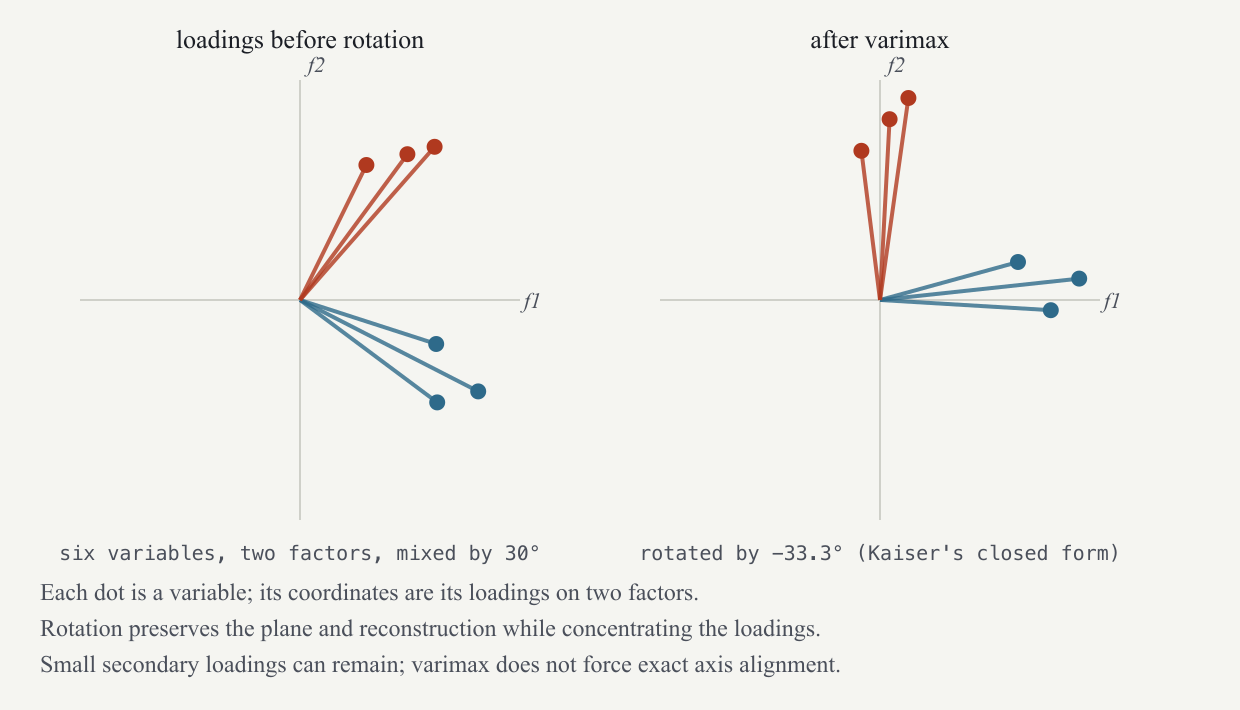

*Varimax: the same plane, different axes. Before rotation the loadings are mixed; afterwards they are more concentrated on individual factors, with small secondary loadings remaining.*

<a id="varimax-pairwise-rotation"></a>

### Rotate two columns at a time

Eigen Times sweeps over every pair of axes, rotating just that pair by its best angle. This two-coordinate operation is a *Givens rotation*. It leaves the other columns unchanged, reducing one step of a many-axis search to choosing one angle.

Let $\phi$ (Greek phi) denote that angle. Angles may be measured in degrees, with 360° in a full turn, or in *radians*, where angle is arc length divided by circle radius. One full turn is $2\pi$ radians, with $\pi$ the circle constant. On the unit circle, $\cos\phi$ is the horizontal coordinate and $\sin\phi$ the vertical coordinate after turning through $\phi$ from the positive horizontal direction. Their squared sum is 1 because the point lies on that circle. A two-dimensional rotation matrix is

$$R(\phi)=\begin{pmatrix}\cos\phi&-\sin\phi\\\sin\phi&\cos\phi\end{pmatrix}.$$

For one pair only, let $x,y$ be its $p\times1$ loading columns, distinct from article and score vectors elsewhere. Multiplying the loading table by $R(\phi)$ changes row $i$'s pair to

$$x_i\cos\phi+y_i\sin\phi,\qquad -x_i\sin\phi+y_i\cos\phi.$$

These two entries' squared sum remains $x_i^2+y_i^2$. Rotation redistributes a row's contribution between axes while preserving its total squared size.

<a id="varimax-angle-formula"></a>

### Why the best angle contains a quarter of an angle

We can evaluate the criterion for many trial angles, but the two-column case also has a direct formula. *Elementwise* arithmetic treats each row separately. Define $u_i=x_i^2-y_i^2$ as the difference of the squared loadings and $v_i=2x_iy_i$ as twice their product. Define four scalar sums

$$A=\sum_i u_i,\quad B=\sum_i v_i,\quad
C=\sum_i(u_i^2-v_i^2),\quad D=\sum_i2u_iv_i.$$

These local capital letters are scalars, not earlier matrices. The first two sums measure the column totals of the new quantities; the last two collect their squared and cross-product terms. Define centered combinations $C_*=C-(A^2-B^2)/p$ and $D_*=D-2AB/p$. The subscript star marks these adjusted scalar values.

Here is the route from the criterion to the angle. After rotation, the difference of the two squared loadings is $u_i\cos(2\phi)+v_i\sin(2\phi)$, obtained by expanding the two squared rotated entries and using the double-angle identities. In those identities, $\cos(2\phi)=\cos^2\phi-\sin^2\phi$ and $\sin(2\phi)=2\sin\phi\cos\phi$. Substituting this difference into the variance criterion and expanding once more leaves an angle-independent part plus

$$\frac{C_*\cos(4\phi)+D_*\sin(4\phi)}{4p}.$$

The appearance of $4\phi$ comes from squaring expressions that already involve $2\phi$. We can maximize the displayed part geometrically: it is a dot product between the fixed vector $(C_*,D_*)$ and the unit vector $(\cos(4\phi),\sin(4\phi))$, divided by a positive constant. The dot product is largest when the unit vector points along the fixed vector. The function $\operatorname{atan2}(a,b)$ returns the angle of the point with horizontal coordinate $b$ and vertical coordinate $a$, preserving the quadrant that a ratio alone would lose. It supplies $4\phi$; divide by four to get

$$\phi = \tfrac{1}{4}\,\operatorname{atan2}\left(D - 2AB/p,\; C - (A^2 - B^2)/p\right).$$

This is a formula for choosing a maximizing angle, not a requirement to memorize trigonometric manipulation. The notebooks check its objective against a dense grid of trial angles and verify the angle-dependent expression. If both arguments of $\operatorname{atan2}$ are zero, that expression is constant and the pair supplies no preferred rotation.

A *sweep* visits every axis pair. Sweeps stop when no pair rotates by more than $10^{-6}$ radians (one millionth of a radian), or after fifty sweeps. Exact pairwise maximization cannot decrease the criterion, so its bounded objective improves monotonically, meaning it never moves downward. This does not guarantee the global best orientation: the choices across many column pairs interact. The reported alternative, an SVD-based fixed-point iteration (repeatedly applying one update rule), oscillated between two mirror-image states on a symmetric configuration, motivating the pairwise method.

<a id="varimax-lexical-associations"></a>

### Give an embedding direction evidence from words

For the embedding basis, naming rotates associations with words rather than unexplained embedding coordinates. The articles supply the common rows connecting the two descriptions: each has term measurements and raw eigen-coordinates.

Let $T$ be the $N\times p$ article TF‑IDF matrix, $\mu_T$ its $p\times1$ article mean, and $\mathbf1$ a column of $N$ ones. Let $S$ be an $N\times k$ table of raw eigen-coordinates divided by their positive raw-axis standard deviations. Dividing a coordinate by its standard deviation makes one unit mean one reference standard deviation on every axis. Because the unrotated eigen-coordinates already have zero reference mean and zero reference cross-covariance, this scaling gives unit reference variance and zero reference cross-covariance. Together those properties are called *whitening*. Scaling arbitrary correlated coordinates to unit variance would not by itself remove their cross-covariances.

Let $\beta$ (Greek beta) be the $p\times k$ term-loading matrix. Its entry for one term and one axis sums, over articles, the centered term value multiplied by that article's standardized raw score. Positive products arise when the term and score are both above their respective references, or both below. The sum measures association between term use and the direction; it is not a probability and has not been divided by the number of articles. Matrix multiplication performs all these sums together:

$$\beta=\left(T-\mathbf1\mu_T^{\top}\right)^{\top}S.$$

Here $p=50{,}000$ and $k=60$. Lexical whitening floors its raw variance denominators at $10^{-12}$ before taking square roots: if a variance is smaller, the implementation uses that positive minimum to avoid division by zero or an excessively small scale. Exact unit-variance whitening applies to positive axes whose denominators have not been changed by this safeguard, under the same reference weights used to fit them.

The embedding naming fit rotates $\beta$; the LSA fit rotates its right singular directions, already indexed by terms. Applying the resulting $R$ to the corresponding raw coordinate map gives named directions. Because scaling and rotation need not give the same result in opposite orders, word associations fitted from whitened scores are labels for investigation, not exact term-by-term decompositions of every stored named score. The block-sum chapter expands the centered loading formula. The older shorthand $T^{\top}U$ assumes compatible centered, scaled score columns; the SVD factor $U$ must not generally be substituted for $S$. The distinction is practical: a unit left singular direction, an article coordinate, and a variance-standardized coordinate carry different scales even when they point along related patterns.

### Laboratory: Recompute the exact pairwise Givens angle and lexical loadings

`clean_loadings` is the six-variable fixture from Figure 10. `mixed_loadings`
rotates it by 30 degrees. The four scalar sums give the closed-form improving
angle `phi`. We recompute the objective before and after, obtaining approximately
−33.28 degrees. `whitened_scores` are raw principal coordinates divided by their
positive standard deviations; `beta` is their centered association with terms.
The final equality checks the expanded cross-product formula.

In [23]:
let clean_loadings=[|[|1.;0.05|];[|0.85;-.0.1|];[|0.7;0.15|];[|0.1;0.9|];[|-.0.05;0.75|];[|0.2;1.|]|];;
let rotation_matrix angle=[|[|cos angle;-.sin angle|];[|sin angle;cos angle|]|];;
let mixed_loadings=matmul clean_loadings(rotation_matrix(Float.pi/.6.));;
let pair_angle matrix j l=
 let x=col matrix j and y=col matrix l in
 let u=Array.mapi(fun i a->a*.a-.y.(i)*.y.(i))x in
 let v=Array.mapi(fun i a->2.*.a*.y.(i))x in
 let aa=Array.fold_left (+.) 0. u and bb=Array.fold_left (+.) 0. v in
 let cc=dot u u-.dot v v and dd=2.*.dot u v and p=float_of_int(rows matrix) in
 atan2(dd-.2.*.aa*.bb/.p)(cc-.(aa*.aa-.bb*.bb)/.p)/.4.;;
let objective a=Array.fold_left(fun sum column->sum+.moment 4. column-.(moment 2. column)**2.)0.(transpose a);;
let phi=pair_angle mixed_loadings 0 1;;let named_loadings=matmul mixed_loadings(rotation_matrix phi);;
assert(objective named_loadings>=objective mixed_loadings-.1e-12);;
assert_close(frob named_loadings)(frob mixed_loadings);;
let raw_values,raw_directions=eig_sym(scale(1./.float_of_int(rows tfidf))(matmul(transpose centered_t)centered_t));;
let raw_variances=Array.sub raw_values 0 2 and raw_scores=matmul centered_t(take_cols raw_directions 2);;
let whitened_scores=Array.map(fun row->Array.mapi(fun j x->x/.sqrt(max 1e-12 raw_variances.(j)))row)raw_scores;;
assert_matrix(scale(1./.float_of_int(rows tfidf))(matmul(transpose whitened_scores)whitened_scores))(eye 2);;
let beta=matmul(transpose centered_t)whitened_scores;;
assert_matrix beta(sub(matmul(transpose tfidf)whitened_scores)(outer term_mean(Array.map(Array.fold_left (+.) 0.)(transpose whitened_scores))));;
record_result "varimax_angle_degrees" (phi*.180./.Float.pi);;
record_result "varimax_objective_gain" (objective named_loadings-.objective mixed_loadings);;
print_matrix "named loadings" named_loadings;;

val clean_loadings : float array array =
  [|[|1.; 0.05|]; [|0.85; -0.1|]; [|0.7; 0.15|]; [|0.1; 0.9|];
    [|-0.05; 0.75|]; [|0.2; 1.|]|]


val rotation_matrix : float -> float array array = <fun>


val mixed_loadings : float array array =
  [|[|0.89102540378443873; -0.456698729810778|];
    [|0.686121593216772796; -0.511602540378443771|];
    [|0.681217782649107; -0.220096189432334111|];
    [|0.536602540378443793; 0.729422863405994826|];
    [|0.331698729810778; 0.674519052838329|];
    [|0.673205080756887675; 0.76602540378443873|]|]


val pair_angle : float array array -> int -> int -> float = <fun>


val objective : float array array -> float = <fun>


...

val beta : float array array =
  [|[|1.77401274622029526; -0.0698741810041304673|];
    [|1.77401274622029526; -0.0698741810041304673|];
    [|1.32617549407376556; -0.0629830223408626433|];
    [|-1.2545826631082575; 1.31449589654870969|];
    [|-1.56634118240856091; 0.33561396406309435|];
    [|-1.1823772075856287; -1.05984436946112126|];
    [|-1.1823772075856287; -1.05984436946112126|]|]


- : unit = ()


- : string = "varimax_angle_degrees = -33.278610189"


- : string = "varimax_objective_gain = 0.243533078283"


- : string =
"named loadings (6 x 2)\n : [0.995504; 0.107109]\n : [0.854328; -0.0512237]\n : [0.690276; 0.189788]\n : [0.0483641; 0.904246]\n : [-0.0928117; 0.745913]\n : [0.142481; 1.0098]"


### Laboratory: Check squared-loading variance and derive the four-angle objective

The first two columns have equal squared length but different concentration:
the variance of their squared loadings is one quarter and zero. For the exact
six-variable figure fixture, we then evaluate the criterion directly, verify
the adjusted C and D four-angle expression, and check that the prescribed angle
beats every point on a dense trial grid. The grid is a numerical check;
the dot-product argument in the manuscript explains the maximizing angle.

In [24]:
let early_concentrated=[|1.;0.|] and early_balanced=normalize[|1.;1.|];;
let early_column_variance column=
 let squared=Array.map(fun x->x*.x)column in
 let mean=Array.fold_left (+.)0. squared/.float_of_int(Array.length squared)in
 Array.fold_left(fun total x->total+.(x-.mean)**2.)0. squared/.float_of_int(Array.length squared);;
assert_close(dot early_concentrated early_concentrated)(dot early_balanced early_balanced);;
assert_close(early_column_variance early_concentrated)0.25;;
assert_close(early_column_variance early_balanced)0.;;
let early_direct_objective=Array.fold_left(fun total column->total+.early_column_variance column)0.(transpose mixed_loadings);;
assert_close early_direct_objective(objective mixed_loadings);;
let early_x=col mixed_loadings 0 and early_y=col mixed_loadings 1;;
let early_p=float_of_int(rows mixed_loadings);;
let early_u=Array.mapi(fun i x->x*.x-.early_y.(i)*.early_y.(i))early_x;;
let early_vv=Array.mapi(fun i x->2.*.x*.early_y.(i))early_x;;
let early_aa=Array.fold_left (+.)0. early_u and early_bb=Array.fold_left (+.)0. early_vv;;
let early_cc=dot early_u early_u-.dot early_vv early_vv-.(early_aa*.early_aa-.early_bb*.early_bb)/.early_p;;
let early_dd=2.*.dot early_u early_vv-.2.*.early_aa*.early_bb/.early_p;;
let early_constant=objective mixed_loadings-.early_cc/.(4.*.early_p);;
let early_grid_max=ref neg_infinity;;
for i=0 to 1000 do
 let angle= -.Float.pi/.4.+.float_of_int i*.Float.pi/.2000. in
 let actual=objective(matmul mixed_loadings(rotation_matrix angle))in
 let predicted=early_constant+.(early_cc*.cos(4.*.angle)+.early_dd*.sin(4.*.angle))/.(4.*.early_p)in
 assert_close actual predicted;early_grid_max:=max !early_grid_max actual
done;;
let early_optimum=atan2 early_dd early_cc/.4.;;
assert_close early_optimum phi;;
assert(objective(matmul mixed_loadings(rotation_matrix early_optimum))>= !early_grid_max-.1e-12);;
print_vector "adjusted C,D and angle" [|early_cc;early_dd;early_optimum|];;
record_result "primer_varimax_concentrated_variance" (early_column_variance early_concentrated);;
record_result "primer_varimax_direct_objective" early_direct_objective;;
record_result "primer_varimax_four_angle_optimum" early_optimum;;

val early_concentrated : float array = [|1.; 0.|]
val early_balanced : float array =
  [|0.707106781186547462; 0.707106781186547462|]


val early_column_variance : float array -> float = <fun>


- : unit = ()


- : unit = ()


- : unit = ()


...

- : unit = ()


- : string = "adjusted C,D and angle: [-2.3729; -2.53445; -0.580821]"


- : string = "primer_varimax_concentrated_variance = 0.25"


- : string = "primer_varimax_direct_objective = 0.079553952098"


- : string = "primer_varimax_four_angle_optimum = -0.580821318286"


<a id="measuring-a-story"></a>

# Measuring a story

<a id="projection-reconstruction-residual"></a>

## Projection, reconstruction, residual

The question is now about one observation: how much of it can the retained directions reconstruct, and what do they leave out? Here an observation is an article, or a representative vector chosen for a story. It is already a numerical vector; we are not yet assigning it a claim about historical novelty.

Let $d$ count its original coordinates and $k$ count retained directions. Write $x$ for the $d\times1$ observation column and $\mu$ for the $d\times1$ fitted article mean. The $d\times k$ matrix $V$ contains the retained raw directions as columns. They are *orthonormal*: each has length one and different columns have dot product zero. The following steps have different jobs.

<a id="first-find-coordinates-then-reconstruct"></a>

### First find coordinates, then reconstruct

**Subtract the reference point.** The centred column $x-\mu$ is the displacement from the fitted mean. Projection concerns this displacement, so the mean must be removed before measuring coordinates.

**Measure along each retained direction.** Define the $k\times1$ coordinate column $c$. Entry $c_j$, with $j=1,\ldots,k$, is the dot product with retained direction $j$. Stacking those dot products is matrix multiplication:

$$c=V^{\top}(x-\mu).$$

**Rebuild what those coordinates describe.** Multiplying by $V$ takes the weighted sum of the retained directions. Adding the mean puts the result back in the original coordinate system. Call this $d\times1$ reconstruction $\hat x$; the hat marks an approximation:

$$\hat x=\mu+Vc.$$

**Subtract the reconstruction from the observation.** The $d\times1$ difference $r$ is the *residual*: what remains after the attempted reconstruction. The word names a difference vector, not its length and not its probability:

$$r=x-\hat x.$$

For a complete synthetic example, retain the first two coordinate directions in three dimensions. Take $x=(2,1,3)^{\top}$ and $\mu=(0,0,0)^{\top}$. Then

$$V=\begin{pmatrix}1&0\\0&1\\0&0\end{pmatrix},\qquad
c=\begin{pmatrix}2\\1\end{pmatrix},\qquad
\hat x=\begin{pmatrix}2\\1\\0\end{pmatrix},\qquad
r=\begin{pmatrix}0\\0\\3\end{pmatrix}.$$

The first coordinate survives unchanged, the second survives unchanged, and the third is absent from the retained plane. Subtraction reveals that absence explicitly: $3-0=3$ in the last residual entry.

<a id="why-this-is-the-nearest-reconstruction"></a>

### Why this is the nearest reconstruction

An *orthogonal projection* keeps the component in the chosen subspace and leaves a residual perpendicular to it. Here this can be checked by taking its coordinates again. Since $V^{\top}V=I$, where $I$ is the $k\times k$ identity,

$$V^{\top}r=V^{\top}(x-\mu)-V^{\top}Vc=c-c=0.$$

Thus every retained direction has zero dot product with the residual. This is also why the reconstruction is a least-squares one. Any change to the reconstructed point within the retained subspace adds another perpendicular component to the error. Its squared length adds to the existing residual squared length, so it cannot improve the fit. No differentiation is needed for this geometric argument.

Recall the two distinct operations in a length calculation. Squaring entries and adding them gives *squared length*; taking its square root gives *length*. For our residual,

$$\lVert r\rVert^2=0^2+0^2+3^2=9,\qquad \lVert r\rVert=\sqrt9=3.$$

The centred observation has squared length $2^2+1^2+3^2=14$. The retained part has squared length $2^2+1^2=5$. The Pythagorean identity reads $14=5+9$: retained variation and residual variation account for the whole squared length. We use squared lengths below because perpendicular contributions add in this way. The ordinary lengths do not add: $\sqrt{14}$ is not $\sqrt5+3$.

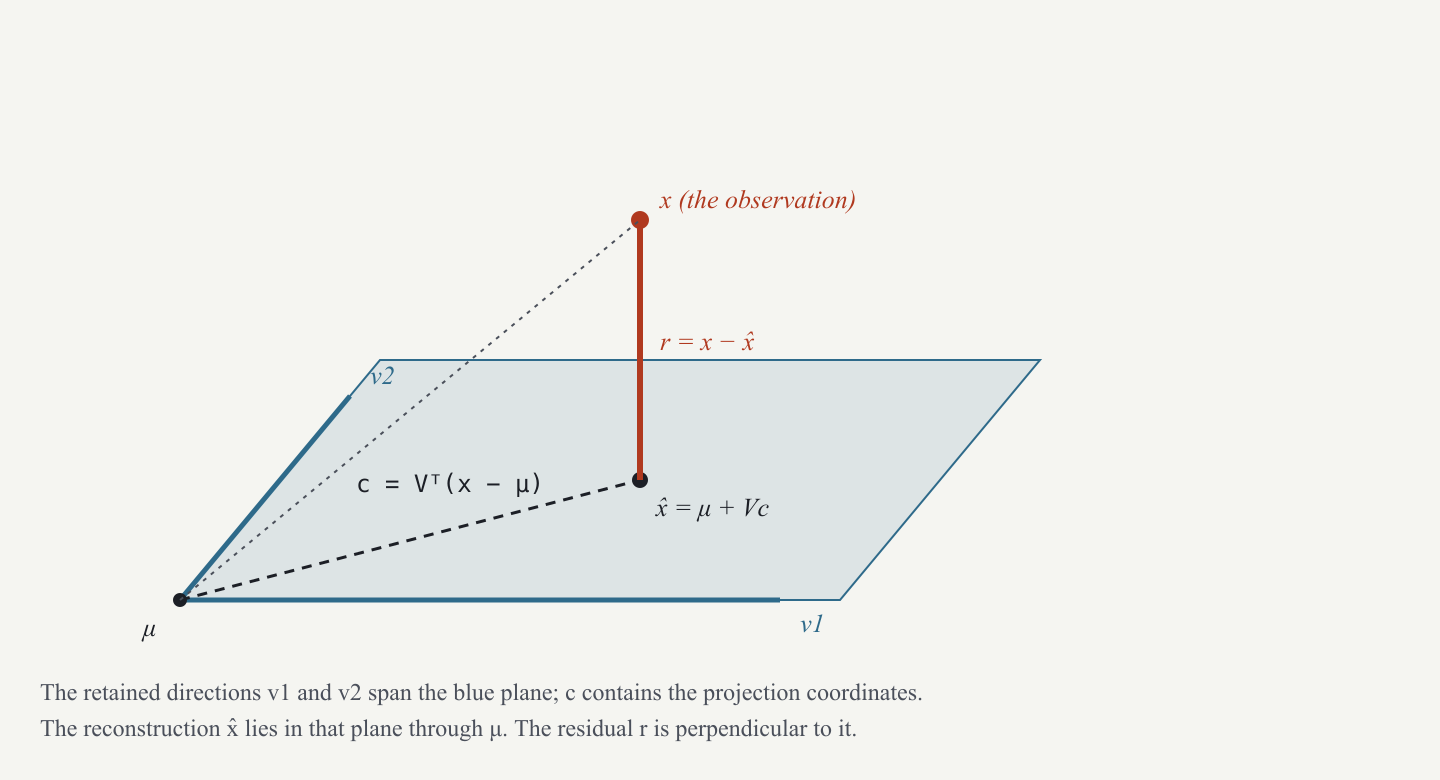

*A story against the basis: its projection onto the news subspace, and the residual perpendicular to it.*

### Laboratory: A fully computed story measurement

For this **synthetic observation**, `story=[2,1,3]`, the mean is zero and the
retained basis consists of the first two coordinate directions. `coords`,
`reconstructed`, and `residual` implement the three displayed equations. The
Pythagorean check verifies that retained and residual squared lengths add to the
total centered squared length.

In [25]:
let story=[|2.;1.;3.|] and reference_mean=[|0.;0.;0.|] and measurement_basis=take_cols(eye 3)2;;
let centered_story=Array.mapi(fun i x->x-.reference_mean.(i))story;;
let coords=matvec(transpose measurement_basis)centered_story;;
let reconstructed=Array.mapi(fun i x->x+.reference_mean.(i))(matvec measurement_basis coords);;
let residual=Array.mapi(fun i x->x-.reconstructed.(i))story;;
Array.iter(fun x->assert_close x 0.)(matvec(transpose measurement_basis)residual);;
assert_close(dot coords coords+.dot residual residual)(dot centered_story centered_story);;
print_vector "coordinates" coords;;print_vector "residual" residual;;record_result "projection_q" (dot residual residual);;

val story : float array = [|2.; 1.; 3.|]
val reference_mean : float array = [|0.; 0.; 0.|]
val measurement_basis : float array array =
  [|[|1.; 0.|]; [|0.; 1.|]; [|0.; 0.|]|]


val centered_story : float array = [|2.; 1.; 3.|]


val coords : float array = [|2.; 1.|]


val reconstructed : float array = [|2.; 1.; 0.|]


val residual : float array = [|0.; 0.; 3.|]


- : unit = ()


- : unit = ()


- : string = "coordinates: [2; 1]"


- : string = "residual: [0; 0; 3]"


- : string = "projection_q = 9"


### Laboratory: Read every projection step and its units

The retained part and the residual from the preceding cell are perpendicular.
We now compute their squared lengths separately, and take a square root only
when an ordinary length is requested. These are the manuscript's synthetic
values 5, 9 and 14; adding the ordinary lengths would give a different result.

In [26]:
let retained_squared=dot coords coords and residual_squared=dot residual residual and total_squared=dot centered_story centered_story;;
assert_close retained_squared 5.;;assert_close residual_squared 9.;;assert_close total_squared 14.;;
assert_close(retained_squared+.residual_squared)total_squared;;
assert_close(sqrt residual_squared)3.;;
assert(not(close(sqrt total_squared)(sqrt retained_squared+.sqrt residual_squared)));;
record_result "projection_retained_squared" retained_squared;;
record_result "projection_total_squared" total_squared;;
record_result "projection_residual_length" (sqrt residual_squared);;
print_vector "retained, residual, total squared lengths" [|retained_squared;residual_squared;total_squared|];;

val retained_squared : float = 5.
val residual_squared : float = 9.
val total_squared : float = 14.


- : unit = ()


- : unit = ()


- : unit = ()


- : unit = ()


...

- : unit = ()


- : string = "projection_retained_squared = 5"


- : string = "projection_total_squared = 14"


- : string = "projection_residual_length = 3"


- : string = "retained, residual, total squared lengths: [5; 9; 14]"


<a id="t2-and-q"></a>

## T² and Q

We need two different comparisons. One asks how far the story lies *along* the retained directions, taking each direction's usual spread into account. The other asks how much of the story lies *outside* those directions. A *statistic* is a numerical summary calculated from data; calling something a statistic does not by itself assign a probability to it.

<a id="compare-a-coordinate-with-its-usual-spread"></a>

### Compare a coordinate with its usual spread

Recall that variance is an average squared deviation from a mean, and standard deviation is its nonnegative square root. Raw coordinate $j$ has fitted mean zero and variance $\lambda_j$. For this calculation retain only positive eigenvalues, so dividing by $\sqrt{\lambda_j}$ is possible. The quotient $c_j/\sqrt{\lambda_j}$ expresses the coordinate in units of its own standard deviation. A displacement of two units is ordinary on an axis whose usual spread is two, but larger relative to an axis whose usual spread is one.

A *z-score* subtracts a reference mean and divides by a positive reference standard deviation. The mean subtraction has already happened for the raw coordinates. Their variances can differ, but their fitted cross-covariances are zero. Dividing each by its own standard deviation therefore gives *whitened coordinates*: unit variance in every direction and zero cross-covariances under that same fitted reference.

Define $T^2$, Hotelling's squared covariance-adjusted distance, by squaring these standardized coordinates and adding. Here $T^2$ is the statistic's name, not the square of the TF‑IDF matrix $T$. With $j=1,\ldots,k$,

$$T^2=\sum_j\left(\frac{c_j}{\sqrt{\lambda_j}}\right)^2
     =\sum_j\frac{c_j^2}{\lambda_j}.$$

Our synthetic story has $c=(2,1)^{\top}$. Suppose the fitted raw variances are $4$ and $1$, hence standard deviations $2$ and $1$. Its standardized coordinates are $(2/2,1/1)^{\top}=(1,1)^{\top}$. Squaring and adding gives

$$T^2=1^2+1^2=2.$$

Both retained coordinates are one reference standard deviation from their means, although their original sizes differ.

For compact matrix notation let $\Lambda$ be the $k\times k$ diagonal matrix of those positive raw eigenvalues. A superscript $-1$ denotes an inverse, the operation undoing multiplication by an invertible matrix. For a diagonal matrix, inversion replaces each nonzero diagonal entry by its reciprocal. Consequently $\Lambda^{-1}$ first divides coordinate $j$ by $\lambda_j$; the dot product with $c$ then multiplies by $c_j$ again and adds:

$$T^2=c^{\top}\Lambda^{-1}c.$$

<a id="measure-the-part-outside-the-retained-space"></a>

### Measure the part outside the retained space

Define $Q$ to be residual squared length:

$$Q=\lVert r\rVert^2.$$

For the same story, $Q=9$. This is a different measurement from $T^2=2$. A point can be far along a retained direction and have no residual at all; another can lie close to the mean within the retained directions but have a substantial perpendicular residual. A residual can contain discarded familiar variation as well as genuinely new material. Neither statistic alone proves that an event is unprecedented.

Figure 12 shows why reference spreads matter: equal Euclidean distances can have different covariance-adjusted distances. With 60 fitted positive directions, the fitted average of $T^2$ under the matching covariance weights is 60. To see why, average each term $c_j^2/\lambda_j$: the numerator's fitted average is precisely $\lambda_j$, so every term contributes one. A value of 400 is much larger than that fitted average. This arithmetic does not yet provide the probability of reaching 400; that would require a justified probability model or a separately assessed reference distribution.

<a id="keep-the-covariance-when-changing-coordinates"></a>

### Keep the covariance when changing coordinates

The calculation uses raw eigen-coordinates before the naming rotation. The rotation changes the coordinate descriptions without changing the retained point. Recall the $k\times k$ orthogonal naming rotation $R$. In the named coordinate column $y=R^{\top}c$, define the covariance $\Gamma=R^{\top}\Lambda R$. Its off-diagonal entries need not be zero: named coordinates can vary together even though the raw eigen-coordinates did not.

To measure the same distance in this new coordinate system, use its full covariance:

$$T^2=y^{\top}\Gamma^{-1}y.$$

The inverse now adjusts for both different spreads and shared movement between coordinates. Reusing the old diagonal eigenvalues would attach old scales to new directions. Dividing by the named coordinates' own variances is also insufficient when their covariances are nonzero. That operation is *marginal standardization*: it gives each coordinate unit variance separately but leaves correlations. Full whitening removes cross-covariances as well. The notebooks rotate the synthetic story and verify that the full calculation stays unchanged while the diagonal shortcut generally changes it.

The implementation sums $c_j^2/\lambda_j$ only for positive raw eigenvalues and contributes zero otherwise. This is an explicit handling rule for zero-variance directions, not permission to divide by zero. The inverse formulas above assume positive retained eigenvalues.

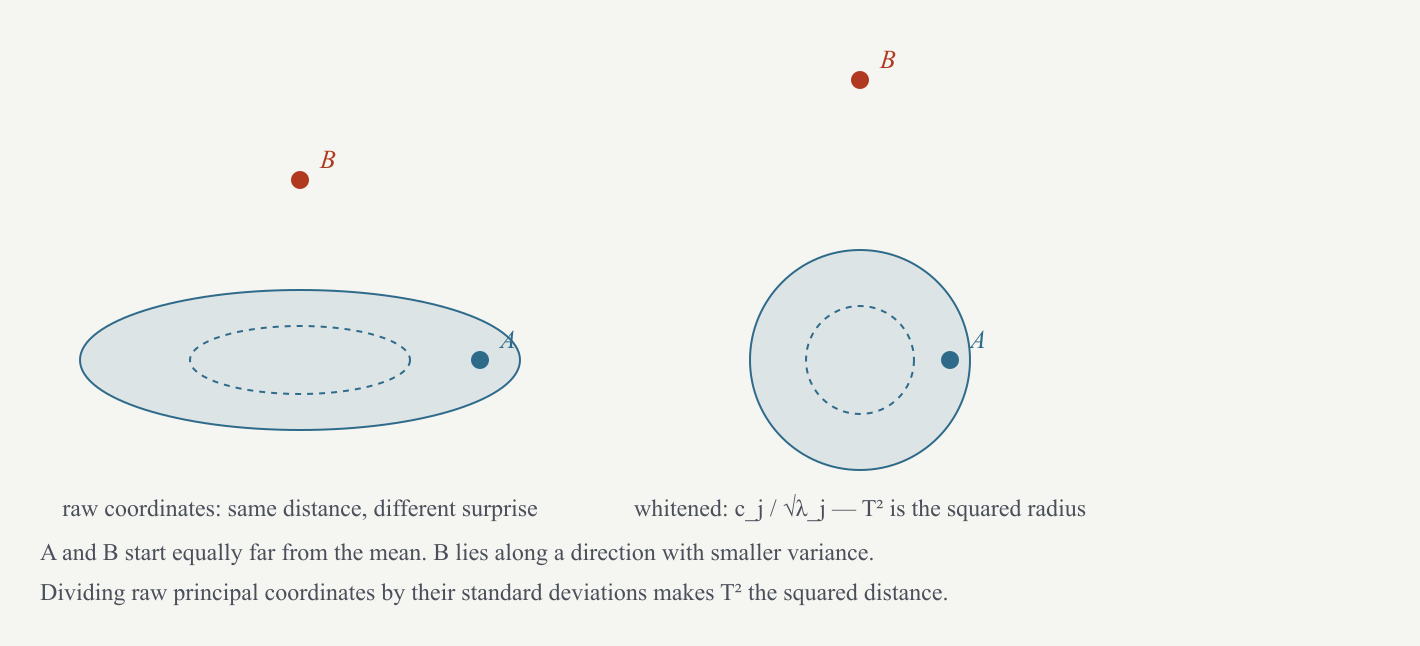

*Whitening: after dividing each raw eigen-coordinate by its axis's standard deviation, squared distance from the centre is T squared.*

<a id="turn-residual-size-into-a-share"></a>

### Turn residual size into a share

The two statistics originated in monitoring variation against a principal-component reference model. For browsing, it is also useful to ask what share of a centred observation remains outside the retained subspace. Let $\nu$ (Greek nu) denote this *novelty ratio*. When $x\ne\mu$, meaning the observation differs from the fitted mean, define

$$\nu=\frac{Q}{\lVert x-\mu\rVert^2}.$$

The denominator counts all centred squared length; the numerator counts only the residual part. In our example, $\nu=9/14\approx0.643$. About 64.3% of this observation's squared length lies outside the retained plane. That is a statement about this representation, not a 64.3% probability of a historically new event.

Orthogonality makes the denominator the sum of retained and residual squared lengths, both nonnegative. The ratio therefore lies between zero and one. Zero means the centred vector is fully represented; one means it lies perpendicular to the retained subspace. At $x=\mu$, both numerator and denominator are zero, so the ratio is undefined. The implementation returns zero in that case as a software convention. This geometric use of "energy" means squared length; the attention score below uses the same ordinary word for a different quantity.

<a id="average-measurements-in-the-order-intended"></a>

### Average measurements in the order intended

These equations describe one vector. The site's stored story statistics are means of the member articles' $T^2$, $Q$, and $\nu$ values. The order matters: measure every member, then average the measurements. Measuring the mean embedding answers a different question.

For example, two member coordinate columns $(2,0)^{\top}$ and $(-2,0)^{\top}$ under variances $(4,1)$ each have $T^2=4/4=1$, so their mean statistic is one. Their mean coordinate column is zero, whose $T^2$ is zero. Averaging first cancels their opposite departures. Squared distances and ratios generally do not commute with averaging; that is why an article statistic, an average article statistic, and a centroid statistic must be kept distinct.

### Laboratory: Whitening, rotation invariance and means that do not commute

`reference_variances=[4,1]` are stipulated positive variances of the two raw
axes. `t2` is the squared covariance-adjusted distance, `q` is residual energy,
and `novelty` is its share of total energy. `gamma` is the covariance after a
30-degree rotation. The full inverse reproduces `t2`; dividing by rotated
marginal variances generally does not. Finally two opposite member vectors have
a nonzero mean individual distance, despite their centroid being zero.

In [27]:
let reference_variances=[|4.;1.|];;
let t2=Array.fold_left (+.)0.(Array.mapi(fun j x->x*.x/.reference_variances.(j))coords);;
let q=dot residual residual;;let novelty=q/.dot centered_story centered_story;;
let rotation_measure=rotation_matrix(Float.pi/.6.);;
let named_coords=matvec(transpose rotation_measure)coords;;
let gamma=matmul(matmul(transpose rotation_measure)(diag reference_variances))rotation_measure;;
let rotated_t2=dot named_coords(solve gamma named_coords);;
let naive_t2=Array.fold_left (+.)0.(Array.mapi(fun j x->x*.x/.gamma.(j).(j))named_coords);;
assert_close t2 rotated_t2;;assert(abs_float(naive_t2-.t2)>0.01);;
let members=[|[|2.;0.|];[|-2.;0.|]|];;
let member_stat row=Array.fold_left (+.) 0. (Array.mapi(fun j value->value*.value/.reference_variances.(j))row);;
let mean_stat=Array.fold_left(fun total row->total+.member_stat row)0. members/.float_of_int(rows members);;
let centroid_stat=Array.fold_left (+.)0.(Array.mapi(fun j x->x*.x/.reference_variances.(j))(mean_rows members));;assert(mean_stat>centroid_stat);;
let novelty_with_zero_convention residual_energy total_energy=if total_energy>0. then residual_energy/.total_energy else 0.;;
assert_close(novelty_with_zero_convention 0. 0.)0.;;
record_result "hotelling_t2" t2;;record_result "novelty_ratio" novelty;;record_result "mean_member_t2" mean_stat;;
print_vector "full rotation, marginal shortcut, centroid" [|rotated_t2;naive_t2;centroid_stat|];;

val reference_variances : float array = [|4.; 1.|]


val t2 : float = 2.


val q : float = 9.


val novelty : float = 0.642857142857142905


val rotation_measure : float array array =
  [|[|0.866025403784438708; -0.499999999999999944|];
    [|0.499999999999999944; 0.866025403784438708|]|]


...

- : unit = ()


- : string = "hotelling_t2 = 2"


- : string = "novelty_ratio = 0.642857142857"


- : string = "mean_member_t2 = 1"


- : string = "full rotation, marginal shortcut, centroid: [2; 1.5432; 0]"


<a id="dominant-axis-spectrum-profile"></a>

## Dominant axis, spectrum, profile

These three objects answer questions at three different levels. The dominant axis selects a story's label. The spectrum combines the day's stories. A profile describes the stories usually carrying one label.

<a id="select-a-label-using-comparable-signed-scores"></a>

### Select a label using comparable signed scores

For story $s$, let $y_s$ be its $k\times1$ named-coordinate column, with entry $y_{sj}$ on axis $j$. Here $s$ identifies a story. The separate notation $s_j>0$ denotes the empirical standard deviation of named coordinate $j$ across stories in the profile window: the latest ten years of loaded data. This is a reference *scale*, estimated separately from the raw eigenvalue $\lambda_j$. The implementation replaces scales smaller than $10^{-6}$ by that positive floor to avoid division by zero or an extremely small denominator.

Divide each named coordinate by its reference scale. The *dominant* archetype is the axis with the largest signed result. The notation $\arg\max_j$ means "return the index attaining the largest value", whereas $\max_j$ would return the value itself. Thus the rule is $\arg\max_j y_{sj}/s_j$.

Take the notebook's synthetic story $(2,1)^{\top}$ and scales $(2,0.5)$. The scores are $2/2=1$ and $1/0.5=2$, so the second axis wins despite its smaller raw coordinate. For a second story $(-1,-0.1)^{\top}$, the scores are $-0.5$ and $-0.2$. The second wins again because $-0.2$ is larger. Taking absolute values would change that decision. This particular rule does not subtract an empirical axis mean, so it is scale division rather than a general mean-subtracted z-score.

One possible "mixed" heuristic compares the positive top score $a_1$ with the runner-up $a_2$. Their relative gap is $(a_1-a_2)/a_1$; the denominator is the top score. A rule declaring a mixture when that gap is at most $0.20$ would accept scores $1$ and $0.85$, whose gap is $0.15$. This is an illustrative rule retained from the original explanation, not a rule implemented by the current site.

<a id="combine-stories-into-a-daily-spectrum"></a>

### Combine stories into a daily spectrum

A simple average gives every story equal influence. A *weighted mean* first multiplies each value by its nonnegative weight, adds those products, and divides by the positive total weight. Division by the total makes the result an average rather than a total that grows automatically when more stories are present.

Let $\varepsilon_s$ denote story $s$'s attention weight, called *story energy* in the site:

$$\varepsilon_s=\text{distinct sources}\times\ln(1+\text{article count}).$$

The natural logarithm grows slowly; adding one makes the argument positive even for a zero count. This weight uses source and article counts. It is distinct from article fit weights, eigenvalues, and vector squared length.

For one chosen day, let $\bar y_{\mathrm{day}}$ be its $k\times1$ spectrum column. The bar indicates averaging, and the sum includes that day's stories only:

$$\bar y_{\mathrm{day}}=\frac{\sum_s\varepsilon_s y_s}{\sum_s\varepsilon_s}.$$

The notebooks use three synthetic story rows $(2,1)$, $(-1,-0.1)$, and $(0.5,3)$, with source counts $2,1,3$ and article counts $3,1,5$. Their attention weights are $2\ln4\approx2.773$, $\ln2\approx0.693$, and $3\ln6\approx5.375$. For the first spectrum coordinate, multiply $2,-1,0.5$ by those weights, add, and divide by their sum. Repeating for the second coordinate gives approximately $(0.853,2.130)$. The more heavily weighted third story pulls the mixture towards its second coordinate; no new direction has been fitted in this averaging step.

<a id="compare-a-day-or-compare-a-story"></a>

### Compare a day, or compare a story

The *era statistics* are each spectrum coordinate's mean and standard deviation over all loaded day spectra. The algorithm named after Welford updates three running summaries: how many values have arrived, their current mean, and the sum of squared deviations from that current mean. It adjusts the deviation sum when the mean changes; simply squaring deviations from an outdated mean would give the wrong answer. The statistical-threshold chapter walks through its calculation.

Each spectrum z-score subtracts the coordinate's era mean and divides by its positive era standard deviation. The front page highlights values beyond $\pm2$ (plus or minus two) and lists values below $-2$ under *Silence*. These are comparisons with all loaded data, including dates later than some selected historical dates. They are not historical forecasts computed using only the past available at the time.

An archetype's *profile* uses a different reference set: the stories it dominates in the profile window. For each named coordinate, it records a mean and standard deviation among those stories. *Same as always* combines strong positive profile and story signals with agreement within one profile standard deviation; agreement alone is insufficient. *Different this time* lists departures exceeding 1.5 profile standard deviations. The symbol $\sigma$ in these descriptions is shorthand for the relevant reference standard deviation, not an SVD singular value. A zero reference deviation needs an explicit fallback before any z-score can be computed. Always identify the reference population before interpreting a standardized score.

### Laboratory: Signed dominance, attention and the daily mixture

All numbers below are **editable teaching fixtures**. `named_rows` contains three
stories; `axis_sd` gives their reference named-axis standard deviations. The
winning index maximizes a signed standardized value, even if all are negative.
`attention` multiplies distinct sources by log(1+article count). `spectrum` is its
weighted average. The 20% mixed example is illustrative only, as the manuscript
explicitly states; it is not a deployed rule.

In [28]:
let named_rows=[|[|2.;1.|];[|-1.;-.0.1|];[|0.5;3.|]|] and axis_sd=[|2.;0.5|];;
let standardized=Array.map(fun row->Array.mapi(fun j x->x/.max 1e-6 axis_sd.(j))row)named_rows;;
let argmax a=let best=ref 0 in Array.iteri(fun i x->if x>a.(!best)then best:=i)a;!best;;
let winners=Array.map argmax standardized;;assert(winners.(1)=1);;
let source_counts=[|2.;1.;3.|] and article_counts=[|3.;1.;5.|];;
let attention=Array.mapi(fun i x->x*.log(1.+.article_counts.(i)))source_counts;;
let spectrum=Array.map(fun column->dot column attention/.Array.fold_left (+.)0. attention)(transpose named_rows);;
assert((1.-.0.85)/.1.<=0.2);;
record_result "spectrum_first" spectrum.(0);;record_result "spectrum_second" spectrum.(1);;
print_vector "story attention" attention;;

val named_rows : float array array =
  [|[|2.; 1.|]; [|-1.; -0.1|]; [|0.5; 3.|]|]
val axis_sd : float array = [|2.; 0.5|]


val standardized : float array array =
  [|[|1.; 2.|]; [|-0.5; -0.2|]; [|0.25; 6.|]|]


val argmax : 'a array -> int = <fun>


val winners : int array = [|1; 1; 1|]


- : unit = ()


...

val spectrum : float array = [|0.852805934135970611; 2.12974536246460566|]


- : unit = ()


- : string = "spectrum_first = 0.852805934136"


- : string = "spectrum_second = 2.12974536246"


- : string = "story attention: [2.77259; 0.693147; 5.37528]"


### Laboratory: Multiply, add, then divide for the daily mixture

This exposes every operation in the manuscript's three-story spectrum example.
The attention weights are 2 log 4, log 2 and 3 log 6. The numerator is a weighted
sum; dividing by total attention turns it into an average. Dominant-axis labels
below use one-based human numbering, while the code arrays are zero-based.

In [29]:
let attention_total=Array.fold_left (+.)0. attention;;
let weighted_numerator=matvec(transpose named_rows)attention;;
Array.iteri(fun j value->assert_close(value/.attention_total)spectrum.(j))weighted_numerator;;
Array.iteri(fun j value->assert_close value [|1.;2.|].(j))standardized.(0);;
Array.iteri(fun j value->assert_close value [|-0.5;-0.2|].(j))standardized.(1);;
assert(winners.(0)+1=2 && winners.(1)+1=2);;
Array.iteri(fun i value->ignore(record_result(Printf.sprintf "spectrum_attention_story_%d" (i+1))value))attention;;
record_result "spectrum_attention_total" attention_total;;
record_result "illustrative_relative_gap" ((1.-.0.85)/.1.);;
print_vector "weighted numerator" weighted_numerator;;

val attention_total : float = 8.8410143104838923


val weighted_numerator : float array =
  [|7.53966946776169955; 18.8291092272362839|]


- : unit = ()


- : unit = ()


- : unit = ()


- : unit = ()


- : unit = ()


- : string = "spectrum_attention_total = 8.84101431048"


- : string = "illustrative_relative_gap = 0.15"


- : string = "weighted numerator: [7.53967; 18.8291]"


<a id="the-clustering-thresholds"></a>

# The clustering thresholds

A *threshold* turns a numerical measurement into a decision: link two articles if their similarity reaches a chosen value; highlight an axis if its standardized departure exceeds a chosen size. The measurement and the decision are separate. Cosine supplies a similarity, but mathematics alone does not say which cosine deserves a link.

The thresholds described here use cosines, z-scores, and counts. This chapter shows the empirical distributions used to choose them for the dated Eigen Times corpus. The methods also apply to Eigen Hacks, but these recorded newspaper measurements are not measurements of its technology-community corpus. A changed embedding model, input length, language, or corpus can change the distribution enough to require a fresh assessment.

<a id="stories-single-linkage-on-a-days-articles"></a>

## Stories: single linkage on a day's articles

Start with a *graph*: a collection of nodes and connections called edges. Here each article is a node. Compare each pair of that day's article vectors; add an undirected edge when their cosine reaches the chosen threshold. Undirected means that a link from the first article to the second is also a link back.

Next follow links, including indirect links. A *path* is a sequence of edges joining successive nodes. A *connected component* is a maximal group joined by paths: no linked node has been left outside it. Each component becomes one story. An isolated article is a *singleton*, a component of size one.

This rule is called *single linkage* because one eligible link is enough to join groups. It does not require every pair in a story to meet the threshold. A *union–find* data structure implements that decision economically: each node begins in its own group; whenever an edge joins two groups, their group records are merged. It is a bookkeeping method for the same connected components, not an additional similarity rule.

The notebooks show the resulting *chaining* with four synthetic unit directions at 0, 30, 60, and 90 degrees. Adjacent directions have cosine about 0.866, so a threshold of 0.72 joins all four through a chain. The endpoints have cosine zero but still belong to one component. At 0.9, none of those synthetic pairs link. Figure 13 illustrates the danger: on a busy day, intermediate similarities can connect unrelated endpoints and let one chain absorb much of the news.

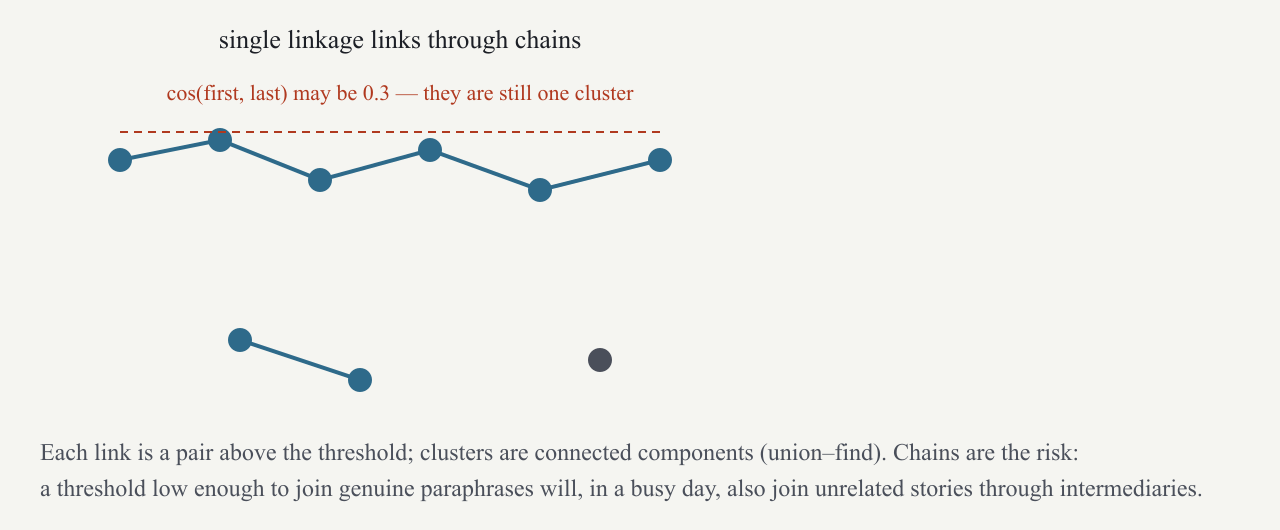

*Single linkage: clusters are connected components of the "similar enough" graph, so chains of intermediaries can join unrelated articles.*

Figure 14 examines the cosines of article pairs on five busy days (12 September 2001, 16 September 2008, 24 June 2016, 12 March 2020, 24 February 2022), split by whether the two ended up in the same story. A *distribution* describes how values are spread across possible sizes. A *histogram* groups them into intervals, or bins, and counts values in each interval. The sample's median is its middle value; its 99th percentile is a value at or below which about 99% of observations lie. The figure scales each histogram to its own highest bin, so equal displayed heights do not mean equal pair counts or equal probabilities. These are descriptive same-story labels from the grouping, not an independent human-labeled test set. In embedding space, pairs from *different* stories have median cosine 0.49 and a 99th percentile of 0.67—confirming that unrelated news embeddings sit around 0.5, not 0—while pairs from the same story have median 0.65 and a long tail toward 1. The two distributions overlap, as they must for anything less than a perfect representation, but the crossover is narrow.

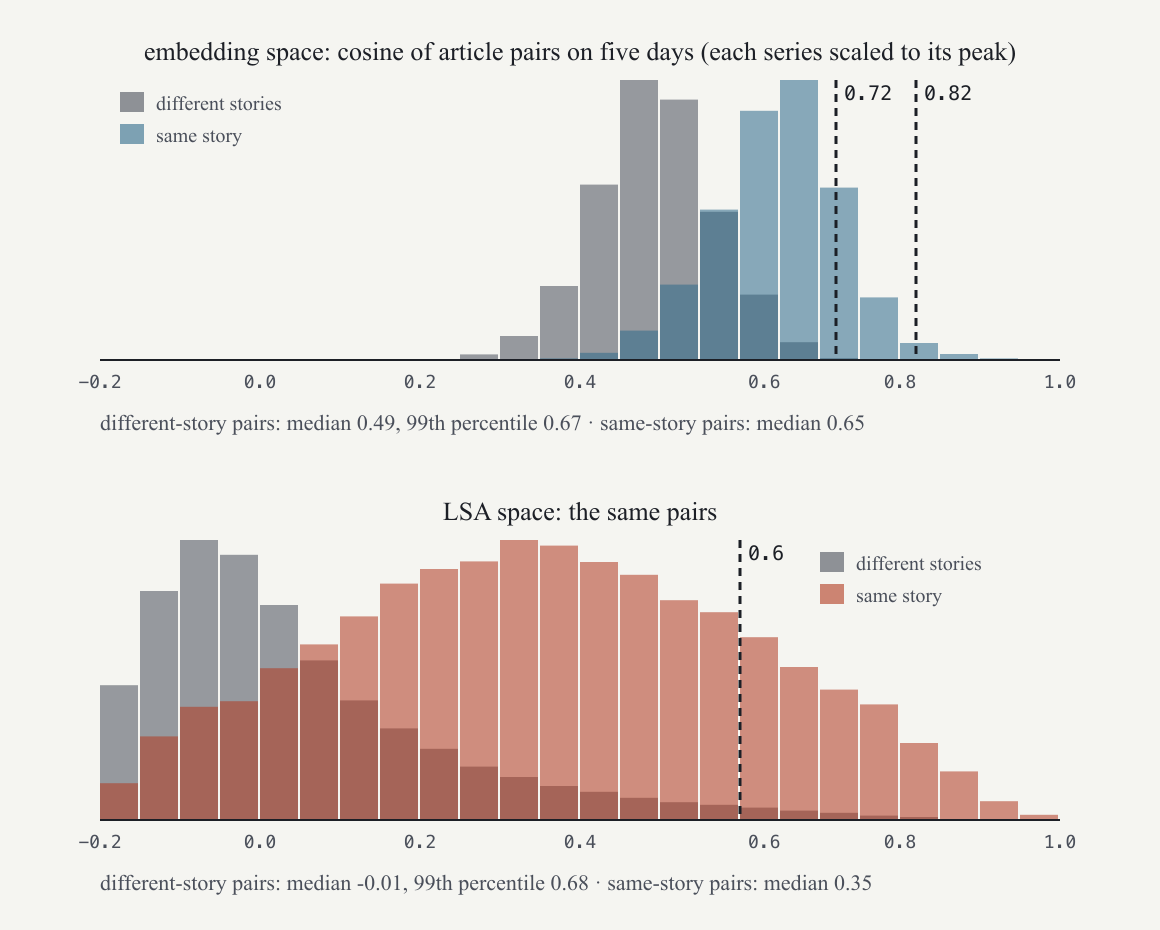

*Cosine similarity of article pairs on five busy days, in embedding space (top) and LSA space (bottom), split by whether the articles belong to the same story. Each series is scaled to its own peak.*

Choosing a threshold balances two failures. Lowering it adds edges, which can join distinct events through chains. Raising it removes edges, which can split one event into several components; this is *fragmentation*. Figure 15 shows the search for a useful balance on 24 February 2022, the day Russia invaded Ukraine. At 0.6, one chain contains 143 of the day's 152 articles—most of the day has become one "story". At 0.66 the chain still holds 104. At **0.72** the largest cluster is the 62‑article invasion story, the intended grouping identified during inspection, with 67 singletons (features, comment, unrelated items). At 0.78 the invasion story has fragmented to 34 articles; at 0.82 no cluster is larger than 8; at 0.9 only one linked pair remains: 151 components, the largest of size 2, and 150 singletons among 152 articles. These are the counts in the frozen aggregate fixture; the earlier wording that nothing linked was incorrect. The deployed threshold is 0.72. The sweep shows the effect of this choice on that day's graph; it does not prove an optimal threshold for every possible day. The original choice had been 0.82 (a number appropriate for a larger embedding model with longer inputs); the first look at the data—"Day of terror" on 12 September 2001 rendered as a three‑article story—showed it was wrong, and the sweep in Figure 15 replaced it.

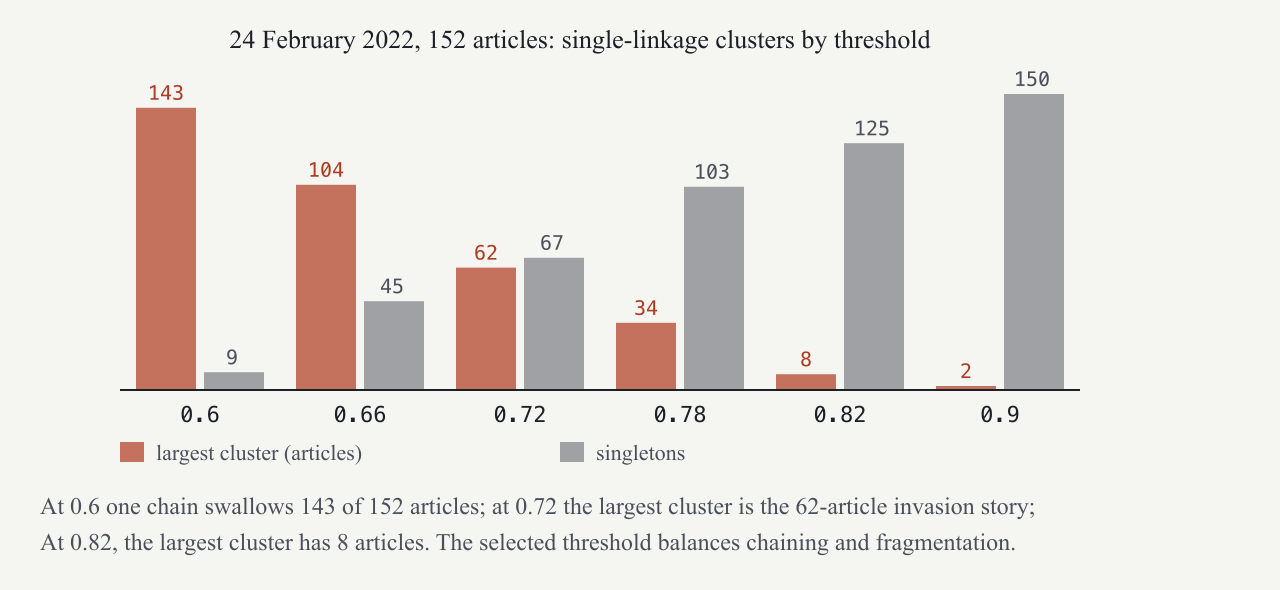

*Cluster sizes on 24 February 2022 as the threshold varies.*

The lower panel of Figure 14 explains why the LSA space needs a different threshold. LSA coordinates are projections onto the 60 leading right singular directions of the term matrix; articles about the same event share vocabulary but in a 60‑dimensional summary their cosines spread from 0 to 1 (median 0.35), and unrelated articles sit around 0 (median $-0.01$). The distributions are wider and cross lower, and the threshold that reproduces sensible stories is **0.6**. The same numerical threshold therefore has a different meaning in the two representations. Their coordinate systems and similarity distributions differ. This is one reason the deployed newspaper clusters in embedding space and uses the LSA basis only for measurement. The notebooks can recompute the histogram scaling and proportions from frozen aggregate counts; they cannot recreate historical cluster assignments without the original article vectors.

### Laboratory: Compute chaining and audit the archived threshold sweep

First we compute connected components on **synthetic unit vectors** at 0, 30,
60 and 90 degrees. A 0.72 link threshold connects the chain although its endpoint
cosine is zero; a 0.9 threshold separates all four. This illustrates the actual
algorithm without fabricating archive embeddings.

The second table recomputes proportions from the **frozen dated aggregate
fixture** `threshold-stats.json`; the underlying article vectors are not bundled,
so its historical clusters cannot be regenerated from scratch here. At a 0.9
threshold on 24 February 2022, the archived fixture records 151 clusters, largest
size 2, and 150 singletons among 152 articles. The book text now agrees with this
unchanged evidence: one pair remains linked.

In [30]:
let components vectors threshold=
 let n=rows vectors in let parents=Array.init n Fun.id in
 let rec root i=if parents.(i)=i then i else(let r=root parents.(i)in parents.(i)<-r;r)in
 for i=0 to n-1 do for j=0 to i-1 do if cosine vectors.(i)vectors.(j)>=threshold then parents.(root i)<-root j done done;
 let sizes=Array.make n 0 in for i=0 to n-1 do let r=root i in sizes.(r)<-sizes.(r)+1 done;
 Array.to_list sizes|>List.filter(fun n->n>0)|>List.sort(fun a b->compare b a);;
let chain=Array.map(fun angle->[|cos angle;sin angle|])[|0.;Float.pi/.6.;Float.pi/.3.;Float.pi/.2.|];;
assert(components chain 0.72=[4]);;assert(components chain 0.9=[1;1;1;1]);;
record_result "synthetic_chain_largest" (float_of_int(List.hd(components chain 0.72)));;

let archive_sweep = [|[|0.6;152.0;143.0;9.0|];[|0.66;152.0;104.0;45.0|];[|0.72;152.0;62.0;67.0|];[|0.78;152.0;34.0;103.0|];[|0.82;152.0;8.0;125.0|];[|0.9;152.0;2.0;150.0|]|];;
let archived_proportions=Array.map(fun row->[|row.(0);row.(2)/.row.(1);row.(3)|])archive_sweep;;
print_matrix "ARCHIVED threshold, largest fraction, singleton count" archived_proportions;;
let row072=Option.get(Array.find_opt(fun row->abs_float(row.(0)-.0.72)<1e-8)archive_sweep);;
record_result "archived_largest_fraction_072" (row072.(2)/.row072.(1));;

val components : float array array -> float -> int list = <fun>


val chain : float array array =
  [|[|1.; 0.|]; [|0.866025403784438708; 0.499999999999999944|];
    [|0.500000000000000111; 0.866025403784438597|];
    [|6.12323399573676604e-17; 1.|]|]


- : unit = ()


- : unit = ()


- : string = "synthetic_chain_largest = 4"


val archive_sweep : float array array =
  [|[|0.6; 152.; 143.; 9.|]; [|0.66; 152.; 104.; 45.|];
    [|0.72; 152.; 62.; 67.|]; [|0.78; 152.; 34.; 103.|];
    [|0.82; 152.; 8.; 125.|]; [|0.9; 152.; 2.; 150.|]|]


val archived_proportions : float array array =
  [|[|0.6; 0.940789473684210509; 9.|]; [|0.66; 0.684210526315789491; 45.|];
    [|0.72; 0.407894736842105254; 67.|];
    [|0.78; 0.223684210526315791; 103.|];
    [|0.82; 0.0526315789473684181; 125.|];
    [|0.9; 0.0131578947368421045; 150.|]|]


- : string =
"ARCHIVED threshold, largest fraction, singleton count (6 x 3)\n : [0.6; 0.940789; 9]\n : [0.66; 0.684211; 45]\n : [0.72; 0.407895; 67]\n : [0.78; 0.223684; 103]\n : [0.82; 0.0526316; 125]\n : [0.9; 0.0131579; 150]"


val row072 : float array = [|0.72; 152.; 62.; 67.|]


- : string = "archived_largest_fraction_072 = 0.407894736842"


### Laboratory: Recompute the archived histogram presentation

These are **frozen aggregate observations** underlying Figure 14, not raw article
vectors. For each embedding/LSA, same/different-story series we divide bin counts
by its own peak, exactly as the figure caption says. This is not a probability
density and is not normalization by the total pair count. We also compute the
fraction of counted pairs at cosine 0.6 or greater, a bin-aligned boundary. Exact
medians cannot be reconstructed from bins; the separately stored raw-sample
median is therefore displayed as **archived metadata**.

In [31]:
let hist_embed_same=[|0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;19.0;91.0;368.0;944.0;1884.0;3122.0;3508.0;2160.0;785.0;214.0;74.0;21.0;10.0|];;
let hist_embed_diff=[|0.0;0.0;0.0;0.0;0.0;0.0;0.0;3.0;38.0;275.0;1178.0;3623.0;8590.0;13716.0;12758.0;7263.0;3206.0;868.0;88.0;0.0;0.0;0.0;0.0;0.0|];;
let hist_lsa_same=[|126.0;286.0;387.0;406.0;519.0;600.0;696.0;808.0;858.0;884.0;957.0;938.0;882.0;838.0;751.0;710.0;625.0;523.0;446.0;395.0;263.0;166.0;64.0;18.0|];;
let hist_lsa_diff=[|3643.0;6193.0;7570.0;7168.0;5813.0;4316.0;3232.0;2474.0;1923.0;1445.0;1161.0;921.0;765.0;600.0;480.0;410.0;335.0;252.0;196.0;118.0;83.0;26.0;5.0;0.0|];;
let hist_bins=[|-0.2;-0.15;-0.1;-0.05;-0.0;0.05;0.1;0.15;0.2;0.25;0.3;0.35;0.4;0.45;0.5;0.55;0.6;0.65;0.7;0.75;0.8;0.85;0.9;0.95;1.0|];;
let histogram_summary counts=
 let peak=Array.fold_left max 0. counts and total=Array.fold_left (+.)0. counts in
 let heights=Array.map(fun count->count/.peak)counts in
 let tail=Array.fold_left (+.)0.(Array.mapi(fun i count->if hist_bins.(i)>=0.6 then count else 0.)counts)/.total in
 assert_close(Array.fold_left max 0. heights)1.;heights,tail;;
let heights_embed_same,tail_embed_same=histogram_summary hist_embed_same;;
record_result "hist_embed_same_tail06" tail_embed_same;;
print_vector "embed same peak-normalized archived bin heights" heights_embed_same;;
let heights_embed_diff,tail_embed_diff=histogram_summary hist_embed_diff;;
record_result "hist_embed_diff_tail06" tail_embed_diff;;
print_vector "embed diff peak-normalized archived bin heights" heights_embed_diff;;
let heights_lsa_same,tail_lsa_same=histogram_summary hist_lsa_same;;
record_result "hist_lsa_same_tail06" tail_lsa_same;;
print_vector "lsa same peak-normalized archived bin heights" heights_lsa_same;;
let heights_lsa_diff,tail_lsa_diff=histogram_summary hist_lsa_diff;;
record_result "hist_lsa_diff_tail06" tail_lsa_diff;;
print_vector "lsa diff peak-normalized archived bin heights" heights_lsa_diff;;
let archived_medians=[|[|0.6526788473129272;0.4945347458124161|];[|0.3512640595436096;-0.00955875450745225|]|];;
print_matrix "ARCHIVED medians: rows embed/LSA; columns same/different" archived_medians;;

val hist_embed_same : float array =
  [|0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 19.; 91.; 368.; 944.; 1884.;
    3122.; 3508.; 2160.; 785.; 214.; 74.; 21.; 10.|]


val hist_embed_diff : float array =
  [|0.; 0.; 0.; 0.; 0.; 0.; 0.; 3.; 38.; 275.; 1178.; 3623.; 8590.; 13716.;
    12758.; 7263.; 3206.; 868.; 88.; 0.; 0.; 0.; 0.; 0.|]


val hist_lsa_same : float array =
  [|126.; 286.; 387.; 406.; 519.; 600.; 696.; 808.; 858.; 884.; 957.; 938.;
    882.; 838.; 751.; 710.; 625.; 523.; 446.; 395.; 263.; 166.; 64.; 18.|]


val hist_lsa_diff : float array =
  [|3643.; 6193.; 7570.; 7168.; 5813.; 4316.; 3232.; 2474.; 1923.; 1445.;
    1161.; 921.; 765.; 600.; 480.; 410.; 335.; 252.; 196.; 118.; 83.; 26.;
    5.; 0.|]


val hist_bins : float array =
  [|-0.2; -0.15; -0.1; -0.05; -0.; 0.05; 0.1; 0.15; 0.2; 0.25; 0.3; 0.35;
    0.4; 0.45; 0.5; 0.55; 0.6; 0.65; 0.7; 0.75; 0.8; 0.85; 0.9; 0.95; 1.|]


...

val heights_lsa_diff : float array =
  [|0.481241743725231153; 0.818097754293262924; 1.; 0.946895640686922113;
    0.767899603698811; 0.570145310435931307; 0.426948480845442513;
    0.326816380449141353; 0.254029062087186286; 0.190885072655217952;
    0.153368560105680313; 0.121664464993394977; 0.101056803170409507;
    0.0792602377807133385; 0.0634081902245706708; 0.0541611624834874503;
    0.044253632760898283; 0.0332892998678996; 0.0258916776750330244;
    0.0155878467635402907; 0.0109643328929986787; 0.00343461030383091165;
    0.000660501981505944523; 0.|]
val tail_lsa_diff : float = 0.0206598953774756247


- : string = "hist_lsa_diff_tail06 = 0.0206598953775"


- : string =
"lsa diff peak-normalized archived bin heights: [0.481242; 0.818098; 1; 0.946896; 0.7679; 0.570145; 0.426948; 0.326816; 0.254029; 0.190885; 0.153369; 0.121664; 0.101057; 0.0792602; 0.0634082; 0.0541612; 0.0442536; 0.0332893; 0.0258917; 0.0155878; 0.0109643; 0.00343461; 0.000660502; 0]"


val archived_medians : float array array =
  [|[|0.652678847312927246; 0.494534745812416077|];
    [|0.351264059543609619; -0.00955875450745225|]|]


- : string =
"ARCHIVED medians: rows embed/LSA; columns same/different (2 x 2)\n : [0.652679; 0.494535]\n : [0.351264; -0.00955875]"


### Laboratory: Verify the corrected strict-threshold count

The manuscript now agrees with the archived 24 February 2022 aggregate at a
0.9 threshold. There are 150 singleton components and one component of size
two: 151 components covering 152 articles. This corrects prose only; it does
not recompute or change the historical cluster fixture. The synthetic four-node
chain above is a different dataset, on which 0.9 does leave all nodes separate.

In [32]:
let strict_archived=Option.get(Array.find_opt(fun row->abs_float(row.(0)-.0.9)<1e-8)archive_sweep);;
(* Frozen row columns: threshold, article count, largest size, singleton count. *)
let strict_clusters=strict_archived.(3)+.1.;;
assert_close strict_archived.(1)152.;;assert_close strict_archived.(2)2.;;assert_close strict_archived.(3)150.;;
assert_close(strict_archived.(3)+.strict_archived.(2))strict_archived.(1);;
assert_close strict_clusters 151.;;
assert_close(cosine chain.(0)chain.(1))(sqrt 3./.2.);;
record_result "archived_clusters_090" strict_clusters;;
record_result "archived_largest_090" strict_archived.(2);;
record_result "chain_adjacent_cosine" (cosine chain.(0)chain.(1));;

val strict_archived : float array = [|0.9; 152.; 2.; 150.|]


val strict_clusters : float = 151.


- : unit = ()


- : unit = ()


- : unit = ()


...

- : unit = ()


- : unit = ()


- : string = "archived_clusters_090 = 151"


- : string = "archived_largest_090 = 2"


- : string = "chain_adjacent_cosine = 0.866025403784"


<a id="episodes-threading-across-days"></a>

## Episodes: threading across days

An *episode* is a chain of related stories across days. First summarize each story by its *centroid*: average its member embedding vectors, then use that mean's direction in the cosine comparison. Averaging is done coordinate by coordinate. A zero mean has no direction, so an implementation must handle that case explicitly rather than calculate an undefined cosine.

In this subsection $t$ indexes calendar days, distinct from the earlier term index. To thread a story on day $t$, compare its centroid with each story centroid on day $t-1$. Keep the greatest cosine, the *best match*. If it reaches **0.9**, continue that previous story's episode; otherwise start a new episode. This is a best-previous-story rule, not a one-to-one assignment between all stories on the two days. Several current stories can independently select the same previous episode.

The threshold acts after the maximum is found. In the notebook's synthetic two-story example, one current centroid has best similarity 0.92 and continues; the other fails the 0.9 threshold and starts a new episode. A best match always exists when there are eligible nonzero previous vectors, but it need not be a good match. Figure 16 shows, for 678 stories over eight day-pairs, each best previous-day cosine. With raw embeddings the median is 0.66 because unrelated news shares a common component. Reported continuations above the strict threshold include "Battle for Kyiv" after "Putin invasion deepens" (0.92), the Hamas attack's death toll two days running (0.90), and Brexit voters' portraits (0.93). In late February 2022, 21 of 1,077 stories continued an episode, and the longest, the invasion, ran fourteen days from 18 February to 3 March.

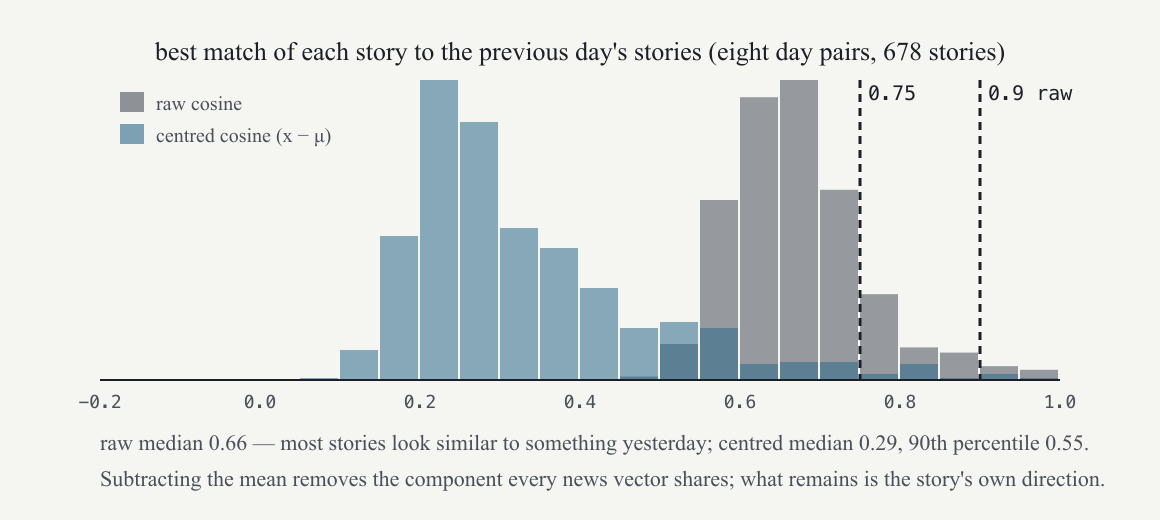

*Best previous‑day match per story, with raw and with centred cosines.*

Subtracting the mean first removes the common component and lowers the median to 0.29, with a sparser region around 0.55–0.75. A centred threshold near 0.75 is a candidate for separate evaluation, not a direct replacement proved by the figure. It would still miss the cited Crimea continuation at 0.69; lowering it enough to include that pair could also admit the unrelated New Zealand protest and abortion pair at 0.70. To assess this tradeoff, first obtain judgments of which candidate links really are continuations. *Precision* is the number of correct accepted links divided by all accepted links. *Recall* is the number of correct accepted links divided by all true continuations in the evaluated set. If no link is accepted, precision has a zero denominator; if the evaluated set has no true links, recall does too. Those cases need explicit reporting conventions.

The notebooks supply five labeled synthetic candidates: three true links at 0.92, 0.90, and 0.93, a false link at 0.70, and a true link at 0.69. A 0.9 threshold accepts three correct links: precision is $3/3=1$ and recall is $3/4=0.75$. Lowering it to 0.69 recovers all four true links but also accepts the false one: precision becomes $4/5=0.8$ and recall $4/4=1$. Those labels are teaching inputs, not a new evaluation of the historical stories. The strict raw rule aims to favor precision. An episode is a thread, not a day: "episode day 7" counts from the chain's beginning, and an archetype's canon counts episodes rather than repeated days.

### Laboratory: Best matches, thresholds and precision on labeled fixtures

`previous` and `current` are synthetic unit centroid rows. Each current row picks
its best previous-day cosine before the 0.9 threshold is applied. Separately,
`candidate_scores` and `is_true_link` form an explicit miniature labeled set to
compute precision and recall at alternative thresholds. Those labels are teaching
inputs, not judgments about the historical examples above. A new episode starts
when no previous match is accepted.

In [33]:
let previous=eye 2 and current=[|[|0.92;sqrt(1.-.0.92**2.)|];[|0.7;sqrt(1.-.0.7**2.)|]|];;
let best_scores=Array.map(fun row->Array.fold_left max neg_infinity row)(matmul current(transpose previous));;
let accepted=Array.map(fun score->score>=0.9)best_scores;;assert(accepted=[|true;false|]);;
let candidate_scores=[|0.92;0.9;0.93;0.7;0.69|] and is_true_link=[|true;true;true;false;true|];;
let precision_recall threshold=
 let tp=ref 0 and selected=ref 0 and actual=ref 0 in
 Array.iteri(fun i score->if is_true_link.(i)then incr actual;if score>=threshold then(incr selected;if is_true_link.(i)then incr tp))candidate_scores;
 [|threshold;float_of_int !tp/.float_of_int(max 1 !selected);float_of_int !tp/.float_of_int !actual|];;
print_matrix "threshold, labeled precision, labeled recall" (Array.map precision_recall[|0.9;0.75;0.69|]);;
record_result "strict_episode_links" (float_of_int(Array.fold_left(fun n b->n+if b then 1 else 0)0 accepted));;

val previous : float array array = [|[|1.; 0.|]; [|0.; 1.|]|]
val current : float array array =
  [|[|0.92; 0.391918358845308457|]; [|0.7; 0.714142842854285|]|]


val best_scores : float array = [|0.92; 0.714142842854285|]


val accepted : bool array = [|true; false|]


- : unit = ()


val candidate_scores : float array = [|0.92; 0.9; 0.93; 0.7; 0.69|]
val is_true_link : bool array = [|true; true; true; false; true|]


val precision_recall : float -> float array = <fun>


- : string =
"threshold, labeled precision, labeled recall (3 x 3)\n : [0.9; 1; 0.75]\n : [0.75; 1; 0.75]\n : [0.69; 0.8; 1]"


- : string = "strict_episode_links = 1"


### Laboratory: Recompute the raw-versus-centered archived comparison

Figure 16's **frozen aggregate** contains 678 best-match scores summarized in
bins for raw and centered embeddings. We normalize each histogram to its own
peak and compute cumulative fractions below the bin edge 0.55. The displayed
0.66 and 0.29 medians remain archived metadata; binned counts alone would locate
only an interval containing each median. This comparison does not establish a
replacement production threshold or regenerate neural embeddings.

In [34]:
let episode_bins=[|-0.2;-0.15;-0.1;-0.05;-0.0;0.05;0.1;0.15;0.2;0.25;0.3;0.35;0.4;0.45;0.5;0.55;0.6;0.65;0.7;0.75;0.8;0.85;0.9;0.95;1.0|];;
let episode_raw=[|0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;2.0;21.0;105.0;165.0;175.0;111.0;50.0;19.0;16.0;8.0;6.0|];;
let episode_centered=[|0.0;0.0;0.0;0.0;0.0;1.0;15.0;72.0;150.0;129.0;76.0;66.0;46.0;26.0;29.0;26.0;8.0;9.0;9.0;3.0;8.0;1.0;3.0;1.0|];;
let below055 values=
 let total=Array.fold_left (+.)0. values in assert_close total 678.;
 Array.fold_left (+.)0.(Array.mapi(fun i count->if episode_bins.(i+1)<=0.55 then count else 0.)values)/.total;;
record_result "episode_raw_below055" (below055 episode_raw);;
record_result "episode_centered_below055" (below055 episode_centered);;
print_vector "raw peak-normalized archived bins" (Array.map(fun x->x/.Array.fold_left max 0. episode_raw)episode_raw);;
print_vector "centered peak-normalized archived bins" (Array.map(fun x->x/.Array.fold_left max 0. episode_centered)episode_centered);;

val episode_bins : float array =
  [|-0.2; -0.15; -0.1; -0.05; -0.; 0.05; 0.1; 0.15; 0.2; 0.25; 0.3; 0.35;
    0.4; 0.45; 0.5; 0.55; 0.6; 0.65; 0.7; 0.75; 0.8; 0.85; 0.9; 0.95; 1.|]


val episode_raw : float array =
  [|0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 2.; 21.; 105.; 165.;
    175.; 111.; 50.; 19.; 16.; 8.; 6.|]


val episode_centered : float array =
  [|0.; 0.; 0.; 0.; 0.; 1.; 15.; 72.; 150.; 129.; 76.; 66.; 46.; 26.; 29.;
    26.; 8.; 9.; 9.; 3.; 8.; 1.; 3.; 1.|]


val below055 : float array -> float = <fun>


- : string = "episode_raw_below055 = 0.0339233038348"


- : string = "episode_centered_below055 = 0.899705014749"


- : string =
"raw peak-normalized archived bins: [0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0.0114286; 0.12; 0.6; 0.942857; 1; 0.634286; 0.285714; 0.108571; 0.0914286; 0.0457143; 0.0342857]"


- : string =
"centered peak-normalized archived bins: [0; 0; 0; 0; 0; 0.00666667; 0.1; 0.48; 1; 0.86; 0.506667; 0.44; 0.306667; 0.173333; 0.193333; 0.173333; 0.0533333; 0.06; 0.06; 0.02; 0.0533333; 0.00666667; 0.02; 0.00666667]"


### Laboratory: Count the denominators in precision and recall

A threshold changes which of the five explicitly labeled teaching candidates
are accepted. Count correct accepted links, all accepted links, and all true
links before dividing. The distinction is visible even though each reported
ratio happens to lie between zero and one.

In [35]:
Array.iter(fun(cutoff,suffix)->
 let values=precision_recall cutoff in
 ignore(record_result("episode_precision_"^suffix)values.(1));
 ignore(record_result("episode_recall_"^suffix)values.(2))
)[|(0.9,"strict");(0.69,"loose")|];;
let strict_values=precision_recall 0.9 and loose_values=precision_recall 0.69;;
assert_close strict_values.(1)1.;;assert_close strict_values.(2)0.75;;
assert_close loose_values.(1)0.8;;assert_close loose_values.(2)1.;;

- : unit = ()


val strict_values : float array = [|0.9; 1.; 0.75|]
val loose_values : float array = [|0.69; 0.8; 1.|]


- : unit = ()


- : unit = ()


- : unit = ()


- : unit = ()


<a id="precedents"></a>

## Precedents

A *precedent* is an earlier candidate presented for comparison, not proof that history will repeat. The search has an eligibility stage and a ranking stage.

First retain only stories earlier than the query story and having the same dominant axis. This prevents future stories from entering a historical comparison and makes the archetype part of the search definition. Then compare named-coordinate vectors by cosine. Among stories from the same episode, keep the strongest match; finally take the five strongest remaining matches, or fewer if fewer are eligible. The distinct-episode restriction avoids filling the list with five days of the same event.

No similarity threshold is required to return the nearest eligible candidates. This is a *ranking*: the largest scores come first. A ranking can still return weak matches if all eligible candidates are weak. Printing the cosine beside each precedent lets the reader assess that distinction: recorded examples include 0.97 for the same week's build-up briefing and 0.93 for Crimea in 2014. A shared dominant axis or a large cosine establishes resemblance in this representation, not a causal relationship between the events.

### Laboratory: Select only eligible earlier stories

The tuples below carry an integer day, dominant-axis ID, episode ID and similarity to a
query on day 10 with dominant axis 0. We filter by time and axis, then keep only
the strongest entry per distinct episode, before taking the five closest. A very similar future story and a different-axis story must
not leak into the precedent list. Scores here are editable fixtures.

In [36]:
let precedent_candidates=[(3,0,"a",0.8);(11,0,"future",0.99);(4,1,"other",0.95);(7,0,"a",0.7);(1,0,"b",0.9);(9,0,"c",0.6);(2,0,"d",0.75);(8,0,"e",0.65)];;
let eligible=List.filter(fun(day,axis,_,_)->day<10 && axis=0)precedent_candidates|>List.sort(fun(_,_,_,a)(_,_,_,b)->compare b a);;
let rec first n xs=match n,xs with 0,_|_,[]->[]|_,x::tail->x::first(n-1)tail;;
let rec distinct seen candidates=match candidates with []->[]|((_,_,episode,_) as row)::rest->if List.mem episode seen then distinct seen rest else row::distinct(episode::seen)rest;;
let precedents=first 5(distinct [] eligible);;assert(List.length precedents=5);;
let _,_,_,best_precedent_similarity=List.hd precedents;;record_result "best_precedent_similarity" best_precedent_similarity;;
precedents;;

val precedent_candidates : (int * int * string * float) list =
  [(3, 0, "a", 0.8); (11, 0, "future", 0.99); (4, 1, "other", 0.95);
   (7, 0, "a", 0.7); (1, 0, "b", 0.9); (9, 0, "c", 0.6); (2, 0, "d", 0.75);
   (8, 0, "e", 0.65)]


val eligible : (int * int * string * float) list =
  [(1, 0, "b", 0.9); (3, 0, "a", 0.8); (2, 0, "d", 0.75); (7, 0, "a", 0.7);
   (8, 0, "e", 0.65); (9, 0, "c", 0.6)]


val first : int -> 'a list -> 'a list = <fun>


val distinct :
  'a list -> ('b * 'c * 'a * 'd) list -> ('b * 'c * 'a * 'd) list = <fun>


val precedents : (int * int * string * float) list =
  [(1, 0, "b", 0.9); (3, 0, "a", 0.8); (2, 0, "d", 0.75); (8, 0, "e", 0.65);
   (9, 0, "c", 0.6)]


- : unit = ()


val best_precedent_similarity : float = 0.9


- : string = "best_precedent_similarity = 0.9"


- : (int * int * string * float) list =
[(1, 0, "b", 0.9); (3, 0, "a", 0.8); (2, 0, "d", 0.75); (8, 0, "e", 0.65);
 (9, 0, "c", 0.6)]


<a id="the-statistical-thresholds"></a>

# The statistical thresholds

<a id="sigma-on-the-spectrum"></a>

## ±2σ on the spectrum

The symbol $\sigma$ in this heading means a reference standard deviation. For each named axis, collect one spectrum value per loaded day. Subtract their mean to describe departures from the usual level, then divide by their positive standard deviation to put those departures on a common scale. The unit is now "reference standard deviations", rather than the original coordinate unit. An axis is *loud* above $+2$ and *silent* below $-2$.

<a id="calculate-a-reference-spread-before-a-z-score"></a>

### Calculate a reference spread before a z-score

Use the synthetic daily values $-1,0,1,2,3$. Their mean is $1$. Their deviations are $-2,-1,0,1,2$, whose squares add to $4+1+0+1+4=10$. The notebook uses the *sample variance*: divide by the count minus one, giving $10/(5-1)=2.5$. Its standard deviation is $\sqrt{2.5}\approx1.581$. This count-minus-one convention differs from the total-weight normalization of the fitted covariance earlier; name the convention instead of silently switching denominators.

Against this reference, a value $-3$ first gives deviation $-3-1=-4$, then z-score $-4/\sqrt{2.5}\approx-2.530$. It belongs to *Silence*. Neither $-3$ nor $-4$ alone could be compared directly with the standardized cutoff $-2$; dividing by the reference spread is essential.

To obtain the same summaries one value at a time, let $n$ be the count *after* a new scalar value $a$ arrives. Let $h_{\mathrm{old}}$ denote the previous running mean and $A_{\mathrm{old}}$ the previous sum of squared deviations from that mean. Define $\delta=a-h_{\mathrm{old}}$, the new value's departure from the old mean. The updated mean $h_{\mathrm{new}}$ moves by that departure divided among all $n$ values:

$$h_{\mathrm{new}}=h_{\mathrm{old}}+\delta/n.$$

The updated squared-deviation sum is

$$A_{\mathrm{new}}=A_{\mathrm{old}}+\delta(a-h_{\mathrm{new}}).$$

These are Welford's updates. Initialize the first mean at the first observation and its deviation sum at zero. Each later update uses both the old and new mean; this compensates for the movement of the reference point. With at least two values, divide the final sum by $n-1$ for the sample variance. With only one value, that sample variance is undefined. The notebooks verify these updates against the direct five-value calculation.

<a id="a-standardized-cutoff-is-not-automatically-a-probability"></a>

### A standardized cutoff is not automatically a probability

A *probability model* specifies how frequently values are expected to fall in different ranges. A Gaussian, or normal bell-shaped distribution, is one such model. Under that model, about 4.55% of observations lie outside two standard deviations, often rounded to "one in twenty". News series can be *heavy-tailed*, meaning that large departures occur more often than this model predicts. Standardization alone does not make them Gaussian.

There is also a many-comparisons issue. If 60 axes each really had the Gaussian 4.55% tail frequency, the expected number flagged would be about $60\times0.0455=2.73$. An *expected number* is a long-run average count, not the probability that any particular day has a flag. This average-count calculation does not require independent axes; independence would be an additional assumption when calculating the probability of at least one flag. The notebooks compute the Gaussian benchmark, not a calibrated newspaper alarm probability.

The empirical display intent is that a typical day lights one to three axes, not ten. On 24 February 2022 the Ukraine axis was at $+8$; on 12 September 2001 terrorism was at $+2.9$, Europe at $+2.6$, markets at $+2.5$. These recorded numbers are spectrum z-scores against the loaded reference, not probabilities.

### Laboratory: Welford statistics and the multiple-axis caveat

`era_values` is a small synthetic all-loaded-day reference, not a historical
forecast. We compute count, running mean, and squared-deviation accumulator
using Welford's update, then the **sample** standard deviation. A new value's
z-score is compared to ±2; a value below −2 belongs to Silence. The Gaussian
calculation is an illustration: multiplying the two-sided tail probability by
60 gives an expected number of flagged axes, not a calibrated newspaper alarm.

In [37]:
let era_values=[|-1.;0.;1.;2.;3.|];;
let welford values=let count=ref 0 and mean=ref 0. and m2=ref 0. in
 Array.iter(fun x->incr count;let delta=x-. !mean in mean:= !mean+.delta/.float_of_int !count;m2:= !m2+.delta*.(x-. !mean))values;
 !count,!mean,!m2;;
let count,running_mean,m2_sum=welford era_values;;let era_sd=sqrt(m2_sum/.float_of_int(count-1));;
let z_score=(-3.-.running_mean)/.era_sd;;assert(z_score < -2.);;
let normal_tail cutoff=
 let n=1000 in let h=cutoff/.float_of_int n in
 let density x=exp(-.x*.x/.2.)/.sqrt(2.*.Float.pi) in
 let total=ref(density 0.+.density cutoff)in
 for i=1 to n-1 do total:= !total+.(if i mod 2=0 then 2. else 4.)*.density(float_of_int i*.h)done;
 1.-.2.*.h*. !total/.3.;;
record_result "era_sample_sd" era_sd;;record_result "silence_zscore" z_score;;
record_result "gaussian_expected_flags_60" (60.*.normal_tail 2.);;

val era_values : float array = [|-1.; 0.; 1.; 2.; 3.|]


val welford : float array -> int * float * float = <fun>


val count : int = 5
val running_mean : float = 1.
val m2_sum : float = 10.


val era_sd : float = 1.58113883008418976


val z_score : float = -2.52982212813470353


- : unit = ()


val normal_tail : float -> float = <fun>


- : string = "era_sample_sd = 1.58113883008"


- : string = "silence_zscore = -2.52982212813"


- : string = "gaussian_expected_flags_60 = 2.73001583378"


### Laboratory: Inspect every running-mean correction

The direct squared deviations of -1, 0, 1, 2, 3 about their mean one sum to ten.
The sample-variance denominator is four, giving 2.5. The update table records
count, incoming value, departure from the OLD mean, NEW mean, and the updated
squared-deviation sum. The first value initializes the summaries. This is the
same Welford calculation already used above, expanded for inspection.

In [38]:
let direct_mean=Array.fold_left (+.)0. era_values/.float_of_int(Array.length era_values);;
let direct_deviations=Array.map(fun x->x-.direct_mean)era_values;;
let sum_squared_deviations=dot direct_deviations direct_deviations;;
assert_close direct_mean 1.;;assert_close sum_squared_deviations 10.;;
assert_close(sum_squared_deviations/.float_of_int(Array.length era_values-1))2.5;;
let step_mean=ref era_values.(0) and step_sum=ref 0.;;
let step_rows=Array.init(Array.length era_values)(fun i->
 let value=era_values.(i)and count_new=float_of_int(i+1)in
 if i=0 then[|count_new;value;0.;!step_mean;!step_sum|]else(
 let delta=value-. !step_mean in let mean_new= !step_mean+.delta/.count_new in
 step_sum:= !step_sum+.delta*.(value-.mean_new);step_mean:=mean_new;
 [|count_new;value;delta;!step_mean;!step_sum|]));;
assert_close !step_mean direct_mean;;assert_close !step_sum sum_squared_deviations;;
print_matrix "count, value, old departure, new mean, deviation sum" step_rows;;
record_result "era_mean_direct" direct_mean;;
record_result "era_deviation_sum_direct" sum_squared_deviations;;
record_result "era_sample_variance_direct" (sum_squared_deviations/.float_of_int(Array.length era_values-1));;
record_result "gaussian_tail_two_sigma" (normal_tail 2.);;
record_result "gaussian_tail_one_point_five_sigma" (normal_tail 1.5);;

val direct_mean : float = 1.


val direct_deviations : float array = [|-2.; -1.; 0.; 1.; 2.|]


val sum_squared_deviations : float = 10.


- : unit = ()


- : unit = ()


...

- : string = "era_mean_direct = 1"


- : string = "era_deviation_sum_direct = 10"


- : string = "era_sample_variance_direct = 2.5"


- : string = "gaussian_tail_two_sigma = 0.0455002638964"


- : string = "gaussian_tail_one_point_five_sigma = 0.133614402538"


<a id="sigma-for-different-this-time"></a>

## 1.5σ for "different this time"

Now change the reference set. We are comparing one story with the stories usually assigned to its archetype, rather than comparing a day with other days. On each axis, subtract the archetype profile mean from the story coordinate and divide by the positive profile standard deviation. Keep departures whose absolute values exceed 1.5, sort them by that magnitude, and display at most three.

For example, the notebook has profile mean $2$, profile standard deviation $0.5$, and story value $3.6$ on one synthetic axis. The departure is $(3.6-2)/0.5=3.2$ profile standard deviations. Another has mean $0$, standard deviation $2$, and value $-4$, giving $-2$. Both exceed 1.5 in magnitude, but their signs say whether the story lies above or below its profile. A story exactly at every profile mean produces zero departures and an empty panel.

The threshold is lower than the spectrum's because the display asks a different question: whether *this instance* differs from its class. A specific secondary signal, such as *airline · airport* on a terrorism story at $+3.2\sigma$, can be useful to inspect. The recorded invasion example has *nothing beyond 1.5σ of this archetype's profile*; an empty panel is a possible result, not an error.

This display rule is not a formal proof that a difference is statistically significant. Under a Gaussian reference, a two-sided 1.5-standard-deviation cutoff is crossed about 13.36% of the time. Across 59 such secondary axes, the expected count would be about $7.88$. Correlation between axes changes how flags arrive together; it does not by itself invalidate this expectation calculation if the individual Gaussian tail assumptions held. Here those marginal assumptions are not established either. The empirical panel depends on the observed profile distributions, their correlations, and the three-item display cap.

### Laboratory: Compute departures and cap the displayed list

`profile_mean` and `profile_sd` describe a synthetic archetype reference.
`story_named` is an instance. We standardize departures, keep magnitudes strictly
larger than 1.5, sort largest first and take at most three. The zero-departure
case produces an empty list. The expected Gaussian count over 59 secondary
axes explains why a threshold is not an automatic significance certificate.

In [39]:
let profile_mean=[|1.;2.;0.;-1.|] and profile_sd=[|1.;0.5;2.;1.|] and story_named=[|1.2;3.6;-4.;-.0.8|];;
let departures=Array.mapi(fun j x->(x-.profile_mean.(j))/.profile_sd.(j))story_named;;
let changed=Array.to_list(Array.init 4 Fun.id)|>List.filter(fun j->abs_float departures.(j)>1.5)|>List.sort(fun a b->compare(abs_float departures.(b))(abs_float departures.(a)))|>first 3;;
assert(changed=[1;2]);;
record_result "largest_profile_departure" departures.(List.hd changed);;
record_result "gaussian_profile_false_flags" (59.*.normal_tail 1.5);;
List.map(fun j->j,departures.(j))changed;;

val profile_mean : float array = [|1.; 2.; 0.; -1.|]
val profile_sd : float array = [|1.; 0.5; 2.; 1.|]
val story_named : float array = [|1.2; 3.6; -4.; -0.8|]


val departures : float array =
  [|0.199999999999999956; 3.2; -2.; 0.199999999999999956|]


val changed : int list = [1; 2]


- : unit = ()


- : string = "largest_profile_departure = 3.2"


- : string = "gaussian_profile_false_flags = 7.88324974972"


- : (int * float) list = [(1, 3.2); (2, -2.)]


<a id="energy-1-nu-for-ranking"></a>

## Energy × (1 + ν) for ranking

Let $\nu_s$ be story $s$'s mean member-article novelty ratio, distinguishing it from a ratio calculated on the story centroid. Recall its attention weight $\varepsilon_s$. The ranking score is

$$\varepsilon_s(1+\nu_s).$$

The first factor rewards the recorded source and article attention. The second raises that score when more of the member articles' centred variation lies outside the retained model. Since $0\le\nu_s\le1$, the multiplier runs from one to two: an equally energetic story at novelty one gets twice the score of one at novelty zero. This is an explicit ranking design, not a learned probability of importance. The residual section orders by $\nu_s$ alone. A large residual remains a property of this representation, not independent evidence of newsworthiness.

### Laboratory: Attention-adjusted novelty ranking

`novelties` gives stipulated mean member-article novelty ratios for the three
stories from the spectrum fixture. Multiplying attention by one plus novelty
changes ordering without making novelty an independent truth or importance
score. Equal attention with novelty one doubles the zero-novelty rank score.

In [40]:
let novelties=[|0.;0.8;0.2|];;let rank_scores=Array.mapi(fun i e->e*.(1.+.novelties.(i)))attention;;
print_vector "rank scores" rank_scores;;record_result "maximum_rank_score" (Array.fold_left max neg_infinity rank_scores);;

val novelties : float array = [|0.; 0.8; 0.2|]


val rank_scores : float array =
  [|2.77258872223978114; 1.24766492500790149; 6.45033408922099838|]


- : string = "rank scores: [2.77259; 1.24766; 6.45033]"


- : string = "maximum_rank_score = 6.45033408922"


<a id="for-matching-axes-across-nights"></a>

## 0.8 for matching axes across nights

A nightly refit supplies new eigenvectors. Their order can change, and multiplying an eigenvector by $-1$ leaves the same geometric line. Comparing column numbers or signed cosines alone would confuse these bookkeeping changes with new patterns.

An assignment first pairs new and old eigenvectors to maximize total absolute cosine, written $|\cos|$ and explained in the next chapter. Absolute value removes the sign ambiguity: cosine $-1$ and cosine $+1$ both identify the same line. After pairing, signs can be oriented to agree with the old directions.

A matched cosine below 0.8 is rejected: the component is treated as a new archetype, while retirement uses the separate noise-edge rule. The notebook reverses one axis's sign during a small rotation and verifies that this does not turn a strong match into a rejection. Reported well-separated axes match at 0.99+ between nights. The 0.8 value is an operational continuity rule, not proof of semantic identity; poorly separated directions can move substantially while their common subspace stays similar.

### Laboratory: Reject weak matches without confusing signs

The columns of `old_axes` are the coordinate basis. `new_axes` rotates two of
them by 0.2 radians and reverses one sign. Absolute cosine treats a sign flip as
the same line; the 0.8 threshold is then applied after matching. A 0.7 candidate
is rejected. This operational rule does not establish semantic identity.

In [41]:
let old_axes=eye 2 and new_axes=matmul(rotation_matrix 0.2)(diag[|-1.;1.|]);;
let absolute_matches=Array.map(Array.map abs_float)(matmul(transpose old_axes)new_axes);;
assert(absolute_matches.(0).(0)>0.8 && absolute_matches.(1).(1)>0.8);;
record_result "nightly_absolute_match" absolute_matches.(0).(0);;print_matrix "absolute matches" absolute_matches;;

val old_axes : float array array = [|[|1.; 0.|]; [|0.; 1.|]|]
val new_axes : float array array =
  [|[|-0.980066577841241626; -0.198669330795061216|];
    [|-0.198669330795061216; 0.980066577841241626|]|]


val absolute_matches : float array array =
  [|[|0.980066577841241626; 0.198669330795061216|];
    [|0.198669330795061216; 0.980066577841241626|]|]


- : unit = ()


- : string = "nightly_absolute_match = 0.980066577841"


- : string =
"absolute matches (2 x 2)\n : [0.980067; 0.198669]\n : [0.198669; 0.980067]"


<a id="matching-axes"></a>

# Matching axes

<a id="kuhnmunkres"></a>

## Kuhn–Munkres

Suppose several old axes each resemble several new axes. Picking the best match for one axis can consume the only good match available to another. We need to consider the whole set of pairings together.

An *assignment problem* chooses a one-to-one pairing: each old axis receives one new axis, and no new axis is reused. Its objective is to maximize the sum of the chosen similarities. For a small synthetic example, the notebook uses this table; rows name old axes and columns name new axes:

| | new A | new B | new C |
|---|---:|---:|---:|
| old A | 0.90 | 0.80 | 0.10 |
| old B | 0.85 | 0.20 | 0.10 |
| old C | 0.10 | 0.10 | 0.95 |

Taking old A's strongest match first selects new A at 0.90. If old B then takes new B and old C takes new C, the total is $0.90+0.20+0.95=2.05$. Swapping the first two matches gives $0.80+0.85+0.95=2.60$, a larger total. The slightly weaker choice for old A permits a much stronger one for old B. This is why a *greedy* procedure, choosing the best currently available local option, need not solve the global assignment.

The Hungarian algorithm, also called Kuhn–Munkres, solves the assignment problem without trying every possible permutation. It runs in *polynomial time*: its work grows no faster than a fixed power of the problem size. The numerical routines implement that search; the similarity table and one-to-one constraint define what it is solving. For nightly comparisons in the same feature space, table entries are absolute eigenvector cosines. Signs are then oriented to agree.

<a id="compare-different-spaces-through-shared-observations"></a>

### Compare different spaces through shared observations

A raw dot product requires matching coordinate meanings and dimensions. The notation $\mathbb R^d$ means lists of $d$ real-number coordinates. A 50,000-term direction and a 384-coordinate embedding direction live in $\mathbb R^{50{,}000}$ and $\mathbb R^{384}$ respectively. Their entries cannot be multiplied pairwise to obtain a meaningful cosine.

Instead ask both directions about the *same stories in the same order*. Each direction yields one score per story. Those two score columns now have matching observation positions, regardless of the different spaces that produced them.

Compare the score columns using *correlation*: their covariance divided by their positive standard deviations. Operationally, subtract each column's own mean, take the dot product of the centred columns, and divide by their lengths. This is the cosine of the centred score columns; the common averaging denominators cancel. Positive correlation means above-mean scores tend to occur on the same stories, negative correlation means they tend to occur on opposite stories, and a constant column has no defined correlation because its centred length is zero.

For intuition, the notebook pairs scores $1,2,3,4,5$ with an identical score column produced in the other space. Their shared ordering and departures give correlation one. Reversing a nonconstant centred column's sign reverses the correlation. Using these score comparisons as table entries lets assignment match across representations without pretending their original coordinate systems are the same.

The reported study compared scores on the same 100,000 stories. Figure 17 shows selected matches: Ukraine with Ukraine at 0.67 and courts with courts at 0.62; the reported comparisons also include the EU at 0.57. Those are dated empirical associations. The notebook's small synthetic score table teaches the calculation without re-estimating unavailable archive measurements.

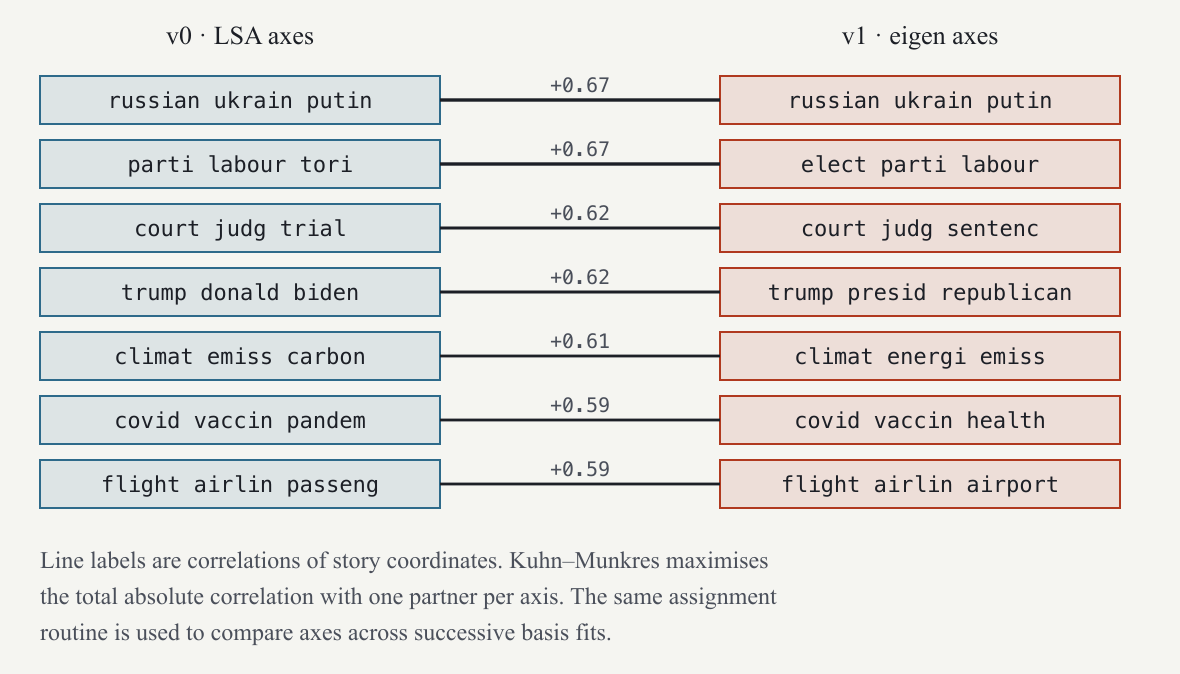

*Axes of the two bases paired by correlation of story coordinates.*

### Laboratory: Solve a global assignment, then compare score correlations

`similarity` is a synthetic 3 by 3 pairing table. A locally greedy first choice
loses to the globally optimal assignment. Python calls SciPy's assignment
routine; OCaml implements the Hungarian augmenting-path algorithm natively.
`story_scores_a` and `story_scores_b` are paired measurements of the same five
stories. Their correlation table supplies a comparable space even when the
underlying term and embedding basis directions have different dimensions.
The historical 0.67/0.62 figure labels are dated observations; these synthetic
scores do not re-estimate those unavailable 100,000-story measurements.

In [42]:
let hungarian similarity=
 let n=rows similarity in assert(n=cols similarity);
 let u=Array.make(n+1)0. and v=Array.make(n+1)0. and p=Array.make(n+1)0 and way=Array.make(n+1)0 in
 for i=1 to n do
  p.(0)<-i;let j0=ref 0 in let minv=Array.make(n+1)infinity and used=Array.make(n+1)false in
  let searching=ref true in while !searching do
   used.(!j0)<-true;let i0=p.(!j0) in let delta=ref infinity and j1=ref 0 in
   for j=1 to n do if not used.(j)then(
    let cur= -.similarity.(i0-1).(j-1)-.u.(i0)-.v.(j)in
    if cur<minv.(j)then(minv.(j)<-cur;way.(j)<- !j0);
    if minv.(j)< !delta then(delta:=minv.(j);j1:=j))done;
   for j=0 to n do if used.(j)then(u.(p.(j))<-u.(p.(j))+. !delta;v.(j)<-v.(j)-. !delta)else minv.(j)<-minv.(j)-. !delta done;
   j0:= !j1;if p.(!j0)=0 then searching:=false
  done;
  while !j0<>0 do let j1=way.(!j0)in p.(!j0)<-p.(j1);j0:=j1 done
 done;
 let assignment=Array.make n 0 in for j=1 to n do assignment.(p.(j)-1)<-j-1 done;assignment;;
let similarity=[|[|0.9;0.8;0.1|];[|0.85;0.2;0.1|];[|0.1;0.1;0.95|]|];;
let assignment=hungarian similarity;;
let optimal_total=Array.fold_left (+.)0.(Array.mapi(fun i j->similarity.(i).(j))assignment);;
assert_close optimal_total 2.6;;record_result "assignment_total" optimal_total;;
let story_scores_a=[|[|1.;0.|];[|2.;1.|];[|3.;-1.|];[|4.;1.|];[|5.;0.|]|];;
let story_scores_b=Array.map(fun row->[|-.row.(1);row.(0)|])story_scores_a;;
let ca=center story_scores_a(mean_rows story_scores_a) and cb=center story_scores_b(mean_rows story_scores_b);;
let correlations=Array.init 2(fun i->Array.init 2(fun j->cosine(col ca i)(col cb j)));;
record_result "cross_basis_matched_correlation" (abs_float correlations.(0).(1));;print_matrix "score correlations" correlations;;

val hungarian : float array array -> int array = <fun>


val similarity : float array array =
  [|[|0.9; 0.8; 0.1|]; [|0.85; 0.2; 0.1|]; [|0.1; 0.1; 0.95|]|]


val assignment : int array = [|1; 0; 2|]


val optimal_total : float = 2.59999999999999964


- : unit = ()


...

val story_scores_b : float array array =
  [|[|-0.; 1.|]; [|-1.; 2.|]; [|1.; 3.|]; [|-1.; 4.|]; [|-0.; 5.|]|]


val ca : float array array =
  [|[|-2.; -0.2|]; [|-1.; 0.8|]; [|0.; -1.2|]; [|1.; 0.8|]; [|2.; -0.2|]|]
val cb : float array array =
  [|[|0.2; -2.|]; [|-0.8; -1.|]; [|1.2; 0.|]; [|-0.8; 1.|]; [|0.2; 2.|]|]


val correlations : float array array =
  [|[|0.; 0.999999999999999778|]; [|-1.; 0.|]|]


- : string = "cross_basis_matched_correlation = 1"


- : string = "score correlations (2 x 2)\n : [0; 1]\n : [-1; 0]"


### Laboratory: Add the competing assignment totals

The greedy diagonal pairing in the displayed table totals 2.05; swapping the
first two pairings gives 2.60. Both use each row and column exactly once. The
Hungarian algorithm above verifies that the larger total is globally optimal
for this complete fixture, not merely better than the diagonal choice.

In [43]:
let greedy_total=similarity.(0).(0)+.similarity.(1).(1)+.similarity.(2).(2);;
let swapped_total=similarity.(0).(1)+.similarity.(1).(0)+.similarity.(2).(2);;
assert_close greedy_total 2.05;;assert_close swapped_total 2.6;;assert_close swapped_total optimal_total;;
record_result "assignment_greedy_total" greedy_total;;
record_result "assignment_improvement" (swapped_total-.greedy_total);;

val greedy_total : float = 2.05


val swapped_total : float = 2.59999999999999964


- : unit = ()


- : unit = ()


- : unit = ()


- : string = "assignment_greedy_total = 2.05"


- : string = "assignment_improvement = 0.55"


<a id="why-nightly-refinement-is-stable"></a>

## Why nightly refinement is stable

Why should yesterday's directions resemble today's at all? One reason is that adding a modest amount of data to a large fixed reference often changes its covariance only a little. A second condition is essential: the direction must be separated from competing directions. If two eigenvalues are equal, rotating their eigenvectors inside their common plane changes the axes without changing the covariance. Near equality can therefore make individual axes sensitive to small changes.

<a id="measure-the-change-and-the-separation-separately"></a>

### Measure the change and the separation separately

A *perturbation* is the difference between the new and old matrices. Let $E$ be this covariance change, with the same shape as each covariance. Its *spectral norm*, written $\lVert E\rVert_2$, is the greatest output length $E$ produces from any unit input. The subscript $2$ denotes the Euclidean-length operator norm; it does not mean that all matrix entries have been squared and summed. Define the scalar $\varepsilon=\lVert E\rVert_2$ as the size of the perturbation.

A *simple eigenvalue* has a one-dimensional eigenspace, so its unit eigenvector is determined up to sign. Consider a matched simple old eigenvalue and a new eigenvalue. Define the positive separation $g$ by comparing that new eigenvalue with every *other* old eigenvalue and taking the smallest distance. This precise comparison is part of the hypothesis. An arbitrary gap taken from a nearby pair of values cannot be substituted without further assumptions.

After matching the signs, let $\theta$ be the acute angle between the two unit eigenvectors. Its sine, $\sin\theta$, is the length of the component of one direction perpendicular to the other. It is zero when the lines agree and increases towards one as they become perpendicular. The Davis–Kahan bound in this setting is

$$\sin\theta\le\frac{\varepsilon}{g}.$$

The inequality gives an upper bound, not a prediction of the exact turn. A smaller covariance change lowers the bound; a smaller separation raises it. If the right-hand side exceeds one, the inequality gives no useful improvement over the fact that a sine is at most one.

The notebook starts with covariance diagonal entries $3$ and $1$, then adds $0.05$ to both off-diagonal entries. The perturbation norm is $0.05$ and the specified separation is slightly greater than $2$, so the bound is about $0.025$. The notebook calculates both the actual turning sine and the bound and checks the inequality. It also rotates a two-direction basis within a fixed plane: individual columns change while the projection onto the plane remains identical. This explains why nearly degenerate groups call for subspace comparisons.

<a id="what-a-growing-archive-does-and-does-not-guarantee"></a>

### What a growing archive does and does not guarantee

If the added day's total weight and observation lengths stay bounded while accumulated weight grows in proportion to an observation count $N$, the one-step covariance change can be $O(1/N)$. This *big-O notation* means bounded by a constant times $1/N$ under the stated assumptions. Larger accumulated weight then dilutes a bounded new contribution. The statement concerns an individual update. It does not prove that an evolving sequence of news bases converges forever, particularly when the data distribution or weighting policy changes.

Two continuity procedures address different remaining freedoms. *Procrustes alignment* rotates or reflects a matched group to minimize its total squared difference from the preceding group; it aligns coordinate frames without asserting that the underlying subspace never changed. *Warm-starting* begins the new varimax optimization at the preceding rotation instead of a fresh starting point. Both can aid continuity, but neither overrides a substantial data change or a vanishing eigengap.

### Laboratory: Check Davis–Kahan and align a rotated subspace

`old_cov` is a separated 2 by 2 covariance; `perturbation` changes its off-diagonal
entries. `epsilon` is the spectral norm of that change. `gap` is specifically the
distance from the new leading eigenvalue to the *other old eigenvalue*, matching
the theorem's stated hypothesis. We compare the actual sine of the angle with
the bound. Then Procrustes alignment undoes a synthetic rotation of a subspace;
the aligned projectors agree even if individual unaligned columns differ.

In [44]:
let old_cov=diag[|3.;1.|] and perturbation=[|[|0.;0.05|];[|0.05;0.|]|];;
let new_values,new_vectors=eig_sym(add old_cov perturbation);;
let perturb_values,_=eig_sym perturbation;;let epsilon=Array.fold_left(fun m x->max m(abs_float x))0. perturb_values;;
let gap=abs_float(new_values.(0)-.1.);;let sin_theta=sqrt(max 0.(1.-.new_vectors.(0).(0)**2.));;
assert(sin_theta<=epsilon/.gap+.1e-12);;
record_result "davis_kahan_sine" sin_theta;;record_result "davis_kahan_bound" (epsilon/.gap);;
let subspace=take_cols(eye 3)2;;let rotated_subspace=matmul subspace(rotation_matrix 0.6);;
let alignment=procrustes rotated_subspace subspace;;assert_matrix(matmul rotated_subspace alignment)subspace;;
assert_matrix(matmul rotated_subspace(transpose rotated_subspace))(matmul subspace(transpose subspace));;
print_matrix "Procrustes alignment" alignment;;

val old_cov : float array array = [|[|3.; 0.|]; [|0.; 1.|]|]
val perturbation : float array array = [|[|0.; 0.05|]; [|0.05; 0.|]|]


val new_values : float array = [|3.00124921972503911; 0.99875078027496067|]
val new_vectors : float array array =
  [|[|0.999688036058710705; -0.0249766002706065353|];
    [|0.0249766002706065353; 0.999688036058710705|]|]


val perturb_values : float array = [|0.05; -0.05|]


val epsilon : float = 0.05


val gap : float = 2.00124921972503911


...

val rotated_subspace : float array array =
  [|[|0.825335614909678328; -0.564642473395035371|];
    [|0.564642473395035371; 0.825335614909678328|]; [|0.; 0.|]|]


val alignment : float array array =
  [|[|0.825335614909678328; 0.564642473395035371|];
    [|-0.564642473395035371; 0.825335614909678328|]|]


- : unit = ()


- : unit = ()


- : string =
"Procrustes alignment (2 x 2)\n : [0.825336; 0.564642]\n : [-0.564642; 0.825336]"


<a id="streaming-the-computation"></a>

# Streaming the computation

The first edition of Eigen Times was fitted on 1.09 million articles, and its code could afford to hold what it needed: every article's embedding and coordinates while the axes were oriented, and the whole document–term matrix while the axes were named. The second edition ingested the *New York Times* archive back to 1851 and multiplied the corpus by fifteen, to 16.5 million articles. The first attempt to fit it was killed by the operating system at about forty gigabytes. What follows is the arithmetic that let the same computation run in a fraction of a gigabyte—not a bigger machine, but a change of shape. The principle is one sentence: *every quantity the fit needs is a sum over documents, and a sum can be taken in blocks.*

<a id="weights-that-balance-the-days"></a>

## Weights that balance the days

Before the sums, the weights. By article count the modern era dominates the archive—the Guardian alone publishes about as many articles a day as the *Times* index ever recorded—while by the calendar it is fifteen per cent of 175 years. Let $i$ index articles and $\tau$ a calendar day. Write $\tau(i)$ for article $i$'s day and $n_\tau>0$ for the number of eligible articles on that day. The second edition assigns article $i$ the inverse-count weight $w_i$. A sum constrained by $\tau(i)=\tau$ includes only articles from the chosen day:

$$w_i = 1 / n_{\tau(i)}, \qquad \sum_{\tau(i) = \tau} w_i = 1,$$

Every populated day therefore contributes one unit to the fit: a day in 1887 with 40 index entries and a day in 2024 with 900 articles count the same. The arithmetic is $40(1/40)=1$ and $900(1/900)=1$. An article from the smaller day has greater individual weight, while both days have equal total influence.

The notebooks make this distinction visible using a synthetic coordinate that is zero for each of the 40 first-day articles and one for each of the 900 second-day articles. Its article-weighted mean is $900/940\approx0.957$. Its day-balanced mean is $(1\times0+1\times1)/(1+1)=0.5$. Neither is an arithmetic error: they answer different questions about what counts as one unit of influence. Total weight $Z$ is the number of represented days, 63,270. The covariance formulas retain their shapes; the diagonal entries of $W$ change. For term-space fitting, let $\mu_{T,w}$ be the $p\times1$ TF‑IDF mean under these same article weights. Let $W^{1/2}$ be the diagonal matrix of the nonnegative square roots of the article weights. With $T$ of shape $N\times p$ and $\mathbf1$ of length $N$, the balanced LSA fit decomposes $W^{1/2}(T-\mathbf1\mu_{T,w}^{\top})$. Its mean is distinct from the unweighted naming mean $\mu_T$ below.

Why multiply centred rows by square-root weights? The covariance calculation subsequently multiplies a row by its transpose. The two factors each contribute $\sqrt{w_i}$, whose product is $w_i$. Using the full weight on both sides instead would produce $w_i^2$ and answer a different weighting question. Weighting, centering, and normalization each have a separate role; none can be omitted merely because the matrix shapes still match.

### Laboratory: Forty historical and nine hundred modern articles

We compute, rather than assume, that forty weights of 1/40 and nine hundred
weights of 1/900 give one unit per populated day. For a two-day synthetic vector
fixture the daily-weighted mean differs from the unweighted article mean.
`weighted_terms` multiplies centered rows by square-root weights, preparing the
weighted LSA operator.

In [45]:
let day_ids=Array.init 940(fun i->if i<40 then 0 else 1);;
let day_weights=Array.map(fun day->if day=0 then 1./.40. else 1./.900.)day_ids;;
for day=0 to 1 do assert_close(Array.fold_left (+.)0.(Array.mapi(fun i w->if day_ids.(i)=day then w else 0.)day_weights))1. done;;
let two_day_rows=Array.map(fun day->[|float_of_int day;1.|])day_ids;;
let daily_mean,daily_cov=covariance two_day_rows day_weights;;
let weighted_terms=Array.mapi(fun i row->Array.map(( *.) (sqrt day_weights.(i)))row)(center two_day_rows daily_mean);;
assert_matrix(scale(1./.Array.fold_left (+.)0. day_weights)(matmul(transpose weighted_terms)weighted_terms))daily_cov;;
record_result "day_balanced_mean" daily_mean.(0);;print_vector "article mean" (mean_rows two_day_rows);;

val day_ids : int array =
  [|0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0;
    0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1; 1; 1; 1; 1; 1; 1; 1;
    1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;
    1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;
    1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;
    1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;
    1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;
    1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;
    1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;
    1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;
    1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;
    1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;
    1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1

val day_weights : float array =
  [|0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025;
    0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025;
    0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025;
    0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025; 0.025;
    0.00111111111111111111; 0.00111111111111111111; 0.00111111111111111111;
    0.00111111111111111111; 0.00111111111111111111; 0.00111111111111111111;
    0.00111111111111111111; 0.00111111111111111111; 0.00111111111111111111;
    0.00111111111111111111; 0.00111111111111111111; 0.00111111111111111111;
    0.00111111111111111111; 0.00111111111111111111; 0.00111111111111111111;
    0.00111111111111111111; 0.00111111111111111111; 0.00111111111111111111;
    0.00111111111111111111; 0.00111111111111111111; 0.00111111111111111111;
    0.00111111111111111111; 0.00111111111111111111; 0.00111111111111111111;
    0.00111111111111111111; 0.00111111111111111111; 0.0011111111

- : unit = ()


val two_day_rows : float array array =
  [|[|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|];
    [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|];
    [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|];
    [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|];
    [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|];
    [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|];
    [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|0.; 1.|]; [|1.; 1.|]; [|1.; 1.|];
    [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|];
    [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|];
    [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|];
    [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|];
    [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|];
    [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|]; [|1.; 1.|

val daily_mean : float array = [|0.500000000000000888; 1.|]
val daily_cov : float array array =
  [|[|0.250000000000000444; 0.|]; [|0.; 0.|]|]


val weighted_terms : float array array =
  [|[|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-0.0790569415042096241; 0.|]; [|-0.0790569415042096241; 0.|];
    [|-

- : unit = ()


- : string = "day_balanced_mean = 0.5"


- : string = "article mean: [0.957447; 1]"


### Laboratory: Distinguish an article average from a day average

The synthetic first coordinate is zero on the forty-article day and one on the
nine-hundred-article day. Equal article weights give 900/940; inverse daily counts
give one total weight per day and a mean of one half. The data are unchanged;
the units of influence differ.

In [46]:
let article_average=(mean_rows two_day_rows).(0);;
assert_close article_average(900./.940.);;assert_close daily_mean.(0)0.5;;
record_result "unbalanced_article_mean" article_average;;

val article_average : float = 0.957446808510638347


- : unit = ()


- : unit = ()


- : string = "unbalanced_article_mean = 0.957446808511"


<a id="sums-over-blocks"></a>

## Sums over blocks

Split the article rows into disjoint blocks indexed by $b=1,2,\ldots$. In Eigen Times, a block is one source's articles for one month; there are about three thousand. The notation $i\in b$ means article row $i$ belongs to block $b$. Let $g$ be any fixed rule converting a row $x_i$ into a scalar, vector, or matrix contribution of the same shape for every row. Then

$$\sum_i g(x_i)=\sum_b\sum_{i\in b}g(x_i).$$

Read the inner sum first: calculate the contributions from articles in one block and add them. The outer sum adds the resulting block totals. Every article must appear in exactly one block; missing or duplicated rows would change the answer. Once a block's contribution has been added, its article rows can be discarded from memory. Here the function $g$ is unrelated to the eigengap scalar in §10.

For covariance the contributions are already known: an article adds its weight to $Z$, its weighted coordinate column to $m$, and its weighted outer-product matrix to $M$. Each block produces a scalar, a $d\times1$ column, and a $d\times d$ matrix. Add like-shaped block summaries, then compute the mean $m/Z$ and covariance $M/Z-(m/Z)(m/Z)^{\top}$. Do not average block means equally unless their total weights are equal; a block with more weight must contribute proportionally more.

A *thread* is a worker executing part of the computation; an *accumulator* stores its partial total. Workers can merge partial sums because addition commutes in exact arithmetic. Floating-point arithmetic can introduce small order-dependent rounding differences. Memory is bounded by the largest block plus these accumulators. The covariance's $Z,m,M$ are *sufficient summaries* for reconstructing that mean and covariance; the phrase does not claim they retain all information about the articles. Two other stages needed the same treatment.

### Laboratory: Merge covariance sufficient summaries

Each block contributes total weight, weighted coordinate sum and weighted outer
product sum. Two partitions of the earlier seven-row covariance example give
the same mean and covariance as its batch calculation. These summaries preserve
those statistics, not all information about the documents.

In [47]:
let summaries=Array.map(fun(start,length)->
 let xb=Array.sub covariance_rows start length and wb=Array.sub weights start length in
 let z=Array.fold_left (+.)0. wb in let m=matvec(transpose xb)wb in
 let second=matmul(transpose xb)(Array.mapi(fun i row->Array.map(( *.)wb.(i))row)xb)in z,m,second)[|(0,3);(3,4)|];;
let merged_z=Array.fold_left(fun z(a,_,_)->z+.a)0. summaries;;
let merged_m=Array.fold_left(fun sum(_,m,_)->Array.mapi(fun i x->x+.m.(i))sum)(Array.make 3 0.)summaries;;
let merged_M=Array.fold_left(fun sum(_,_,m)->add sum m)(zeros 3 3)summaries;;
let merged_mu=Array.map(fun x->x/.merged_z)merged_m;;
let merged_cov=sub(scale(1./.merged_z)merged_M)(outer merged_mu merged_mu);;
assert_matrix merged_cov cov;;record_result "streaming_covariance_error" (frob(sub merged_cov cov));;

val summaries : (float * float array * float array array) array =
  [|(4.,
     [|-2.86422519734858172; -3.34127895109740347; 0.128185166941222617|],
     [|[|10.6307792121242564; 6.09894863330933124; 0.688542603226938388|];
       [|6.09894863330933124; 4.52101740467236368; 0.250150546425768394|];
       [|0.688542603226938388; 0.250150546425768394; 0.0782235888579228|]|]);
    (7.,
     [|6.80203466994510908; 7.94588692557495513; -0.0843311407852886247|],
     [|[|27.1391076711353563; 24.6132679258926501; 0.100085236665307775|];
       [|24.6132679258926501; 23.2746675314845675; 0.142551783630941287|];
       [|0.100085236665307775; 0.142551783630941287; 0.060438482966051546|]|])|]


val merged_z : float = 11.


val merged_m : float array =
  [|3.93780947259652736; 4.60460797447755166; 0.0438540261559339922|]


val merged_M : float array array =
  [|[|37.7698868832596162; 30.7122165592019805; 0.788627839892246163|];
    [|30.7122165592019805; 27.7956849361569311; 0.392702330056709681|];
    [|0.788627839892246163; 0.392702330056709681; 0.138662071823974331|]|]


val merged_mu : float array =
  [|0.357982679326957043; 0.418600724952504721; 0.00398672965053945352|]


val merged_cov : float array array =
  [|[|3.30547448159822199; 2.64216787811347587; 0.0702662598281518641|];
    [|2.64216787811347587; 2.35165388181077661; 0.0340313639014317854|];
    [|0.0702662598281518641; 0.0340313639014317854; 0.0125897488797820853|]|]


- : unit = ()


- : string = "streaming_covariance_error = 7.6943737508e-16"


<a id="orienting-an-axis-from-power-sums"></a>

## Orienting an axis from power sums

Fix one raw axis $j$ and let $c_{ij}$ be article $i$'s score on it. Let $n>0$ count the articles in this orientation pass and let $\bar c_j$ be their unweighted mean score; an overbar denotes a mean. A *central moment* averages powers of deviations from a mean. The second central moment uses squares and measures spread; the third uses cubes and retains a sign. Cubes of negative deviations are negative, so a long negative tail can outweigh shorter positive deviations. Define the third central moment $m_3$ by

$$m_3=n^{-1}\sum_i(c_{ij}-\bar c_j)^3,$$

where $n^{-1}=1/n$. The orientation rule flips the axis when $m_3$ is negative. Flipping all scores reverses their centred cubes' signs while preserving squared lengths. If the third moment is zero, this particular rule supplies no preference between the two signs. The old pass retained 16.5 million scores for each axis. Instead define three *power sums*, sums of first, second, and third powers:

$$n, \qquad S_1 = \sum_i c_{ij}, \qquad S_2 = \sum_i c_{ij}^2, \qquad S_3 = \sum_i c_{ij}^3,$$

These scalar $S_1,S_2,S_3$ are distinct from the naming-score matrix $S$. For this one axis, abbreviate $\bar c_j$ as $\bar c=S_1/n$. To see why these summaries suffice, first expand one squared deviation:

$$(c_{ij}-\bar c)^2=c_{ij}^2-2\bar c\,c_{ij}+\bar c^2.$$

Averaging the first term gives $S_2/n$. In the second, $\bar c$ is constant over articles and the average score is itself $\bar c$, so the average is $-2\bar c^2$. The last term averages to $\bar c^2$. Adding them gives the second central moment, denoted $m_2$:

$$m_2=S_2/n-\bar c^2.$$

The cube has four terms:

$$(c_{ij}-\bar c)^3=c_{ij}^3-3\bar c\,c_{ij}^2
+3\bar c^2c_{ij}-\bar c^3.$$

Average each term in order. They become $S_3/n$, $-3\bar c S_2/n$, $3\bar c^3$, and $-\bar c^3$. Combining the last two gives

$$m_3=S_3/n-3\bar c\,S_2/n+2\bar c^3.$$

The notebook reuses the synthetic orientation scores $-5,-1,0,1,1$. They give $n=5$, $S_1=-4$, $S_2=28$, and $S_3=-124$, hence $\bar c=-0.8$. Substitution gives

$$m_2=28/5-(-0.8)^2=5.6-0.64=4.96,$$

$$\begin{aligned}
m_3&=-124/5-3(-0.8)(28/5)+2(-0.8)^3\\
&=-24.8+13.44-1.024\\
&=-12.384.
\end{aligned}$$

The negative third moment triggers a sign flip. The two notebooks verify these values both from the original centred scores and from independently accumulated blocks.

Four numbers per axis—$n$ and three sums—replace the column. Each partition adds its documents' powers to an accumulator; accumulators merge by adding those four numbers. These polynomial identities are exact, but subtracting nearly equal floating-point values can lose precision when the mean is large compared with the spread. The reported tests compare streaming and batch orientation signs, including merged partial accumulators; they do not make that numerical risk disappear for arbitrary data.

### Laboratory: Recover moments from four mergeable numbers

The same signed-score fixture now passes through two blocks. Each produces the
count and sums of first, second and third powers. Their merged polynomial
formula must equal direct centered moments. These equalities concern arithmetic;
a huge offset can still cause cancellation in floating-point power sums.

In [48]:
let power_summary block=[|float_of_int(Array.length block);Array.fold_left (+.)0. block;Array.fold_left(fun s x->s+.x*.x)0. block;Array.fold_left(fun s x->s+.x**3.)0. block|];;
let powers=Array.fold_left(fun sum part->Array.mapi(fun i x->x+.part.(i))sum)(Array.make 4 0.)(Array.map power_summary[|Array.sub signed_scores 0 3;Array.sub signed_scores 3 2|]);;
let score_average=powers.(1)/.powers.(0);;
let power_m2=powers.(2)/.powers.(0)-.score_average**2.;;
let power_m3=powers.(3)/.powers.(0)-.3.*.score_average*.powers.(2)/.powers.(0)+.2.*.score_average**3.;;
assert_close power_m2 m2;;assert_close power_m3 m3;;record_result "power_sum_third_moment" power_m3;;

val power_summary : float array -> float array = <fun>


val powers : float array = [|5.; -4.; 28.; -124.|]


val score_average : float = -0.8


val power_m2 : float = 4.95999999999999908


val power_m3 : float = -12.3839999999999986


- : unit = ()


- : unit = ()


- : string = "power_sum_third_moment = -12.384"


### Laboratory: Expand the second and third moments term by term

For the reused scores -5, -1, 0, 1, 1, inspect the four summaries and each term
of the expanded central moment. Keeping the signs visible explains why a
negative third moment changes under a sign flip while variance does not.

In [49]:
Array.iteri(fun i value->assert_close value [|5.;-4.;28.;-124.|].(i))powers;;
let second_terms=[|powers.(2)/.powers.(0);-.(score_average**2.)|];;
let third_terms=[|powers.(3)/.powers.(0);-.3.*.score_average*.powers.(2)/.powers.(0);2.*.score_average**3.|];;
Array.iteri(fun i value->assert_close value [|5.6;-0.64|].(i))second_terms;;
Array.iteri(fun i value->assert_close value [|-24.8;13.44;-1.024|].(i))third_terms;;
assert_close(Array.fold_left (+.)0. second_terms)4.96;;
assert_close(Array.fold_left (+.)0. third_terms)(-12.384);;
record_result "orientation_score_mean" score_average;;
record_result "orientation_second_moment" (Array.fold_left (+.)0. second_terms);;
for i=1 to 3 do ignore(record_result(Printf.sprintf "orientation_power_sum_%d" i)powers.(i))done;;
print_vector "third central-moment terms" third_terms;;

- : unit = ()


val second_terms : float array = [|5.6; -0.640000000000000124|]


val third_terms : float array =
  [|-24.8; 13.4400000000000031; -1.02400000000000024|]


- : unit = ()


- : unit = ()


...

- : unit = ()


- : string = "orientation_score_mean = -0.8"


- : string = "orientation_second_moment = 4.96"


- : unit = ()


- : string = "third central-moment terms: [-24.8; 13.44; -1.024]"


<a id="term-loadings-block-by-block"></a>

## Term loadings block by block

Recall that $T$ has $N$ article rows and $p$ TF‑IDF columns, $\mu_T$ is their unweighted $p\times1$ mean, and $S$ has the matching $N$ rows of $k$ whitened raw scores. Its row order must agree with $T$. A *cross-product* multiplies one table's transposed columns against another table's columns. Here it measures which terms co-occur with large axis scores. It is a numerical association, not evidence that a term causes a story or uniquely owns an axis.

Let $t=1,\ldots,p$ index vocabulary terms in this subsection and $j=1,\ldots,k$ index raw score axes. Write $\mu_{T,t}$ for entry $t$ of the mean column $\mu_T$. Article $i$ contributes its centred term value, $T_{it}-\mu_{T,t}$, multiplied by its score $S_{ij}$. Add over articles to obtain entry $(t,j)$ of the $p\times k$ term-loading matrix $\beta$:

$$\beta_{tj}=\sum_i\bigl(T_{it}-\mu_{T,t}\bigr)S_{ij}.$$

The mean term value is constant over articles. Distributing multiplication over subtraction therefore yields the same entry as

$$\beta_{tj}=\sum_iT_{it}S_{ij}-\mu_{T,t}\sum_i S_{ij}.$$

In matrix form, with $\mathbf1$ the $N\times1$ column of ones, these are the raw term–score product and its centering correction:

$$\beta=T^{\top}S-\mu_T(\mathbf1^{\top}S).$$

Check the correction's shape: $\mathbf1^{\top}S$ is a $1\times k$ row of score sums; multiplying the $p\times1$ term-mean column by it gives a $p\times k$ outer product. A fitted score mean can be zero under one weighting convention but not another. Keeping the centering term explicit avoids assuming a cancellation the naming pass does not guarantee.

Let $N_b$ count articles in block $b$, and let $T_b$ and $S_b$ contain its matching rows, with shapes $N_b\times p$ and $N_b\times k$. Write $\mathbf1_b$ for the $N_b\times1$ column of ones, while $\mathbf1$ without a subscript has length $N$. Then

$$T^{\top}S=\sum_b T_b^{\top}S_b,\qquad \mathbf1^{\top}S=\sum_b\mathbf1_b^{\top}S_b,$$
$$\mu_T=N^{-1}\sum_b T_b^{\top}\mathbf1_b.$$

Read these formulas as three accumulation tasks. First multiply matching term and score rows to update the cross-product. Second add term columns to update their sums. Third add score columns to update their sums. Also retain the total row count so the final term sums can be divided by $N$. The final mean and centering correction are computed after the block summaries have been combined, using the same unweighted naming convention as the full matrix.

Each block therefore contributes three small numerical arrays: a $p \times k$ matrix ($50{,}000 \times 60$, twenty-four megabytes), the column sums of its term rows ($p$ numbers) and the column sums of its scores ($k$ numbers). The block itself—the sparse rows of one month's articles and their scores—is built, folded in, and dropped (Figure 18). The full $T$, which has 455 million non-zero entries for the 175-year corpus and was being held *twice* by the batch code, never exists in the naming pass. At the end the three accumulated pieces are combined by the formula above; a property test checks that the result equals the whole-matrix operator applied to the concatenated blocks, to $10^{-12}$.

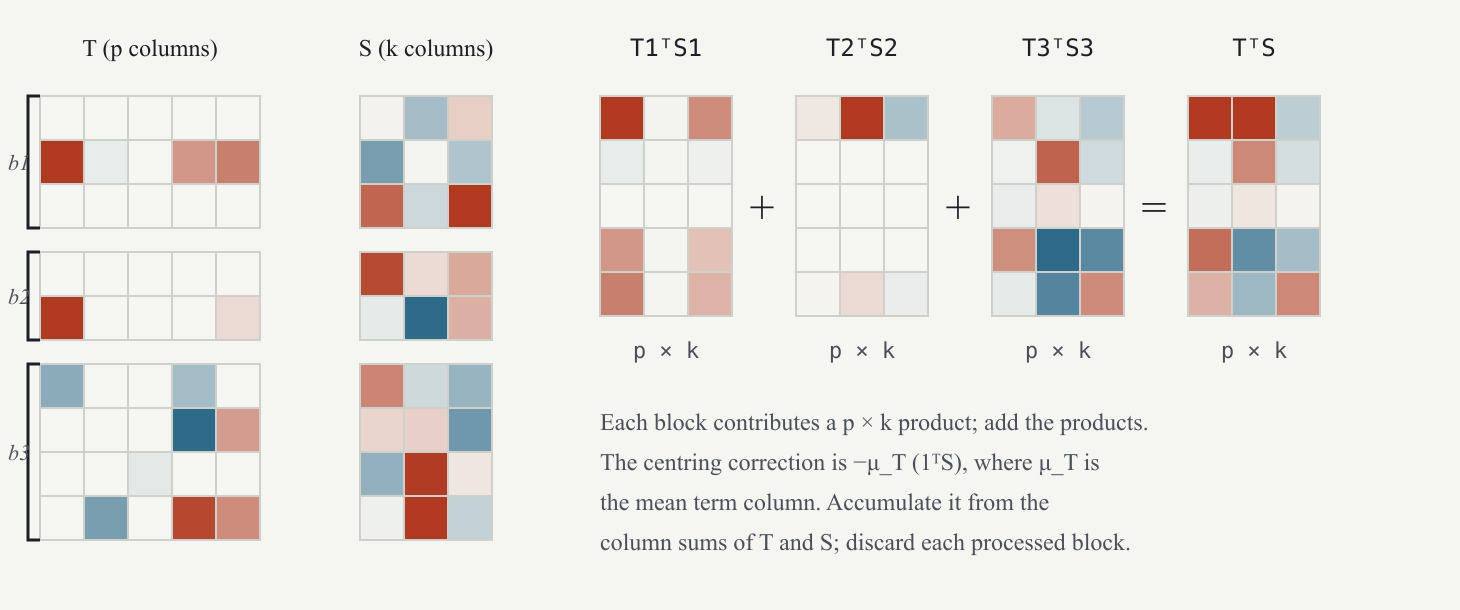

*Term loadings block by block: each block of documents contributes one small $p \times k$ matrix, and the sum is the whole.*

The same pass over a block also projects its embeddings to coordinates and computes $T^2$, $Q$ and $\nu$ for its documents, writing them to the partition's own table. The whole eigen fit is thus three passes over the archive—covariance, orientation, measurement—each of which reads one partition at a time. On 16.5 million articles it runs in ten minutes and stays at 0.3 GB of memory.

### Laboratory: Recompute Figure 18 and its centering correction

The three term and score blocks are the exact raw synthetic inputs generated by
Figure 18's seed-7 recipe. Each partial product has shape 5 by 3. `raw_cross` is
their sum. `centered_cross` additionally subtracts the outer product of the term
mean and score sums. We verify equality with concatenating all rows and directly
centering, to the manuscript's 10⁻¹² comparison scale.

In [50]:
let raw_cross=Array.fold_left add(zeros 5 3)(Array.mapi(fun b t->matmul(transpose t)score_blocks.(b))term_blocks);;
let all_terms=Array.concat(Array.to_list term_blocks) and all_scores=Array.concat(Array.to_list score_blocks);;
let term_total=Array.map(Array.fold_left (+.)0.)(transpose all_terms) and score_total=Array.map(Array.fold_left (+.)0.)(transpose all_scores);;
let centered_cross=sub raw_cross(outer(Array.map(fun x->x/.float_of_int(rows all_terms))term_total)score_total);;
let batch_cross=matmul(transpose(center all_terms(mean_rows all_terms)))all_scores;;
assert_matrix ~tol:1e-12 centered_cross batch_cross;;
print_matrix "centered term loadings" centered_cross;;record_result "streaming_loadings_norm" (frob centered_cross);;
record_result "streaming_loadings_error" (frob(sub centered_cross batch_cross));;

val raw_cross : float array array =
  [|[|-1.65142285843764891; -1.65079320504168114; 0.468940377064802794|];
    [|0.094993214320728; -0.94805743101442852; 0.268620712717363375|];
    [|0.0661678189494801783; -0.131554280870557067; -0.0100772806190044927|];
    [|-1.17815245508069832; 1.22051628675294155; 0.663775591658849362|];
    [|-0.579992519286310348; 0.729684105797636873; -0.950175866129397084|]|]


val all_terms : float array array =
  [|[|0.; 0.; -0.; -0.; -0.|];
    [|-0.99164655499646237; 0.060143602597438485; 0.; -0.49220651855132963;
      -0.620474899819940418|];
    [|0.; 0.; 0.; -0.; -0.|]; [|-0.; -0.; -0.; -0.; 0.|];
    [|-0.80753467533189649; -0.; 0.; -0.; -0.111701949584159632|];
    [|0.762259712084711771; -0.; 0.; 0.576689583670185302; -0.|];
    [|0.; -0.; 0.; 1.43852259165615193; -0.675662251005652803|];
    [|0.; -0.; 0.127268411225830824; -0.; -0.|];
    [|-0.; 0.898763872100407757; 0.; -1.32352779248425501;
      -0.794642365987049515|]|]
val all_scores : float array array =
  [|[|-0.0241436130099322334; 0.668381023267343832; -0.33986955171314942|];
    [|1.05212635842694691; -0.00539956067162660532; 0.583382354180413842|];
    [|-1.29089324532348715; 0.346680048878429736; -1.68820411736654163|];
    [|-2.03532894493993233; -0.304476877711437222; -0.899927607598595247|];
    [|0.16405279571222256; 2.24475662648604946; -0.83172318141208168|];
    [|-0.6239435864

val term_total : float array =
  [|-1.03692151824364709; 0.958907474697846207; 0.127268411225830824;
    0.199477864290752649; -2.20248146639680265|]
val score_total : float array =
  [|-2.37934181578847381; 0.861254421937443; -1.80020807531853189|]


val centered_cross : float array array =
  [|[|-1.92555516155409112; -1.5515650669539669; 0.261532100329939898|];
    [|0.348500842323029469; -1.03982002021580477; 0.460424377098959337|];
    [|0.0998139359115449; -0.143733223308468133; 0.0153793440056288772|];
    [|-1.1254162302105688; 1.20142726534193622; 0.703675776341461279|];
    [|-1.16226543611931366; 0.940450428260915738; -1.39072307963461106|]|]


val batch_cross : float array array =
  [|[|-1.9255551615540909; -1.55156506695396712; 0.26153210032994|];
    [|0.348500842323029469; -1.03982002021580477; 0.460424377098959337|];
    [|0.0998139359115449; -0.143733223308468133; 0.015379344005628879|];
    [|-1.1254162302105688; 1.201427265341936; 0.703675776341461501|];
    [|-1.16226543611931366; 0.940450428260915627; -1.39072307963461128|]|]


- : unit = ()


- : string =
"centered term loadings (5 x 3)\n : [-1.92556; -1.55157; 0.261532]\n : [0.348501; -1.03982; 0.460424]\n : [0.0998139; -0.143733; 0.0153793]\n : [-1.12542; 1.20143; 0.703676]\n : [-1.16227; 0.94045; -1.39072]"


- : string = "streaming_loadings_norm = 3.87344949371"


- : string = "streaming_loadings_error = 5.20743646563e-16"


<a id="stories-one-month-at-a-time"></a>

## Stories one month at a time

Clustering into stories (chapter *The clustering thresholds*) is done within a day, and threading into episodes links a day's stories to the previous day's. For the clustering and episode-linking calculation, the dependency of day $\tau$ is on that day's articles and the previous day's story state. The carried state includes centroids and episode identities, which summarize the thread inherited from earlier days. It is not necessary to reload every earlier article. Other tasks, such as finding long-range precedents, have broader dependencies and are not covered by this particular memory reduction. The batch code loaded every article's vector and title before starting; the streaming version walks the months in order, loads one month's articles, clusters its days in sequence, carries the last day's stories across the month boundary, writes the month's stories and drops the month. Memory is one month of articles instead of 175 years of them. The month boundary is only a storage boundary: preserve the previous day's state when crossing it, or an ongoing episode would be split accidentally. The notebook processes the same six synthetic days once as a full batch and once as two blocks, checking that the resulting episode identities agree.

### Laboratory: Carry episode state across a block boundary

Six synthetic daily story centroids rotate slightly, then jump to another
region. A function threads them with the 0.9 rule while retaining only the
previous centroid and current episode ID. Processing all six days or processing
two artificial month blocks must give identical episode IDs.

In [51]:
let daily_centroids=Array.map(fun angle->[|cos angle;sin angle|])[|0.;0.05;0.1;1.5;1.55;1.6|];;
let thread_days days(previous,episode)=
 let previous=ref previous and episode=ref episode in
 let ids=Array.map(fun current->(match !previous with None->incr episode|Some old->if cosine old current<0.9 then incr episode);previous:=Some current;!episode)days in
 ids,(!previous,!episode);;
let batch_ids,_=thread_days daily_centroids(None,-1);;
let first_ids,carry=thread_days(Array.sub daily_centroids 0 3)(None,-1);;
let second_ids,_=thread_days(Array.sub daily_centroids 3 3)carry;;
assert(batch_ids=Array.append first_ids second_ids);;assert(batch_ids=[|0;0;0;1;1;1|]);;
record_result "streamed_episode_count" (float_of_int(List.length(List.sort_uniq compare(Array.to_list batch_ids))));;batch_ids;;

val daily_centroids : float array array =
  [|[|1.; 0.|]; [|0.998750260394966283; 0.0499791692706783308|];
    [|0.995004165278025821; 0.0998334166468281548|];
    [|0.0707372016677029; 0.997494986604054446|];
    [|0.0207948278030924277; 0.999783764189357|];
    [|-0.0291995223012888154; 0.99957360304150511|]|]


val thread_days :
  float array array ->
  float array option * int -> int array * (float array option * int) = <fun>


val batch_ids : int array = [|0; 0; 0; 1; 1; 1|]


val first_ids : int array = [|0; 0; 0|]
val carry : float array option * int =
  (Some [|0.995004165278025821; 0.0998334166468281548|], 0)


val second_ids : int array = [|1; 1; 1|]


- : unit = ()


- : unit = ()


- : string = "streamed_episode_count = 2"


- : int array = [|0; 0; 0; 1; 1; 1|]


<a id="what-still-has-to-fit-in-memory"></a>

## What still has to fit in memory

A matrix's *shape* tells us how many numerical entries it contains. A dense $p\times k$ accumulator has $pk$ entries. With eight-byte floating-point values, the $50{,}000\times60$ loading accumulator needs $50{,}000\times60\times8=24{,}000{,}000$ bytes, or 24 decimal megabytes. Each simultaneous worker needs its own accumulator unless the implementation arranges shared updates. A decimal megabyte is one million bytes; a gibibyte uses $2^{30}$ bytes, so unit labels matter when comparing reported memory.

This size calculation concerns numerical entries only. Sparse indices, object metadata, temporary arrays, and stored text consume additional memory. A measured process total cannot generally be obtained by multiplying a single matrix shape.

Two stages remain large. Randomized LSA uses a $p\times l$ working matrix $\Omega$, where $l$ is the chosen working width, normally larger than the final retained rank. Products such as $T\Omega$ and $T^{\top}(T\Omega)$ are the range-finding operations described in §5, with the required centering and weighting corrections. The first product can be emitted by row block; the second is a sum of block cross-products. This avoids requiring all of $T$ at once, although working score matrices also need a storage plan. In the reported edition the 455-million-nonzero matrix remains in memory: 31 GB on a 64 GB laptop. The block form is a next step, not a claimed implementation. The other large object is the site index, which retains story centroids and profiles for precedents: about 20 GB for 13.4 million stories. These retained objects determine the second edition's build-machine requirement.

| pass | before | after |
|---|---|---|
| eigen: orientation | every vector and coordinate (≈30 GB) | four power sums per axis |
| eigen: term loadings | $T$ twice, plus $S$ (≈20 GB) | one $p \times k$ accumulator per thread (24 MB) |
| stories | every vector and title (≈25 GB) | one month at a time |
| LSA: randomized SVD | $T$ in memory (31 GB) | unchanged |
| site index | every story (20 GB) | unchanged |

### Laboratory: Calculate storage costs, without allocating the archive

Float64 entries occupy eight bytes; a decimal megabyte is one million bytes and
a gibibyte is 2³⁰ bytes. We calculate the 50,000 by 60 accumulator's 24 MB cost
and compare hypothetical dense archive tables. These are arithmetic estimates;
the reported 31 GB sparse LSA and 20 GB site index include implementation-specific
objects and cannot be inferred by multiplying a single shape alone.

In [52]:
let accumulator_bytes=50000.*.60.*.8. and dense_term_bytes=16500781.*.50000.*.8.;;
assert_close accumulator_bytes 24000000.;;record_result "loading_accumulator_megabytes" (accumulator_bytes/.1e6);;
Printf.sprintf "Hypothetical dense term table: %.1f GiB" (dense_term_bytes/.2.**30.);;

val accumulator_bytes : float = 24000000.
val dense_term_bytes : float = 6.6003124e+12


- : unit = ()


- : string = "loading_accumulator_megabytes = 24"


- : string = "Hypothetical dense term table: 6147.0 GiB"


<a id="the-pipeline-as-matrices"></a>

# The pipeline as matrices

Figure 19 brings the stages together. Shapes are a useful final check because they force us to say what each row and column represents. They can detect incompatible operations, although matching shapes alone do not prove that row identities, units, weights, or meanings agree.

Here $N$ counts articles and $E$ is their $N\times384$ embedding matrix. This use of $E$ names embeddings, distinct from the local covariance-perturbation symbol in the stability section. Each row is an article; each column is an embedding coordinate. Let $\mathbf1$ be the $N\times1$ column of ones and $\mu$ the $384\times1$ embedding mean. The product $\mathbf1\mu^{\top}$ repeats that mean in every article row. Subtracting it centres all rows at once.

The retained basis $V$ has 384 rows and 60 columns. Define the raw coordinate table $C$ by

$$C=(E-\mathbf1\mu^{\top})V.$$

The multiplication has shape $(N\times384)(384\times60)$, producing $N\times60$. Each article receives 60 coordinates. To reconstruct the retained part in the original embedding coordinates, multiply by $V^{\top}$, giving shape $(N\times60)(60\times384)=N\times384$, then add the repeated mean. The difference from $E$ gives one residual row per article.

The term-space mean remains $\mu_T$. The table $S$ denotes the standardized raw score rows used for lexical naming; it has the same article ordering as the term matrix. Its cross-product with centred terms has shape $(50{,}000\times N)(N\times60)=50{,}000\times60$. The $60\times60$ rotation changes the coordinates within the retained space without increasing their number. The subscript "lsa" below identifies a basis fitted in term space.

The numerical decompositions are consequently small—a $384\times384$ covariance, a $384\times60$ basis, a $50{,}000\times60$ loading table, and a $60\times60$ rotation—even though some article and story tables remain large. The preceding chapter identifies the objects that still determine memory requirements; small final matrices do not imply that every intermediate calculation is small.

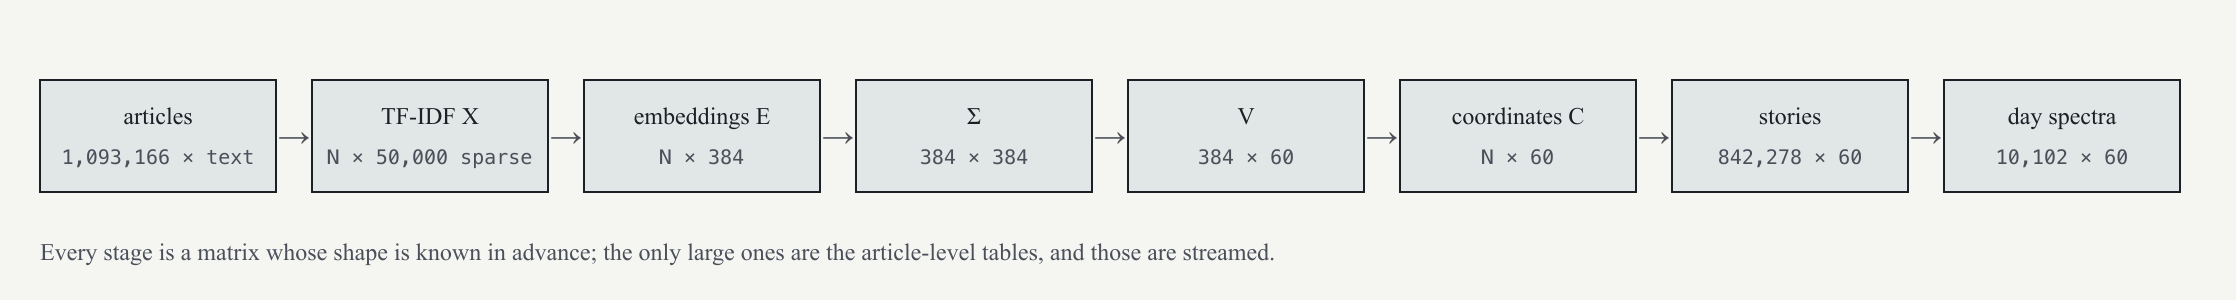

*The pipeline, stage by stage, as matrices.*

| stage | object | shape | operation |
|---|---|---|---|
| tokenise | TF‑IDF matrix $T$ | $N \times 50{,}000$, sparse | randomized SVD → $V_{\text{lsa}}$, $U$ |
| embed | $E$ | $N \times 384$ | streaming $Z, m, M$ |
| covariance | $\Sigma$ | $384 \times 384$ | `eigh` → $V, \Lambda$ |
| name | centred term–score product $\beta$ | $50{,}000 \times 60$ | varimax → $R$ |
| measure | $C = (E - \mathbf{1}\mu^{\top})V$ | $N \times 60$ | $T^2$, $Q$, $\nu$ per row |
| stories | centroids | $842{,}278 \times 60$ | profiles, precedents |
| days | spectra | $10{,}102 \times 60$ | era statistics, z‑scores |

The numbers in the table are those of the first edition on 28 August 2026; each grows by a day's worth every night. The second edition, fitted on 3 September 2026 over the *New York Times* archive as well, has $N = 16{,}500{,}781$ articles (455 million non-zeros in $T$), 13,421,090 stories and 63,270 day spectra; the small matrices—$\Sigma$, $V$, $\beta$, $R$—have exactly the same shapes, which is the point of the chapter *Streaming the computation*.

### Laboratory: Check shape contracts and dated totals

We build a complete tiny shape-compatible chain using six documents, seven
terms, three embedding coordinates and two retained axes. `toy_embeddings` are
explicit synthetic measurements, not neural embeddings. The shape checks show
how covariance, coordinates, whitened lexical naming and a rotation fit together.
The production counts in the prose retain their original 2026 edition dates.

In [53]:
let toy_embeddings=[|[|1.;0.;0.|];[|2.;1.;0.|];[|3.;-1.;1.|];[|0.;2.;1.|];[|1.;3.;-1.|];[|2.;1.;2.|]|];;
let toy_mu,toy_cov=covariance toy_embeddings(Array.make 6 1.);;
let toy_values_all,toy_vectors=eig_sym toy_cov;;let toy_values=Array.sub toy_values_all 0 2 and toy_basis=take_cols toy_vectors 2;;
let toy_coords=matmul(center toy_embeddings toy_mu)toy_basis;;
let toy_whitened=Array.map(fun row->Array.mapi(fun j x->x/.sqrt toy_values.(j))row)toy_coords;;
let toy_beta=matmul(transpose(center tfidf(mean_rows tfidf)))toy_whitened;;
assert(rows toy_cov=3 && cols toy_cov=3 && rows toy_basis=3 && cols toy_basis=2 && rows toy_coords=6 && cols toy_coords=2 && rows toy_beta=7 && cols toy_beta=2);;
assert_matrix(scale(1./.6.)(matmul(transpose toy_whitened)toy_whitened))(eye 2);;
record_result "pipeline_coordinate_energy" ((frob toy_coords)**2.);;print_matrix "toy lexical associations" toy_beta;;

val toy_embeddings : float array array =
  [|[|1.; 0.; 0.|]; [|2.; 1.; 0.|]; [|3.; -1.; 1.|]; [|0.; 2.; 1.|];
    [|1.; 3.; -1.|]; [|2.; 1.; 2.|]|]


val toy_mu : float array = [|1.5; 1.; 0.5|]
val toy_cov : float array array =
  [|[|0.91666666666666663; -0.833333333333333259; 0.25|];
    [|-0.833333333333333259; 1.66666666666666652; -0.5|];
    [|0.25; -0.5; 0.91666666666666663|]|]


val toy_values_all : float array =
  [|2.41217184204369772; 0.719931373657446749; 0.367896784298855695|]
val toy_vectors : float array array =
  [|[|-0.500016072661694122; -0.327110973601380028; 0.801861794843433451|];
    [|0.792743400820816069; 0.19985784310827176; 0.575860002954846739|];
    [|-0.348628495012989648; 0.923609903312901159; 0.159382931856931226|]|]


val toy_values : float array = [|2.41217184204369772; 0.719931373657446749|]
val toy_basis : float array array =
  [|[|-0.500016072661694122; -0.327110973601380028|];
    [|0.792743400820816069; 0.19985784310827176|];
    [|-0.348628495012989648; 0.923609903312901159|]|]


val toy_coords : float array array =
  [|[|-0.368421116983474239; -0.498107307964032353|];
    [|-0.0756937888243522372; -0.625360438457140622|];
    [|-2.50982515814066831; -0.428577194962163|];
    [|1.36845326230686259; 1.15232925516679252|];
    [|2.35843758049196373; -0.822143681952118177|];
    [|-0.772950778850331588; 1.22185936816866159|]|]


...

val toy_beta : float array array =
  [|[|0.629021554967826857; -1.33990791316962343|];
    [|0.629021554967826857; -1.33990791316962343|];
    [|0.943724669355272883; -1.09538431512888579|];
    [|-1.49305760924270725; 0.361402117603673301|];
    [|-0.808895500150912383; 1.00127185582180811|];
    [|0.276671635626503598; 1.5719138701388915|];
    [|0.276671635626503598; 1.5719138701388915|]|]


- : unit = ()


- : unit = ()


- : string = "pipeline_coordinate_energy = 18.7926192942"


- : string =
"toy lexical associations (7 x 2)\n : [0.629022; -1.33991]\n : [0.629022; -1.33991]\n : [0.943725; -1.09538]\n : [-1.49306; 0.361402]\n : [-0.808896; 1.00127]\n : [0.276672; 1.57191]\n : [0.276672; 1.57191]"


<a id="notation"></a>

# Notation

| symbol | meaning |
|---|---|
| $x_i$, $w_i$ | article column vector and its covariance fit weight |
| $\mu$, $\Sigma$, $Z$ | weighted article mean, covariance, and total fit weight |
| $m$, $M$, $W$ | weighted vector sum, outer-product sum, and diagonal fit-weight matrix |
| $V$, $\Lambda$ | eigenvectors (columns) and eigenvalues of $\Sigma$; $k$ of them kept |
| $R$, $V' = VR$, $y=R^{\top}c$ | naming rotation, named directions, and named coordinate column |
| $c$, $\hat{x}$, $r$ | raw coordinates, reconstruction, residual of an observation column $x$ |
| $\Gamma=R^{\top}\Lambda R$ | covariance of the rotated raw coordinates; generally not diagonal |
| $T^2$, $Q$, $\nu$ | Hotelling's statistic, residual energy, novelty ratio |
| $T$, $\mu_T$, $S$, $\beta$ | TF‑IDF rows, their naming mean, whitened raw score rows, centred term–score loadings |
| $U$, $\Sigma_{\mathrm{svd}}$, $V$ | left directions, singular-value matrix, and right directions in the SVD context |
| $\sigma_j$ | singular values; $\lambda_j=\sigma_j^2/n$ for an equally weighted centred matrix |
| $\varepsilon_s$, $s_j$ | story attention energy; empirical named-axis standard deviation for dominance |
| $n_\tau$, $w_i = 1/n_{\tau(i)}$ | articles on day $\tau$ and the day-balanced weight of article $i$ |
| $T_b$, $S_b$, $N_b$ | term rows, score rows, and article count in block $b$ |
| $S_1, S_2, S_3$ | power sums of an axis's scores, from which its skewness sign is read |



The main symbols above keep their stated meaning throughout the pipeline. The following are local calculation symbols; each is defined again where it is used. A shared letter in two explicitly separated examples does not assert that the objects are equal.

| Local symbols | Meaning and scope |
|---|---|
| $e,\pi$ | Natural-logarithm base and circle constant; one full turn is $2\pi$ radians. |
| $a_t,b_t$; $\mathrm{df},\mathrm{tf},\mathrm{idf}$ | Entries of two term vectors; document frequency, damped term frequency, and inverse document frequency in Chapter 2. |
| $A,B,C$; $A_{ij}$ | Example matrices and an entry selected by row $i$ and column $j$ in Chapter 3. |
| $X_c$, $\mathbf1$, $I$ | Centred data table; a column of ones of the required row count; identity matrix of the stated square size. |
| $u,v,v_j,\alpha_j$ | Candidate direction, eigenvector, eigenvector number $j$, and coefficient along it in the covariance chapter. |
| $a_i$ | Scalar projection score of centred observation $i$ along a temporary unit direction in the eigenvalue proof. |
| $\lambda_+$, $\sigma^2$ | Model noise edge and stipulated noise variance in the Marchenko–Pastur illustration. |
| $q$, $U_k,V_k,\Sigma_k$ | Smaller data-table dimension; truncated factors retaining $k$ directions in Chapter 5. |
| $X_k$ | Rank-at-most-$k$ reconstructed table in the truncation chapter. |
| $\theta,J,h$ | Proposed scalar fit, its squared-error function, and a nonzero change in the fit in the differentiation lesson. |
| $J'(\theta),\,dJ/d\theta$ | Derivative of the scalar error function. The prime means differentiation here, unlike the named-basis prime later. |
| $l,\Omega,Y,Q_{\mathrm{range}}$ | Working width, random input table, output sketch, and orthonormal working basis for randomized SVD. |
| $q_1,q_2$ | Unit columns built in the Gram–Schmidt teaching example. |
| $\ell_{ij},\phi$ | Rotated loading entry and a pairwise rotation angle in radians in the varimax calculation. |
| $x,y,u_i,v_i$ | Two local loading columns and rowwise squared-loading differences and products in the pairwise varimax formula. |
| $A,B,C,D,C_*,D_*$ | Four scalar sums and two centred combinations in that local formula. |
| $R(\phi)$ | Two-dimensional rotation through the angle $\phi$. |
| $y_s,y_{sj},\bar y_{\mathrm{day}}$ | Story $s$'s named column, its entry on axis $j$, and a day's attention-weighted spectrum. |
| $a_1,a_2$ | Top and runner-up scores in the explicitly illustrative mixed-label heuristic. |
| $a,h_{\mathrm{old}},h_{\mathrm{new}},\delta$ | Incoming value, running means, and departure from the old mean in Welford's update. |
| $A_{\mathrm{old}},A_{\mathrm{new}}$ | Old and new squared-deviation sums in that update. |
| $E,\varepsilon,g,\theta$ | Covariance perturbation, its operator norm, the specified eigenvalue separation, and the turning angle in the stability bound. Here $\theta$ is an angle, unlike the scalar fit in Chapter 5. |
| $g(x_i)$ | A fixed per-row contribution function in the block-sum identity; unrelated to the eigengap scalar. |
| $\mu_{T,w}$ | The term-vector mean under day-balanced fit weights, distinguished from the unweighted naming mean $\mu_T$. |
| $c_{ij},\bar c_j,m_2,m_3$ | Raw score of article $i$ on axis $j$, its unweighted orientation-pass mean, and second/third centred moments. |

For operators, $\mathrm{diag}$ creates a diagonal table; $\min$ chooses the smallest value; $\max$ chooses the largest; and $\arg\max$ returns the index attaining the largest. A superscript $-1$ means a reciprocal for a nonzero scalar and an inverse for an invertible square matrix. Fractional powers of positive scalars express roots. The trigonometric functions $\sin$ and $\cos$ describe unit-circle components; $\operatorname{atan2}$ reverses that description while keeping the quadrant. The subscript $F$ on a matrix norm means Frobenius norm; subscript $2$ in the stability bound means Euclidean operator norm. Chapter 5 explains the limit used to define a derivative. Chapter 10 explains the rate bound denoted by big-O notation.

<a id="glossary"></a>

# Glossary

Definitions are repeated here for lookup. Each discussion link returns to the chapter that develops the idea and its scope.

**Absolute value.** The size of a scalar without its sign. [Discussion](#cosine-similarity).

**Accumulator.** A stored partial total to which later block contributions are added. [Discussion](#sums-over-blocks).

**Anisotropy.** Unequal distribution across directions. A shared embedding component can make unrelated texts point partly the same way. [Discussion](#embeddings).

**Assignment.** A one-to-one pairing chosen to maximize a total similarity score, instead of choosing each match independently. [Discussion](#kuhnmunkres).

**Attention energy.** A nonnegative story weight used in the spectrum or ranking. It is distinct from squared vector length and from a covariance fitting weight. [Discussion](#dominant-axis-spectrum-profile).

**Basis.** Independent directions whose weighted combinations describe a space. Coordinates specify the weights in those combinations. [Discussion](#transpose-symmetry-orthogonality).

**Block.** A manageable group of rows processed together; compatible accumulated sums can be combined across blocks. [Discussion](#sums-over-blocks).

**Canon.** Representative high-scoring stories associated with an axis; episode deduplication prevents repeated days from dominating the collection. [Discussion](#episodes-threading-across-days).

**Centring.** Subtracting a specified mean from every observation. The choice of mean is part of the calculation. [Discussion](#centering-and-covariance).

**Centroid.** The coordinate-wise average of a group's vectors; a centroid can hide variation among its members. [Discussion](#t2-and-q).

**Connected component.** A maximal set of graph vertices joined by paths. Direct similarity is not required between every pair in a component. [Discussion](#stories-single-linkage-on-a-days-articles).

**Coordinate.** An amount along a chosen direction; changing the basis changes the coordinates even when the underlying vector is unchanged. [Discussion](#a-matrix-times-a-vector).

**Corpus.** The collection of documents being analysed. [Discussion](#counting-words).

**Correlation.** Covariance divided by two standard deviations, when both are positive; it compares linear variation on a common scale. [Discussion](#kuhnmunkres).

**Cosine similarity.** The dot product divided by the two vector lengths. It measures directional agreement and is undefined for a zero vector. [Discussion](#cosine-similarity).

**Covariance.** The average product of two coordinates’ centred deviations; it describes how those coordinates vary together. [Discussion](#centering-and-covariance).

**Covariance matrix.** The square table of all coordinate-pair covariances, calculated using specified observations and weights. Diagonal entries are variances. [Discussion](#centering-and-covariance).

**Damping.** Reducing how quickly a contribution grows; the logarithmic term-frequency rule gives diminishing increments for repeated words. [Discussion](#tfidf).

**Dense storage.** Allocating a place for every entry of a matrix, including zeros. [Discussion](#tfidf).

**Derivative.** The limiting rate of output change for a small input change. It helps locate a minimum but needs a separate argument that the point is a minimum. [Discussion](#truncation).

**Diagonal matrix.** A matrix whose entries are zero wherever row and column indices differ. Usually square here, but the full SVD also uses a rectangular diagonal factor. [Discussion](#what-the-svd-is).

**Dimension.** The number of independent directions needed to describe a space; in a table's shape, the word also refers to its row or column count. [Discussion](#transpose-symmetry-orthogonality).

**Document frequency.** The number of documents containing a term, regardless of its number of occurrences in each document. [Discussion](#tfidf).

**Dominant axis.** The named direction with the largest signed scale-adjusted coordinate under the stated rule. Taking absolute values would give a different rule. [Discussion](#dominant-axis-spectrum-profile).

**Dot product.** Multiply corresponding vector entries and add the products. The vectors must have the same number of entries. [Discussion](#cosine-similarity).

**Eigengap.** Separation between an eigenvalue or eigenvalue group and competing eigenvalues outside it; small gaps make individual directions less stable. [Discussion](#why-nightly-refinement-is-stable).

**Eigenspace.** The space of vectors associated with one eigenvalue, including zero; a repeated eigenvalue can allow several independent directions. [Discussion](#two-ambiguities).

**Eigenvalue.** The scalar by which a matrix stretches an associated eigenvector. Covariance eigenvalues measure variance along unit eigenvectors. [Discussion](#eigenvectors-the-axes-of-the-cloud).

**Eigenvector.** A nonzero vector that a square matrix sends to a scalar multiple of itself. Its sign is arbitrary; repeated eigenvalues permit changes of direction within the space sharing that eigenvalue. [Discussion](#eigenvectors-the-axes-of-the-cloud).

**Embedding.** A vector computed by a trained model to represent text numerically, often allowing related meanings to have similar directions. [Discussion](#embeddings).

**Energy.** A context-dependent quantity. Squared Euclidean length is geometric energy; story attention energy is a separate weighting convention. [Discussion](#energy-1-nu-for-ranking).

**Episode.** A group linking related stories across days under a stated similarity and time rule. [Discussion](#episodes-threading-across-days).

**Euclidean norm.** A vector's length: the square root of the sum of its squared entries. [Discussion](#cosine-similarity).

**Explained variance.** Variation captured by retained covariance directions; its fraction is their eigenvalue sum divided by the total eigenvalue sum. [Discussion](#how-many-axes-to-keep).

**Fit weight.** A nonnegative amount of influence assigned to an observation when calculating a mean and covariance. [Discussion](#weights-that-balance-the-days).

**Frobenius norm.** The square root of the sum of all squared matrix entries. It measures the total size of a matrix error. [Discussion](#truncation).

**Function.** A rule assigning an output to an input; for example a squared-error function assigns a cost to each proposed fitted value. [Discussion](#truncation).

**Gaussian distribution.** The symmetric bell-shaped probability model used to interpret illustrative standard-deviation cutoffs; real news scores need not obey it. [Discussion](#sigma-on-the-spectrum).

**Gram matrix.** A matrix of pairwise dot products, formed by multiplying a table's transpose by the table when comparing its columns. [Discussion](#a-matrix-times-a-matrix).

**Gram–Schmidt.** Making independent input directions perpendicular by subtracting their projections onto earlier unit directions, then normalizing the remainders. [Discussion](#latent-semantic-analysis).

**Graph.** Vertices connected by edges. Here articles or stories are vertices and a similarity rule determines edges. [Discussion](#stories-single-linkage-on-a-days-articles).

**Greedy matching.** Taking the best currently available pair at each step. It can miss the best total one-to-one assignment. [Discussion](#kuhnmunkres).

**Identity matrix.** The square matrix with diagonal ones and other entries zero; multiplication by it leaves compatible vectors unchanged. [Discussion](#transpose-symmetry-orthogonality).

**Inverse.** A matrix operation that undoes another square matrix operation when such an undoing exists; a zero diagonal scale cannot be inverted. [Discussion](#t2-and-q).

**Latent semantic analysis.** A text representation obtained by retaining leading singular directions of a document–term table. [Discussion](#latent-semantic-analysis).

**Least squares.** Choosing an allowed fit to minimize the sum of squared residual entries. [Discussion](#truncation).

**Linear combination.** A sum of vectors multiplied by scalar weights. [Discussion](#a-matrix-times-a-vector).

**Loading.** A number associating an input coordinate or vocabulary term with a direction. Its scaling and centring must be specified. [Discussion](#varimax).

**Logarithm.** The inverse of exponentiation; the natural logarithm uses base e and is defined for positive real inputs. [Discussion](#tfidf).

**Marginal scaling.** Dividing each coordinate by its own standard deviation. This fixes each variance but does not generally remove correlations. [Discussion](#t2-and-q).

**Matrix.** A rectangular table of numbers; its shape records rows first, then columns. [Discussion](#a-matrix-times-a-vector).

**Mean.** A coordinate-wise average. For a weighted mean, multiply by nonnegative weights, add, and divide by their positive total. [Discussion](#centering-and-covariance).

**Moment.** An average of powers or products of values. Centred moments use deviations from a specified mean. [Discussion](#orienting-an-axis-from-power-sums).

**Naming rotation.** An orthogonal change of coordinates within the retained space, chosen to make terms concentrate on interpretable directions. [Discussion](#varimax).

**Norm.** A rule measuring size; here Euclidean vector length, Frobenius matrix length, or an explicitly identified matrix operator norm. [Discussion](#cosine-similarity).

**Novelty ratio.** Residual squared length divided by total centred squared length. It measures unexplained geometric fraction, not social importance or a probability of novelty. [Discussion](#t2-and-q).

**Operator norm.** The largest matrix output length over unit-length inputs; it measures the largest possible amplification. [Discussion](#why-nightly-refinement-is-stable).

**Orthogonal.** Perpendicular: two vectors have zero dot product. A square orthogonal matrix preserves lengths. [Discussion](#transpose-symmetry-orthogonality).

**Orthonormal.** Mutually perpendicular and individually of unit length. [Discussion](#transpose-symmetry-orthogonality).

**Orthonormalization.** Replacing spanning directions by mutually perpendicular unit directions spanning the same space, discarding dependent inputs. [Discussion](#latent-semantic-analysis).

**Outer product.** A column times a row, making a matrix of all pairwise products of their entries. [Discussion](#centering-and-covariance).

**Overnight matching.** Associating newly fitted directions with previous directions so that labels remain useful across updates. [Discussion](#for-matching-axes-across-nights).

**Oversampling.** Using additional working directions beyond the desired final rank in a randomized decomposition. [Discussion](#latent-semantic-analysis).

**Percentile.** A cutoff in an ordered collection or distribution. It describes a proportion of values, not the probability that an individual match is correct. [Discussion](#stories-single-linkage-on-a-days-articles).

**Perturbation.** A change to a matrix or other object; stability asks how much an output can change in response. [Discussion](#why-nightly-refinement-is-stable).

**Positive semidefinite.** A symmetric matrix for which every quadratic form is nonnegative; a covariance matrix has this property. [Discussion](#eigenvectors-the-axes-of-the-cloud).

**Power iteration.** Repeated matrix products that amplify larger singular directions relative to smaller ones, with normalization for numerical stability. [Discussion](#latent-semantic-analysis).

**Power sum.** A sum of values raised to a specified power; the first three sums can recover a third centred moment. [Discussion](#orienting-an-axis-from-power-sums).

**Precedent.** An earlier story selected for comparison by similarity in a specified representation. [Discussion](#precedents).

**Precision.** Correct accepted links divided by all accepted links; it needs a convention if none are accepted. [Discussion](#episodes-threading-across-days).

**Principal component.** A covariance eigendirection, or an observation’s score along it when referring to component scores; leading directions capture the largest fitted variance. [Discussion](#eigenvectors-the-axes-of-the-cloud).

**Procrustes alignment.** An orthogonal rotation or reflection used to compare bases describing nearly the same subspace even if individual columns differ. [Discussion](#why-nightly-refinement-is-stable).

**Profile.** An archetype’s per-axis means and standard deviations over the stories it dominates in its reference window. [Discussion](#dominant-axis-spectrum-profile).

**Projection.** Keeping the component of a vector inside a chosen subspace. Orthogonal projection leaves a perpendicular residual. [Discussion](#projection-reconstruction-residual).

**Quadratic form.** A scalar made by multiplying a row vector, a square matrix, and the matching column; it generalizes a weighted sum of squared coordinates. [Discussion](#t2-and-q).

**Randomized SVD.** An approximation that first finds a smaller space with random test directions, then decomposes the data inside that space. [Discussion](#latent-semantic-analysis).

**Range.** The set of outputs a matrix can produce from all compatible input vectors. [Discussion](#latent-semantic-analysis).

**Rank.** The number of independent directions in a matrix; retaining fewer singular directions produces a lower-rank approximation. [Discussion](#truncation).

**Recall.** Correct accepted links divided by all true links in a specified evaluated set; it needs a convention if there are no true links. [Discussion](#episodes-threading-across-days).

**Reconstruction.** An estimate made by combining retained directions with their coordinates and restoring the mean if it was removed. [Discussion](#projection-reconstruction-residual).

**Relative error.** Residual norm divided by the positive original norm; it compares geometric sizes, not the fraction of correct articles. [Discussion](#truncation).

**Residual.** The difference between an observation and its reconstruction. It is a vector before its length or squared length is measured. [Discussion](#projection-reconstruction-residual).

**Rotation invariance.** A quantity remains unchanged when coordinates are rotated consistently, including its covariance or metric where needed. [Discussion](#t2-and-q).

**Score.** A coordinate along a fitted direction, or a ranking value when explicitly identified as such. [Discussion](#projection-reconstruction-residual).

**Shape.** The row and column counts of a matrix, or length of a vector; compatible shapes are required for multiplication. [Discussion](#a-matrix-times-a-matrix).

**Single linkage.** Clustering by connected components of the graph of sufficiently similar pairs; chains can connect unlike endpoints. [Discussion](#stories-single-linkage-on-a-days-articles).

**Singular value.** A nonnegative scale in a singular value decomposition, usually ordered largest first. [Discussion](#what-the-svd-is).

**Singular value decomposition.** Factoring a matrix into orthogonal directions, separate nonnegative scales, and orthogonal directions on the other side. [Discussion](#what-the-svd-is).

**Sketch.** A smaller collection of matrix-output vectors used to approximate the important output space. [Discussion](#latent-semantic-analysis).

**Skewness.** Asymmetry of a distribution, measured here through a standardized third centred moment when variance is positive. [Discussion](#two-ambiguities).

**Sparse storage.** Storing nonzero values and their positions rather than every cell of a mostly zero matrix. [Discussion](#tfidf).

**Spectrum.** In the newspaper interface, a day's attention-weighted vector of named coordinates; in eigenvalue analysis, a collection of eigenvalues. Context identifies the meaning. [Discussion](#dominant-axis-spectrum-profile).

**Standard deviation.** The nonnegative square root of variance, returning squared deviations to the original coordinate scale. [Discussion](#sigma-on-the-spectrum).

**Standardization.** Subtracting a reference mean and dividing by its positive standard deviation. [Discussion](#sigma-on-the-spectrum).

**Story.** A cluster of related articles under the chosen within-day rule. [Discussion](#stories-single-linkage-on-a-days-articles).

**Streaming.** Processing manageable blocks while carrying forward sufficient intermediate quantities instead of retaining every input row. [Discussion](#sums-over-blocks).

**Subspace.** A collection containing all linear combinations of selected directions, including zero. [Discussion](#why-a-newspaper-needs-linear-algebra).

**SVD.** Abbreviation for singular value decomposition. [Discussion](#what-the-svd-is).

**Term frequency.** A term's count within a document, optionally damped by the logarithmic rule specified here. [Discussion](#tfidf).

**TF–IDF.** Term frequency multiplied by inverse document frequency, followed here by row normalization. [Discussion](#tfidf).

**Threshold.** A chosen decision boundary. Its meaning depends on the representation, population, and inequality used. [Discussion](#the-clustering-thresholds).

**Trace.** The sum of a square matrix's diagonal entries. The covariance trace is total variance. [Discussion](#how-many-axes-to-keep).

**Transpose.** Exchanging rows and columns, denoted by a superscript top symbol. [Discussion](#transpose-symmetry-orthogonality).

**Truncation.** Discarding later singular or eigen directions while retaining the leading ones. [Discussion](#truncation).

**T² statistic.** Hotelling's variance-scaled squared distance in retained coordinates. It uses positive retained variances or an appropriate full covariance inverse. [Discussion](#t2-and-q).

**Uncorrelated.** Having covariance zero under the specified reference distribution; this does not generally imply statistical independence. [Discussion](#centering-and-covariance).

**Unit vector.** A vector with Euclidean length one. [Discussion](#cosine-similarity).

**Variance.** An average squared deviation from a mean; the denominator and weights depend on whether describing a fitted population or estimating from a sample. [Discussion](#centering-and-covariance).

**Varimax.** An orthogonal rotation criterion that encourages uneven squared loadings within each direction, supporting simpler term-based names. [Discussion](#varimax).

**Vector.** An ordered list of numbers; the order determines which coordinate each entry represents. [Discussion](#why-a-newspaper-needs-linear-algebra).

**Weighted average.** A sum of values multiplied by nonnegative weights, divided by a positive weight total. [Discussion](#weights-that-balance-the-days).

**Welford update.** An incremental running mean and sum of squared deviations, avoiding subtraction of two large nearly equal sums. [Discussion](#sigma-on-the-spectrum).

**Whitening.** A transformation giving fitted coordinates identity covariance; unlike marginal scaling, it also removes pairwise linear correlations. [Discussion](#varimax).

**Z-score.** A deviation from a reference mean divided by its positive standard deviation; it is a standardized coordinate, not itself a probability. [Discussion](#sigma-on-the-spectrum).

<a id="subject-index"></a>

# Subject index

The PDF gives linked page references; digital editions link directly to the named discussion.



Absolute value: [Cosine similarity](#cosine-similarity).

Accumulator: [Sums over blocks](#sums-over-blocks).

Anisotropy: [Embeddings](#embeddings).

Assignment: [Kuhn–Munkres](#kuhnmunkres).

Attention energy: [Dominant axis, spectrum, profile](#dominant-axis-spectrum-profile).

Basis: [Transpose, symmetry, orthogonality](#transpose-symmetry-orthogonality).

Block: [Sums over blocks](#sums-over-blocks).

Canon: [Episodes: threading across days](#episodes-threading-across-days).

Centring: [Centering and covariance](#centering-and-covariance).

Centroid: [T² and Q](#t2-and-q).

Connected component: [Stories: single linkage on a day's articles](#stories-single-linkage-on-a-days-articles).

Coordinate: [A matrix times a vector](#a-matrix-times-a-vector).

Corpus: [Counting words](#counting-words).

Correlation: [Kuhn–Munkres](#kuhnmunkres).

Cosine similarity: [Cosine similarity](#cosine-similarity).

Covariance: [Centering and covariance](#centering-and-covariance).

Covariance matrix: [Centering and covariance](#centering-and-covariance).

Damping: [TF‑IDF](#tfidf).

Dense storage: [TF‑IDF](#tfidf).

Derivative: [Truncation](#truncation).

Diagonal matrix: [What the SVD is](#what-the-svd-is).

Dimension: [Transpose, symmetry, orthogonality](#transpose-symmetry-orthogonality).

Document frequency: [TF‑IDF](#tfidf).

Dominant axis: [Dominant axis, spectrum, profile](#dominant-axis-spectrum-profile).

Dot product: [Cosine similarity](#cosine-similarity).

Eigengap: [Why nightly refinement is stable](#why-nightly-refinement-is-stable).

Eigenspace: [Two ambiguities](#two-ambiguities).

Eigenvalue: [Eigenvectors: the axes of the cloud](#eigenvectors-the-axes-of-the-cloud).

Eigenvector: [Eigenvectors: the axes of the cloud](#eigenvectors-the-axes-of-the-cloud).

Embedding: [Embeddings](#embeddings).

Energy: [Energy × (1 + ν) for ranking](#energy-1-nu-for-ranking).

Episode: [Episodes: threading across days](#episodes-threading-across-days).

Euclidean norm: [Cosine similarity](#cosine-similarity).

Explained variance: [How many axes to keep](#how-many-axes-to-keep).

Fit weight: [Weights that balance the days](#weights-that-balance-the-days).

Frobenius norm: [Truncation](#truncation).

Function: [Truncation](#truncation).

Gaussian distribution: [±2σ on the spectrum](#sigma-on-the-spectrum).

Gram matrix: [A matrix times a matrix](#a-matrix-times-a-matrix).

Gram–Schmidt: [Latent semantic analysis](#latent-semantic-analysis).

Graph: [Stories: single linkage on a day's articles](#stories-single-linkage-on-a-days-articles).

Greedy matching: [Kuhn–Munkres](#kuhnmunkres).

Identity matrix: [Transpose, symmetry, orthogonality](#transpose-symmetry-orthogonality).

Inverse: [T² and Q](#t2-and-q).

Latent semantic analysis: [Latent semantic analysis](#latent-semantic-analysis).

Least squares: [Truncation](#truncation).

Linear combination: [A matrix times a vector](#a-matrix-times-a-vector).

Loading: [Varimax](#varimax).

Logarithm: [TF‑IDF](#tfidf).

Marginal scaling: [T² and Q](#t2-and-q).

Matrix: [A matrix times a vector](#a-matrix-times-a-vector).

Mean: [Centering and covariance](#centering-and-covariance).

Moment: [Orienting an axis from power sums](#orienting-an-axis-from-power-sums).

Naming rotation: [Varimax](#varimax).

Norm: [Cosine similarity](#cosine-similarity).

Novelty ratio: [T² and Q](#t2-and-q).

Operator norm: [Why nightly refinement is stable](#why-nightly-refinement-is-stable).

Orthogonal: [Transpose, symmetry, orthogonality](#transpose-symmetry-orthogonality).

Orthonormal: [Transpose, symmetry, orthogonality](#transpose-symmetry-orthogonality).

Orthonormalization: [Latent semantic analysis](#latent-semantic-analysis).

Outer product: [Centering and covariance](#centering-and-covariance).

Overnight matching: [0.8 for matching axes across nights](#for-matching-axes-across-nights).

Oversampling: [Latent semantic analysis](#latent-semantic-analysis).

Percentile: [Stories: single linkage on a day's articles](#stories-single-linkage-on-a-days-articles).

Perturbation: [Why nightly refinement is stable](#why-nightly-refinement-is-stable).

Positive semidefinite: [Eigenvectors: the axes of the cloud](#eigenvectors-the-axes-of-the-cloud).

Power iteration: [Latent semantic analysis](#latent-semantic-analysis).

Power sum: [Orienting an axis from power sums](#orienting-an-axis-from-power-sums).

Precedent: [Precedents](#precedents).

Precision: [Episodes: threading across days](#episodes-threading-across-days).

Principal component: [Eigenvectors: the axes of the cloud](#eigenvectors-the-axes-of-the-cloud).

Procrustes alignment: [Why nightly refinement is stable](#why-nightly-refinement-is-stable).

Profile: [Dominant axis, spectrum, profile](#dominant-axis-spectrum-profile).

Projection: [Projection, reconstruction, residual](#projection-reconstruction-residual).

Quadratic form: [T² and Q](#t2-and-q).

Randomized SVD: [Latent semantic analysis](#latent-semantic-analysis).

Range: [Latent semantic analysis](#latent-semantic-analysis).

Rank: [Truncation](#truncation).

Recall: [Episodes: threading across days](#episodes-threading-across-days).

Reconstruction: [Projection, reconstruction, residual](#projection-reconstruction-residual).

Relative error: [Truncation](#truncation).

Residual: [Projection, reconstruction, residual](#projection-reconstruction-residual).

Rotation invariance: [T² and Q](#t2-and-q).

Score: [Projection, reconstruction, residual](#projection-reconstruction-residual).

Shape: [A matrix times a matrix](#a-matrix-times-a-matrix).

Single linkage: [Stories: single linkage on a day's articles](#stories-single-linkage-on-a-days-articles).

Singular value: [What the SVD is](#what-the-svd-is).

Singular value decomposition: [What the SVD is](#what-the-svd-is).

Sketch: [Latent semantic analysis](#latent-semantic-analysis).

Skewness: [Two ambiguities](#two-ambiguities).

Sparse storage: [TF‑IDF](#tfidf).

Spectrum: [Dominant axis, spectrum, profile](#dominant-axis-spectrum-profile).

Standard deviation: [±2σ on the spectrum](#sigma-on-the-spectrum).

Standardization: [±2σ on the spectrum](#sigma-on-the-spectrum).

Story: [Stories: single linkage on a day's articles](#stories-single-linkage-on-a-days-articles).

Streaming: [Sums over blocks](#sums-over-blocks).

Subspace: [Why a newspaper needs linear algebra](#why-a-newspaper-needs-linear-algebra).

SVD: [What the SVD is](#what-the-svd-is).

Term frequency: [TF‑IDF](#tfidf).

TF–IDF: [TF‑IDF](#tfidf).

Threshold: [The clustering thresholds](#the-clustering-thresholds).

Trace: [How many axes to keep](#how-many-axes-to-keep).

Transpose: [Transpose, symmetry, orthogonality](#transpose-symmetry-orthogonality).

Truncation: [Truncation](#truncation).

T² statistic: [T² and Q](#t2-and-q).

Uncorrelated: [Centering and covariance](#centering-and-covariance).

Unit vector: [Cosine similarity](#cosine-similarity).

Variance: [Centering and covariance](#centering-and-covariance).

Varimax: [Varimax](#varimax).

Vector: [Why a newspaper needs linear algebra](#why-a-newspaper-needs-linear-algebra).

Weighted average: [Weights that balance the days](#weights-that-balance-the-days).

Welford update: [±2σ on the spectrum](#sigma-on-the-spectrum).

Whitening: [Varimax](#varimax).

Z-score: [±2σ on the spectrum](#sigma-on-the-spectrum).

<a id="references"></a>

# References

1. Deerwester, S., Dumais, S. T., Furnas, G. W., Landauer, T. K., & Harshman, R. (1990). Indexing by latent semantic analysis. *Journal of the American Society for Information Science*, 41(6), 391–407.
2. Eckart, C., & Young, G. (1936). The approximation of one matrix by another of lower rank. *Psychometrika*, 1(3), 211–218.
3. Halko, N., Martinsson, P.-G., & Tropp, J. A. (2011). Finding structure with randomness: Probabilistic algorithms for constructing approximate matrix decompositions. *SIAM Review*, 53(2), 217–288.
4. Hotelling, H. (1931). The generalization of Student's ratio. *Annals of Mathematical Statistics*, 2(3), 360–378.
5. Jackson, J. E., & Mudholkar, G. S. (1979). Control procedures for residuals associated with principal component analysis. *Technometrics*, 21(3), 341–349.
6. Kaiser, H. F. (1958). The varimax criterion for analytic rotation in factor analysis. *Psychometrika*, 23(3), 187–200.
7. Kuhn, H. W. (1955). The Hungarian method for the assignment problem. *Naval Research Logistics Quarterly*, 2(1–2), 83–97.
8. Davis, C., & Kahan, W. M. (1970). The rotation of eigenvectors by a perturbation. III. *SIAM Journal on Numerical Analysis*, 7(1), 1–46.
9. Marchenko, V. A., & Pastur, L. A. (1967). Distribution of eigenvalues for some sets of random matrices. *Mathematics of the USSR‑Sbornik*, 1(4), 457–483.
10. Welford, B. P. (1962). Note on a method for calculating corrected sums of squares and products. *Technometrics*, 4(3), 419–420.
11. Xiao, S., Liu, Z., Zhang, P., & Muennighoff, N. (2023). C‑Pack: Packaged resources to advance general Chinese embedding. arXiv:2309.07597.
12. Khrabrov, A. (2026). *Eigen Times: A Newspaper in the Eigenbasis of the News*. First Pair Press. https://firstpair.org/read/eigentimes/

### Laboratory: Reproducibility receipt and teaching checkpoint

The receipt below records values computed by the cells, not prefilled expected
answers. Python and OCaml should agree within numerical tolerance. Eigenvector
signs may differ, so comparison uses sign-invariant values. Every manuscript
section, including notation and references, remains in this notebook. Frozen
historical aggregates are evidence inputs; only the fully specified toy and
figure-input calculations are regenerated here. To teach interactively, change
a fixture and restart/run all, then explain which assertions should change and
which mathematical identities must still hold.

In [54]:
"RESULT_JSON:" ^ result_json ();;

- : string =
"RESULT_JSON:{\"archived_clusters_090\":151,\"archived_largest_090\":2,\"archived_largest_fraction_072\":0.407894736842105,\"assignment_greedy_total\":2.05,\"assignment_improvement\":0.55,\"assignment_total\":2.6,\"best_precedent_similarity\":0.9,\"chain_adjacent_cosine\":0.866025403784439,\"cloud_lambda_1\":4.055287954937,\"cloud_lambda_2\":0.437844202538713,\"cloud_variance_fraction\":0.902552565294519,\"cosine_d2_d5\":1,\"cross_basis_matched_correlation\":1,\"davis_kahan_bound\":0.0249843945007857,\"davis_kahan_sine\":0.0249766002706124,\"day_balanced_mean\":0.500000000000001,\"discarded_projection_energy\":9,\"episode_centered_below055\":0.899705014749263,\"episode_precision_loose\":0.8,\"episode_precision_strict\":1,\"episode_raw_below055\":0.0339233038348083,\"episode_recall_loose\":1,\"episode_recall_strict\":0.75,\"era_deviation_sum_direct\":10,\"era_mean_direct\":1,\"era_sample_sd\":1.58113883008419,\"era_sample_variance_direct\":2.5,\"figure_covariance_trace\":4.